# P2-G4 Source Parquet/CSV EDA

이 노트북은 현재 P4에서 소스되는 Parquet/CSV 파일을 한 셀씩 점검하기 위한 단일 EDA 노트북이다.

- Parquet 원본은 `source_eda/parquet_csv/` 아래 CSV로 변환한다.
- `source_eda/tables/`에는 전체 파일/컬럼/피처 인벤토리를 저장한다.
- 각 데이터셋 셀은 행열, 해시, 결측, dtype, 수치형 요약, 범주형 상위값, 미리보기를 보여준다.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "workbook").exists():
    for parent in Path.cwd().resolve().parents:
        if (parent / "workbook").exists() and (parent / "scripts").exists():
            PROJECT_ROOT = parent
            break

P2_3 = PROJECT_ROOT / "workbook" / "p2" / "p2_3"
P2_4 = PROJECT_ROOT / "workbook" / "p2" / "p2_4"
OUT_ROOT = P2_4 / "source_eda"
PARQUET_CSV_DIR = OUT_ROOT / "parquet_csv"
TABLE_DIR = OUT_ROOT / "tables"
FIGURE_DIR = OUT_ROOT / "figures"

for path in [OUT_ROOT, PARQUET_CSV_DIR, TABLE_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)

def rel(path: Path) -> str:
    return str(path.resolve().relative_to(PROJECT_ROOT))

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def read_csv_smart(path: Path, nrows: int | None = None) -> pd.DataFrame:
    last_error = None
    for encoding in ("utf-8-sig", "utf-8", "cp949"):
        try:
            return pd.read_csv(path, encoding=encoding, low_memory=False, nrows=nrows)
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"Could not read CSV: {path}") from last_error

def read_table(path: Path, nrows: int | None = None) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
        return df.head(nrows) if nrows else df
    return read_csv_smart(path, nrows=nrows)

def compact_column_profile(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    missing = df.isna().sum()
    nunique = df.nunique(dropna=True)
    for col in df.columns:
        rows.append({
            "column": col,
            "dtype": str(df[col].dtype),
            "missing_n": int(missing[col]),
            "missing_pct": round(float(missing[col] / len(df)), 4) if len(df) else 0.0,
            "unique_n": int(nunique[col]),
            "sample_values": " | ".join(map(str, df[col].dropna().astype(str).head(3).tolist())),
        })
    return pd.DataFrame(rows)

def dataset_profile(df: pd.DataFrame, path: Path, source_note: str = "") -> pd.DataFrame:
    return pd.DataFrame([{
        "path": rel(path),
        "source_note": source_note,
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "size_bytes": path.stat().st_size if path.exists() else None,
        "sha256": sha256_file(path) if path.exists() else None,
        "duplicate_rows": int(df.duplicated().sum()) if len(df) <= 200_000 else None,
        "missing_cells": int(df.isna().sum().sum()),
        "numeric_columns": int(df.select_dtypes(include="number").shape[1]),
        "bool_columns": int(df.select_dtypes(include=["bool", "boolean"]).shape[1]),
        "text_columns": int(df.select_dtypes(include=["object", "string", "category"]).shape[1]),
    }])

def numeric_profile(df: pd.DataFrame) -> pd.DataFrame:
    num = df.select_dtypes(include="number")
    if num.empty:
        return pd.DataFrame(columns=["column", "count", "mean", "std", "min", "p25", "median", "p75", "max"])
    desc = num.describe(percentiles=[0.25, 0.5, 0.75]).T.reset_index(names="column")
    return desc.rename(columns={"25%": "p25", "50%": "median", "75%": "p75"})[
        ["column", "count", "mean", "std", "min", "p25", "median", "p75", "max"]
    ]

def categorical_profile(df: pd.DataFrame, max_cols: int = 30) -> pd.DataFrame:
    cats = df.select_dtypes(include=["object", "string", "category", "bool", "boolean"])
    rows = []
    for col in cats.columns[:max_cols]:
        vc = cats[col].astype("string").value_counts(dropna=False).head(5)
        rows.append({
            "column": col,
            "unique_n": int(cats[col].nunique(dropna=True)),
            "top_values": " | ".join(f"{idx}:{val}" for idx, val in vc.items()),
        })
    return pd.DataFrame(rows)

def eda_one(path_text: str, source_note: str = "") -> pd.DataFrame:
    path = PROJECT_ROOT / path_text
    df = read_table(path)
    display(Markdown(f"### `{path_text}`"))
    display(dataset_profile(df, path, source_note))
    display(Markdown("**컬럼 프로파일 상위 30개**"))
    display(compact_column_profile(df).head(30))
    display(Markdown("**결측률 상위 20개 컬럼**"))
    display(compact_column_profile(df).sort_values(["missing_pct", "missing_n"], ascending=False).head(20))
    display(Markdown("**수치형 요약 상위 20개**"))
    display(numeric_profile(df).head(20))
    display(Markdown("**범주/문자형 상위값 상위 20개**"))
    display(categorical_profile(df).head(20))
    display(Markdown("**미리보기 5행**"))
    display(df.head(5))
    return df

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_ROOT:", OUT_ROOT)

PROJECT_ROOT: /home/sieg/projects-wsl/SBS_dataScience
OUT_ROOT: /home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_4/source_eda


In [2]:
SOURCE_ROOTS = [
    P2_3 / "p4_handoff_candidate",
    P2_3 / "shared_handoff",
    P2_4,
]
EXCLUDE_PARTS = {"source_eda", ".ipynb_checkpoints"}

def discover_sources_runtime():
    csv_paths, parquet_paths = [], []
    for root in SOURCE_ROOTS:
        if not root.exists():
            continue
        for path in sorted(root.rglob("*")):
            if not path.is_file():
                continue
            if set(path.relative_to(PROJECT_ROOT).parts) & EXCLUDE_PARTS:
                continue
            if path.suffix.lower() == ".csv":
                csv_paths.append(path)
            elif path.suffix.lower() == ".parquet":
                parquet_paths.append(path)
    return csv_paths, parquet_paths

csv_paths, parquet_paths = discover_sources_runtime()
source_overview = pd.DataFrame({
    "kind": ["csv"] * len(csv_paths) + ["parquet"] * len(parquet_paths),
    "path": [rel(p) for p in csv_paths + parquet_paths],
    "size_bytes": [p.stat().st_size for p in csv_paths + parquet_paths],
})
display(source_overview.groupby("kind").agg(file_n=("path", "count"), size_bytes=("size_bytes", "sum")).reset_index())
display(source_overview.sort_values(["kind", "path"]).head(120))

,kind,file_n,size_bytes
0,csv,86,12797467
1,parquet,10,11870688


,kind,path,size_bytes
0,csv,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_campus_alias.csv,35943
1,csv,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv,4097995
2,csv,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_major7_v2.csv,1047119
3,csv,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_outcome_headcount_v2.csv,2046842
4,csv,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_school_alias.csv,337935
...,...,...,...
91,parquet,workbook/p2/p2_3/p4_handoff_candidate/local1/wage_reference_by_major.parquet,77696
92,parquet,workbook/p2/p2_3/p4_handoff_candidate/shared/mart_department_model_base_2024.parquet,2103297
93,parquet,workbook/p2/p2_3/p4_handoff_candidate/shared/model_sample_membership.parquet,97788
94,parquet,workbook/p2/p2_3/shared_handoff/goms_major_profile_recent.parquet,20580


In [3]:
def safe_slug(path: Path) -> str:
    text = rel(path)
    text = re.sub(r"[^0-9A-Za-z가-힣._-]+", "__", text)
    text = text.replace(".parquet", "")
    return text[:180]

conversion_rows = []
for parquet_path in parquet_paths:
    df = pd.read_parquet(parquet_path)
    csv_path = PARQUET_CSV_DIR / f"{safe_slug(parquet_path)}.csv"
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    conversion_rows.append({
        "source_parquet": rel(parquet_path),
        "converted_csv": rel(csv_path),
        "rows": df.shape[0],
        "columns": df.shape[1],
        "source_sha256": sha256_file(parquet_path),
        "converted_sha256": sha256_file(csv_path),
    })

parquet_conversion_manifest = pd.DataFrame(conversion_rows)
parquet_conversion_manifest.to_csv(TABLE_DIR / "parquet_conversion_manifest.csv", index=False, encoding="utf-8-sig")
display(parquet_conversion_manifest)

,source_parquet,converted_csv,rows,columns,source_sha256,converted_sha256
0,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_headcount_master_2024.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_headcount_master_2024.csv,34969,186,2f187b5af44c828d4107af12368029caf6b83b6254af75b9653b6402b8f1b0ce,bfddf1f89c96c2b5c35d038fe7b4095a6331758c71446c93054f8dfa0e09d293
1,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_master_2024_core.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_master_2024_core.csv,10242,108,c6fd569052684502e5bab5758510d3cd945f68ddeaa47fdfb3e9bab803889dca,7a7e1dbaff9b53dca4bb95b5886b188098fafdd8996b7f8b8820d3477317e70c
2,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_outcomes_2024.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_outcomes_2024.csv,10242,37,45f8aa40f31e14b83b5d97f594abf89bb4a5aaa4bc67735767e19077d189f493,03f47f29b30d2f7fb0512afaf0990af72c216d7f6c526dbddccc9995f803f9e3
3,workbook/p2/p2_3/p4_handoff_candidate/local1/job_cert_bridge.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__job_cert_bridge.csv,24,32,f4447cf519bdf366e36851a68e6ec6b6605f9c9a591d96c911de4eece2327246,6152f92a2c56edccdfb303942810348de46f14f0562daa3f1b2c3aa090facb10
4,workbook/p2/p2_3/p4_handoff_candidate/local1/model_sample_membership.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__model_sample_membership.csv,10242,17,ef7eb73a35e9a058959747272d1b1e832622c415adeb363754dcb0fcb507c830,1eb4ef37d84bb56cb85b99269ac0a154c65e005f044043177ac0070971ced0a1
5,workbook/p2/p2_3/p4_handoff_candidate/local1/wage_reference_by_major.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__wage_reference_by_major.csv,14,87,489caf15edbefa1ed0c30fdfa98dbe31096b36c219f6610dae69a2d5e49c47e5,93079a0c257ffbca9d87aa27a31bb5cff1d2ce58750daff6e43efde9ea92eb3c
6,workbook/p2/p2_3/p4_handoff_candidate/shared/mart_department_model_base_2024.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__shared__mart_department_model_base_2024.csv,10242,151,598b68b31b5358dfd23839d4c138cc64838d05876b7791980b376c0453f29962,70c6ee444d5bce6c8c48fcba1aa910b669acc40cfb185ccd72924320492caf59
7,workbook/p2/p2_3/p4_handoff_candidate/shared/model_sample_membership.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__shared__model_sample_membership.csv,10242,17,ef7eb73a35e9a058959747272d1b1e832622c415adeb363754dcb0fcb507c830,1eb4ef37d84bb56cb85b99269ac0a154c65e005f044043177ac0070971ced0a1
8,workbook/p2/p2_3/shared_handoff/goms_major_profile_recent.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__shared_handoff__goms_major_profile_recent.csv,7,29,f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f,83cfaf6450d54fddc53d174ead0dd01081d9cea0a08f811ce03828615473b741
9,workbook/p2/p2_4/dept_outcomes_2023_sample.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_4__dept_outcomes_2023_sample.csv,11287,35,fd132e02d5e9d9890890439d20824010feb06ab02258ef1ee007eaabc2245f14,cd7e7d351e53aa5b0f6daae28a7b5bfbd7d16e03aef2ccc82611947d15535134


In [4]:
inventory = pd.read_csv(TABLE_DIR / "source_dataset_inventory.csv", encoding="utf-8-sig")
columns = pd.read_csv(TABLE_DIR / "source_column_inventory.csv", encoding="utf-8-sig")
reuse = pd.read_csv(TABLE_DIR / "source_column_reuse_summary.csv", encoding="utf-8-sig")

display(Markdown("## 전체 데이터셋 인벤토리"))
display(inventory.sort_values(["source_kind", "path"]).reset_index(drop=True))

display(Markdown("## 반복 등장 컬럼 Top 80"))
display(reuse.head(80))

display(Markdown("## 결측률 높은 컬럼 Top 120"))
display(columns.sort_values(["missing_pct", "missing_n"], ascending=False).head(120))

## 전체 데이터셋 인벤토리

,label,path,source_kind,suffix,size_bytes,sha256,rows,columns,duplicate_rows,total_missing_cells,numeric_columns,boolean_columns,object_columns,source_parquet
0,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_headcount_master_2024.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_headcount_master_2024.csv,converted_from_parquet,.csv,40449810,bfddf1f89c96c2b5c35d038fe7b4095a6331758c71446c93054f8dfa0e09d293,34969,186,0,144867,136,3,47,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_headcount_master_2024.parquet
1,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_master_2024_core.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_master_2024_core.csv,converted_from_parquet,.csv,11263577,7a7e1dbaff9b53dca4bb95b5886b188098fafdd8996b7f8b8820d3477317e70c,10242,108,0,173248,40,13,55,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_master_2024_core.parquet
2,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_outcomes_2024.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_outcomes_2024.csv,converted_from_parquet,.csv,4339116,03f47f29b30d2f7fb0512afaf0990af72c216d7f6c526dbddccc9995f803f9e3,10242,37,0,66812,13,4,20,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_outcomes_2024.parquet
3,workbook/p2/p2_3/p4_handoff_candidate/local1/job_cert_bridge.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__job_cert_bridge.csv,converted_from_parquet,.csv,20304,6152f92a2c56edccdfb303942810348de46f14f0562daa3f1b2c3aa090facb10,24,32,0,0,11,8,13,workbook/p2/p2_3/p4_handoff_candidate/local1/job_cert_bridge.parquet
4,workbook/p2/p2_3/p4_handoff_candidate/local1/model_sample_membership.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__model_sample_membership.csv,converted_from_parquet,.csv,1119643,1eb4ef37d84bb56cb85b99269ac0a154c65e005f044043177ac0070971ced0a1,10242,17,0,0,0,14,3,workbook/p2/p2_3/p4_handoff_candidate/local1/model_sample_membership.parquet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,workbook/p2/p2_4/p4_2_model_readiness/qa/preprocessor_dry_run.csv,workbook/p2/p2_4/p4_2_model_readiness/qa/preprocessor_dry_run.csv,native_csv,.csv,305,ab356f7ab1345e4490703f306700cd0b2a1e9f43e1d94454585e3b76681db706,2,10,0,0,5,0,5,NaN
92,workbook/p2/p2_4/p4_2_model_readiness/qa/smoke_model_audit.csv,workbook/p2/p2_4/p4_2_model_readiness/qa/smoke_model_audit.csv,native_csv,.csv,113,6e87fcf547e24d5f3ceab3d258a5c59ad931b3a812da43c2edbfa35532f8de14,1,5,0,0,1,1,3,NaN
93,workbook/p2/p2_4/p4_2_model_readiness/qa/target_leakage_audit.csv,workbook/p2/p2_4/p4_2_model_readiness/qa/target_leakage_audit.csv,native_csv,.csv,44490,09b30a811e3cbdeacf03953abf15a97294c10e11114f5c05b1c851c5e56ea1c7,605,6,0,1035,2,0,4,NaN
94,workbook/p2/p2_4/p4_2_model_readiness/qa/unseen_category_audit.csv,workbook/p2/p2_4/p4_2_model_readiness/qa/unseen_category_audit.csv,native_csv,.csv,1923,12e6724deb4723b674e776fc43aa5f72e463ea685143f1b2ad0b7d9a2ce7b60d,24,5,0,18,3,0,2,NaN


## 반복 등장 컬럼 Top 80

,column,dataset_n,numeric_n,missing_pct_mean,sample_paths
0,status,17,0,0.000000,workbook/p2/p2_4/p4_1_data_contract/qa/all_gate_qa_summary.csv | workbook/p2/p2_4/p4_1_data_contract/qa/d01_duplicate_audit.csv | workbook/p2/p2_4/p4_1_data...
1,outcome_row_id,16,0,0.000000,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_major7_v2.csv | workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_outcome_headcount_v2.csv ...
2,dataset,14,0,0.000000,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_campus_alias.csv | workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv | workbook/p...
3,dtype,14,0,0.000000,workbook/p2/p2_3/p4_handoff_candidate/local1/department_model_column_registry.csv | workbook/p2/p2_3/p4_handoff_candidate/shared/department_model_column_reg...
4,major_group_7,14,1,0.112769,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_major7_v2.csv | workbook/p2/p2_4/p4_1_data_contract/profiles/goms_context_unique_by_major.csv...
...,...,...,...,...,...
75,match_status,5,0,0.000000,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_outcome_headcount_v2.csv | workbook/p2/p2_4/p4_1_data_contract/qa/d08_composite_key_duplicates.csv | wor...
76,p4_use,5,5,0.000000,workbook/p2/p2_3/p4_handoff_candidate/local1/department_model_column_registry.csv | workbook/p2/p2_3/p4_handoff_candidate/local1/p4_feature_set_registry.csv...
77,recruitment_n,5,4,0.211993,workbook/p2/p2_4/p4_1_data_contract/qa/d08_composite_key_duplicates.csv | workbook/p2/p2_4/p4_1_data_contract/samples/structure_match_sample_seed3085.csv | ...
78,review_needed,5,4,0.000000,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_outcome_headcount_v2.csv | workbook/p2/p2_4/p4_1_data_contract/qa/d08_composite_key_duplicates.csv | wor...


## 결측률 높은 컬럼 Top 120

,label,path,column,dtype,missing_n,missing_pct,unique_n,is_numeric,is_boolean,sample_values
153,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,campus_seq,float64,11287,1.000000,0,True,False,NaN
154,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,campus_branch,float64,11287,1.000000,0,True,False,NaN
158,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,dept_field_raw,float64,11287,1.000000,0,True,False,NaN
159,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,dept_field_std,float64,11287,1.000000,0,True,False,NaN
160,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,credit_forfeit_flag,float64,11287,1.000000,0,True,False,NaN
...,...,...,...,...,...,...,...,...,...,...
873,workbook/p2/p2_4/p4_2_model_readiness/qa/target_leakage_audit.csv,workbook/p2/p2_4/p4_2_model_readiness/qa/target_leakage_audit.csv,abs_corr_train_validation,float64,251,0.414876,347,True,False,0.0631197511373388 | 0.033306653644869 | 0.1537570103880111
1058,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_headcount_master_2024.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_headcount_master_2024.csv,admit_per_applicant_ratio,float64,14323,0.409591,7069,True,False,0.2792793 | 0.21666667 | 0.29310346
1163,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_master_2024_core.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_master_2024_core.csv,student_faculty_ratio,float64,3863,0.377172,3288,True,False,13.932203 | 6.25 | 9.6
1164,workbook/p2/p2_3/p4_handoff_candidate/local1/dept_master_2024_core.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_master_2024_core.csv,fulltime_faculty_share_pct,float64,3863,0.377172,613,True,False,33.898304 | 100.0 | 60.0


In [5]:
target_like = columns[
    columns["column"].astype(str).str.contains(
        "target|rate|pct|employment|progression|a_rate|selectivity|graduates|applicants|admission|recruitment",
        case=False,
        regex=True,
        na=False,
    )
].copy()

feature_like = columns[
    columns["column"].astype(str).str.contains(
        "feature|p4_use|registry|sample|split|major|ctx24|goms|school|campus|dept|uid|match|flag|context",
        case=False,
        regex=True,
        na=False,
    )
].copy()

target_like.to_csv(TABLE_DIR / "target_like_column_inventory.csv", index=False, encoding="utf-8-sig")
feature_like.to_csv(TABLE_DIR / "feature_like_column_inventory.csv", index=False, encoding="utf-8-sig")

display(Markdown("## 타깃/성과/비율 후보 컬럼"))
display(target_like.sort_values(["path", "column"]).head(200))
display(Markdown("## 피처/키/레지스트리/컨텍스트 후보 컬럼"))
display(feature_like.sort_values(["path", "column"]).head(250))

## 타깃/성과/비율 후보 컬럼

,label,path,column,dtype,missing_n,missing_pct,unique_n,is_numeric,is_boolean,sample_values
85,workbook/p2/p2_3/p4_handoff_candidate/local1/p4_target_candidate_registry.csv,workbook/p2/p2_3/p4_handoff_candidate/local1/p4_target_candidate_registry.csv,target_candidate,str,0,0.000000,6,False,False,a_rate_pct | cd_rate_pct | f_rate_pct
120,workbook/p2/p2_3/p4_handoff_candidate/shared/p4_target_candidate_registry.csv,workbook/p2/p2_3/p4_handoff_candidate/shared/p4_target_candidate_registry.csv,target_candidate,str,0,0.000000,6,False,False,a_rate_pct | cd_rate_pct | f_rate_pct
162,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,a_rate_pct,float64,2061,0.182599,8747,True,False,31.530556 | 28.941423 | 28.51654
163,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,cd_rate_pct,float64,2061,0.182599,8676,True,False,25.378143 | 29.276878 | 26.675938
171,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,domestic_progression_rate_pct,float64,11287,1.000000,0,True,False,NaN
...,...,...,...,...,...,...,...,...,...,...
1321,workbook/p2/p2_3/p4_handoff_candidate/local1/wage_reference_by_major.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__wage_reference_by_major.csv,company_국가및지방_pct,float64,0,0.000000,14,True,False,7.273002088600637 | 3.2729838905923008 | 16.212056888134153
1327,workbook/p2/p2_3/p4_handoff_candidate/local1/wage_reference_by_major.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__wage_reference_by_major.csv,company_기타_pct,float64,0,0.000000,14,True,False,0.7172694294822469 | 0.4647880469168248 | 3.311398853746551
1315,workbook/p2/p2_3/p4_handoff_candidate/local1/wage_reference_by_major.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__wage_reference_by_major.csv,company_대기업_pct,float64,0,0.000000,14,True,False,21.14845553479169 | 1.6036404341266366 | 12.815750371471024
1328,workbook/p2/p2_3/p4_handoff_candidate/local1/wage_reference_by_major.parquet,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__wage_reference_by_major.csv,company_대중견기업_pct,float64,0,0.000000,14,True,False,32.19880180279213 | 2.596486105027498 | 19.28995966886012


## 피처/키/레지스트리/컨텍스트 후보 컬럼

,label,path,column,dtype,missing_n,missing_pct,unique_n,is_numeric,is_boolean,sample_values
4,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_campus_alias.csv,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_campus_alias.csv,campus_branch,str,7,0.030568,2,False,False,본교 | 본교 | 본교
3,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_campus_alias.csv,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_campus_alias.csv,campus_seq,str,8,0.034934,4,False,False,제1캠퍼스 | 제2캠퍼스 | 제1캠퍼스
15,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv,dept_core_tokens,str,0,0.000000,13013,False,False,국어국문 | 중어중문 | 영어영문
16,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv,dept_modifier_tokens,str,13580,0.679340,52,False,False,영문 | 학부 | 학부
12,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv,dept_norm_strict,str,0,0.000000,15191,False,False,국어국문학과 | 중어중문학과 | 영어영문학과
...,...,...,...,...,...,...,...,...,...,...
639,workbook/p2/p2_4/p4_1_data_contract/samples/major7_mapping_sample.csv,workbook/p2/p2_4/p4_1_data_contract/samples/major7_mapping_sample.csv,major7_mapping_method,str,0,0.000000,5,False,False,inherited_headcount | inherited_headcount | inherited_headcount
644,workbook/p2/p2_4/p4_1_data_contract/samples/major7_mapping_sample.csv,workbook/p2/p2_4/p4_1_data_contract/samples/major7_mapping_sample.csv,major_group_7,float64,541,1.000000,0,True,False,NaN
643,workbook/p2/p2_4/p4_1_data_contract/samples/major7_mapping_sample.csv,workbook/p2/p2_4/p4_1_data_contract/samples/major7_mapping_sample.csv,split,str,0,0.000000,3,False,False,train | train | train
647,workbook/p2/p2_4/p4_1_data_contract/samples/structure_match_sample_seed3085.csv,workbook/p2/p2_4/p4_1_data_contract/samples/structure_match_sample_seed3085.csv,campus_name_raw_x,str,158,0.770732,8,False,False,제2캠퍼스|양산 | 제2캠퍼스 | 분교|글로컬


Saved: `workbook/p2/p2_4/source_eda/figures/source_table_size_overview.png`

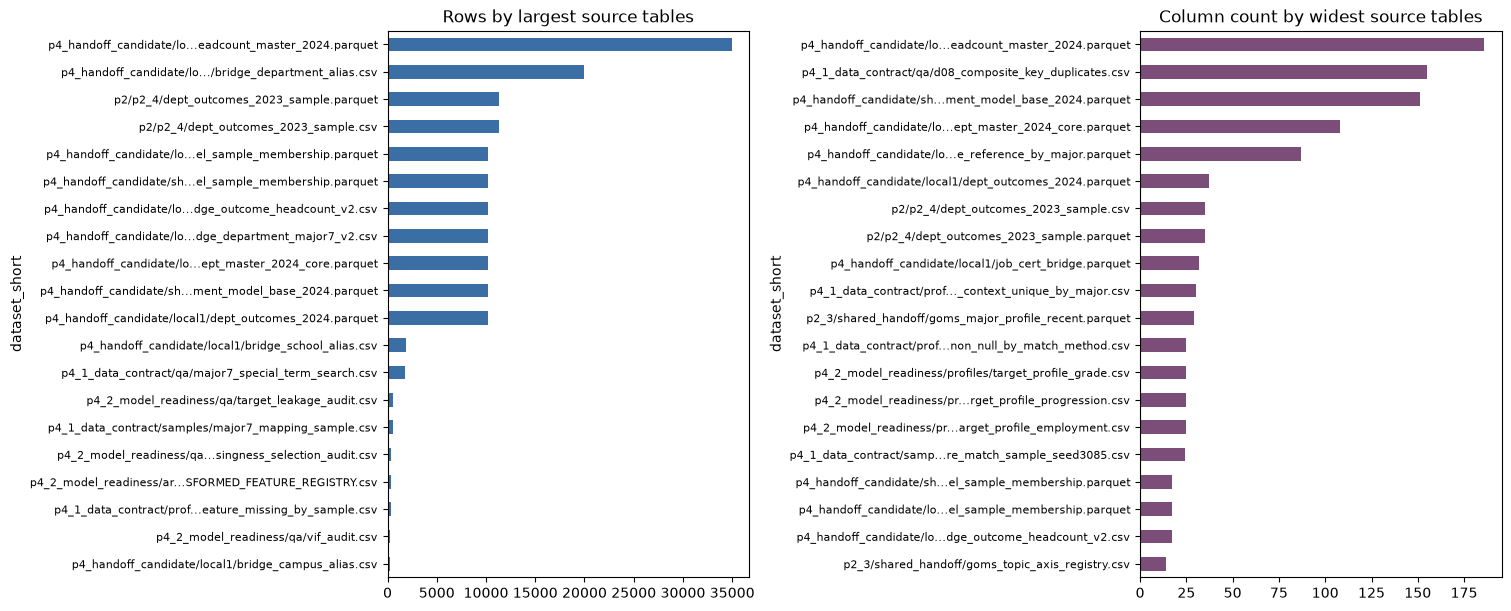

In [6]:
plot_inventory = inventory.dropna(subset=["rows", "columns"]).copy()

def short_dataset_label(row) -> str:
    source = row.get("source_parquet")
    path_text = source if isinstance(source, str) and source != "nan" else row["path"]
    parts = Path(str(path_text)).parts
    label = "/".join(parts[-3:]) if len(parts) >= 3 else str(path_text)
    if len(label) > 54:
        label = label[:23] + "..." + label[-28:]
    return label

plot_inventory["dataset_short"] = plot_inventory.apply(short_dataset_label, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
plot_inventory.sort_values("rows", ascending=False).head(20).plot.barh(
    x="dataset_short", y="rows", ax=axes[0], legend=False, color="#3a6ea5"
)
axes[0].set_title("Rows by largest source tables")
axes[0].tick_params(axis="y", labelsize=8)
axes[0].invert_yaxis()
plot_inventory.sort_values("columns", ascending=False).head(20).plot.barh(
    x="dataset_short", y="columns", ax=axes[1], legend=False, color="#7c4d79"
)
axes[1].set_title("Column count by widest source tables")
axes[1].tick_params(axis="y", labelsize=8)
axes[1].invert_yaxis()
fig.savefig(FIGURE_DIR / "source_table_size_overview.png", dpi=150)
display(Markdown(f"Saved: `{rel(FIGURE_DIR / 'source_table_size_overview.png')}`"))
plt.show()

In [7]:
registry_paths = [
    P2_3 / "p4_handoff_candidate" / "shared" / "department_model_column_registry.csv",
    P2_3 / "p4_handoff_candidate" / "shared" / "p4_feature_set_registry.csv",
    P2_3 / "p4_handoff_candidate" / "shared" / "p4_target_candidate_registry.csv",
    P2_3 / "p4_handoff_candidate" / "shared" / "model_sample_registry.csv",
]
for registry_path in registry_paths:
    if registry_path.exists():
        display(Markdown(f"## Registry: `{rel(registry_path)}`"))
        reg = read_csv_smart(registry_path)
        display(dataset_profile(reg, registry_path, "P4 active registry"))
        display(reg)

## Registry: `workbook/p2/p2_3/p4_handoff_candidate/shared/department_model_column_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/shared/department_model_column_registry.csv,P4 active registry,198,6,14689,5871ec9ae36dd0e078eed403c67322784e3880d2fa82849671be45a6d252e126,0,0,1,1,4


,dataset,column,dtype,p4_use,registry_reason,missing_n
0,D08_v2,analysis_year,Int16,True,candidate_feature_or_context,0
1,D08_v2,outcome_row_id,str,False,identifier_label_or_qa_metadata,0
2,D08_v2,school_name_raw,string,False,identifier_label_or_qa_metadata,0
3,D08_v2,school_name_base_raw,string,False,identifier_label_or_qa_metadata,0
4,D08_v2,school_name_std,string,False,identifier_label_or_qa_metadata,0
...,...,...,...,...,...,...
193,D05,is_total_row,boolean,False,job_cert_bridge_direct_join_prohibited,0
194,D05,is_model_row,bool,False,job_cert_bridge_direct_join_prohibited,0
195,D05,decision_reason,str,False,job_cert_bridge_direct_join_prohibited,0
196,D05,source_file,str,False,job_cert_bridge_direct_join_prohibited,0


## Registry: `workbook/p2/p2_3/p4_handoff_candidate/shared/p4_feature_set_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/shared/p4_feature_set_registry.csv,P4 active registry,4,7,588,776c7072444b5abee02f9a20942ca24cff5ec5c684593299a2c8c43dbf7a6529,0,3,2,1,4


...

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/shared/p4_target_candidate_registry.csv,P4 active registry,6,4,715,3e48aaea329c4df989af2e078635fd7d7cd1677d5afd6c99d5f106e6313b5247,0,0,1,0,3


,target_candidate,non_null_n,role,p3_policy
0,a_rate_pct,10242,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
1,cd_rate_pct,10242,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
2,f_rate_pct,10242,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
3,selectivity_proxy_pct,3737,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
4,health_employment_rate_pct,7477,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
5,graduate_school_progression_rate_pct,7587,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample


## Registry: `workbook/p2/p2_3/p4_handoff_candidate/shared/model_sample_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/shared/model_sample_registry.csv,P4 active registry,5,12,1641,b3389c0051d9b9eeca555f43cd8194d99574c2444df68cd8273232f7f9a553f8,0,0,6,2,4


,sample_id,base_rule,sample_level_exclusion_rule,requires_major_group_7,requires_structure_context,usable_rows_n,usable_rows_with_structure_n,usable_schools_n,train_n,val_n,test_n,p3_policy
0,GRADE_ALL,a_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,False,10099,8561,200,7417,1504,1178,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
1,GRADE_SELECTIVITY,a_rate_pct.notna() & selectivity_proxy_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,False,3707,3198,151,2760,585,362,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
2,EMPLOYMENT_HEALTH,health_employment_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,True,7389,6270,188,5428,1121,840,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
3,PROGRESSION_GRADSCHOOL,graduate_school_progression_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,True,7498,6366,197,5499,1141,858,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
4,JOINT_EMP_PROG,health_employment_rate_pct.notna() & graduate_school_progression_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,True,7389,6270,188,5428,1121,840,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"


## Dataset 001: `workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_campus_alias.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [8]:
df_001 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_campus_alias.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_campus_alias.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_campus_alias.csv,native_csv,229,10,35943,8033c6f596aec13af52dd3cb255ba4414b6a03299cd0a9cb7c6e8c91a3f7a0fa,0,43,0,0,10


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0000,2,D01 | D01 | D01
1,raw_value,str,4,0.0175,13,본교(제1캠퍼스) | 본교(제2캠퍼스) | 본교(제1캠퍼스)
2,standard_value,str,0,0.0000,10,본교_제1캠퍼스 | 본교_제2캠퍼스 | 본교_제1캠퍼스
3,campus_seq,str,8,0.0349,4,제1캠퍼스 | 제2캠퍼스 | 제1캠퍼스
4,campus_branch,str,7,0.0306,2,본교 | 본교 | 본교
5,sido,str,12,0.0524,17,강원 | 강원 | 강원
6,sigungu,str,12,0.0524,163,강원 강릉시 | 강원 원주시 | 강원 춘천시
7,basis,str,0,0.0000,2,본분교 code plus 제N캠퍼스/분교 token | 본분교 code plus 제N캠퍼스/분교 token | 본분교 code plus 제N캠퍼스/분교 token
8,confidence,str,0,0.0000,2,high | high | high
9,approval_status,str,0,0.0000,1,rule_approved | rule_approved | rule_approved


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,2,D01:217 | D02:12
1,raw_value,13,본교(제1캠퍼스):153 | 본교(제2캠퍼스):48 | 본교(제3캠퍼스):10 | 분교(제1캠퍼스):5 | <NA>:4
2,standard_value,10,본교_제1캠퍼스:153 | 본교_제2캠퍼스:48 | 본교_제3캠퍼스:10 | 분교_제1캠퍼스:5 | 분교:5
3,campus_seq,4,제1캠퍼스:158 | 제2캠퍼스:50 | 제3캠퍼스:11 | <NA>:8 | 제4캠퍼스:2
4,campus_branch,2,본교:212 | 분교:10 | <NA>:7
5,sido,17,경기:44 | 서울:32 | 충남:17 | 경북:13 | 경남:13
6,sigungu,163,<NA>:12 | 강원 원주시:4 | 경남 양산시:3 | 서울 종로구:3 | 경기 양주시:3
7,basis,2,본분교 code plus 제N캠퍼스/분교 token:217 | outcome school suffix/parenthetical parsed; region is evidence only unless unique:12
8,confidence,2,high:217 | medium:12
9,approval_status,1,rule_approved:229


**미리보기 5행**

,dataset,raw_value,standard_value,campus_seq,campus_branch,sido,sigungu,basis,confidence,approval_status
0,D01,본교(제1캠퍼스),본교_제1캠퍼스,제1캠퍼스,본교,강원,강원 강릉시,본분교 code plus 제N캠퍼스/분교 token,high,rule_approved
1,D01,본교(제2캠퍼스),본교_제2캠퍼스,제2캠퍼스,본교,강원,강원 원주시,본분교 code plus 제N캠퍼스/분교 token,high,rule_approved
2,D01,본교(제1캠퍼스),본교_제1캠퍼스,제1캠퍼스,본교,강원,강원 춘천시,본분교 code plus 제N캠퍼스/분교 token,high,rule_approved
3,D01,본교(제2캠퍼스),본교_제2캠퍼스,제2캠퍼스,본교,강원,강원 삼척시,본분교 code plus 제N캠퍼스/분교 token,high,rule_approved
4,D01,본교(제1캠퍼스),본교_제1캠퍼스,제1캠퍼스,본교,대구,대구 북구,본분교 code plus 제N캠퍼스/분교 token,high,rule_approved


## Dataset 002: `workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [9]:
df_002 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_alias.csv,native_csv,19990,10,4097995,2d380712d1220dab414976a8b0cc67708285dafe6f413e030e61fa953a1c936c,0,13580,0,0,10


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0000,2,D01 | D01 | D01
1,raw_value,str,0,0.0000,15739,국어국문학과 | 중어중문학과 | 영어영문학과
2,dept_norm_strict,str,0,0.0000,15191,국어국문학과 | 중어중문학과 | 영어영문학과
3,dept_norm_suffix_reduced,str,0,0.0000,13013,국어국문 | 중어중문 | 영어영문
4,dept_token_signature,str,0,0.0000,13013,국어국문 | 중어중문 | 영어영문
5,dept_core_tokens,str,0,0.0000,13013,국어국문 | 중어중문 | 영어영문
6,dept_modifier_tokens,str,13580,0.6793,52,영문 | 학부 | 학부
7,basis,str,0,0.0000,1,comparison keys only; raw department label is preserved | comparison keys only; raw department label is preserved | comparison keys only; raw department lab...
8,confidence,str,0,0.0000,1,medium | medium | medium
9,approval_status,str,0,0.0000,1,rule_approved | rule_approved | rule_approved


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,2,D01:15044 | D02:4946
1,raw_value,15739,국어국문학과:2 | 중어중문학과:2 | 영어영문학과:2 | 독어독문학과:2 | 사학과:2
2,dept_norm_strict,15191,에너지자원공학과:5 | 전자정보통신공학과:5 | 건축학부건축공학전공:5 | 건축학부건축학전공:5 | 만화애니메이션학과:5
3,dept_norm_suffix_reduced,13013,만화애니메이션:13 | 경찰행정:11 | 외식조리:11 | 무용:10 | 시각영상디자인:10
4,dept_token_signature,13013,만화애니메이션:13 | 경찰행정:11 | 외식조리:11 | 무용:10 | 시각영상디자인:10
5,dept_core_tokens,13013,만화애니메이션:13 | 경찰행정:11 | 외식조리:11 | 무용:10 | 시각영상디자인:10
6,dept_modifier_tokens,52,<NA>:13580 | 학부:3340 | 교육:817 | 디자인:688 | 보건:233
7,basis,1,comparison keys only; raw department label is preserved:19990
8,confidence,1,medium:19990
9,approval_status,1,rule_approved:19990


**미리보기 5행**

,dataset,raw_value,dept_norm_strict,dept_norm_suffix_reduced,dept_token_signature,dept_core_tokens,dept_modifier_tokens,basis,confidence,approval_status
0,D01,국어국문학과,국어국문학과,국어국문,국어국문,국어국문,NaN,comparison keys only; raw department label is preserved,medium,rule_approved
1,D01,중어중문학과,중어중문학과,중어중문,중어중문,중어중문,NaN,comparison keys only; raw department label is preserved,medium,rule_approved
2,D01,영어영문학과,영어영문학과,영어영문,영어영문,영어영문,영문,comparison keys only; raw department label is preserved,medium,rule_approved
3,D01,독어독문학과,독어독문학과,독어독문,독어독문,독어독문,NaN,comparison keys only; raw department label is preserved,medium,rule_approved
4,D01,사학과,사학과,사학,사학,사학,NaN,comparison keys only; raw department label is preserved,medium,rule_approved


## Dataset 003: `workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_major7_v2.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [10]:
df_003 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_major7_v2.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_major7_v2.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_department_major7_v2.csv,native_csv,10242,8,1047119,7a92574bd2d8928304cffb08ecbafa4a3ce2c3112a3afe19ae2852e16138fbab,0,10242,1,1,6


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,outcome_row_id,str,0,0.000,10242,OC2024_00001 | OC2024_00002 | OC2024_00003
1,major_group_7,str,143,0.014,7,MED | SOC | SOC
2,major7_mapping_method,str,0,0.000,5,inherited_headcount | inherited_headcount | inherited_headcount
3,major7_mapping_confidence,str,0,0.000,4,high | high | high
4,major7_candidate_count,int64,0,0.000,5,1 | 1 | 1
5,major7_review_needed,bool,0,0.000,2,False | False | False
6,major7_evidence,str,0,0.000,596,D01 v2 high-confidence match 대계열=의약계열 | D01 v2 high-confidence match 대계열=사회계열 | D01 v2 high-confidence match 대계열=사회계열
7,major7_sample_exclusion_rule,str,10099,0.986,1,exclude from samples requiring major/context/GOMS until manual approved | exclude from samples requiring major/context/GOMS until manual approved | exclude ...


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,major7_candidate_count,10242.0,1.001172,0.119395,0.0,1.0,1.0,1.0,4.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,10242,OC2024_00001:1 | OC2024_00002:1 | OC2024_00003:1 | OC2024_00004:1 | OC2024_00005:1
1,major_group_7,7,ENG:2642 | SOC:2165 | ART:1566 | NAT:1258 | HUM:1108
2,major7_mapping_method,5,inherited_headcount:8561 | keyword_rule:859 | exact_dictionary:679 | ambiguous:85 | unknown:58
3,major7_mapping_confidence,4,high:8561 | medium:1538 | low:85 | unknown:58
4,major7_review_needed,2,False:10099 | True:143
5,major7_evidence,596,D01 v2 high-confidence match 대계열=공학계열:2212 | D01 v2 high-confidence match 대계열=사회계열:1776 | D01 v2 high-confidence match 대계열=예체능계열:1259 | D01 v2 high-confiden...
6,major7_sample_exclusion_rule,1,<NA>:10099 | exclude from samples requiring major/context/GOMS until manual approved:143


**미리보기 5행**

,outcome_row_id,major_group_7,major7_mapping_method,major7_mapping_confidence,major7_candidate_count,major7_review_needed,major7_evidence,major7_sample_exclusion_rule
0,OC2024_00001,MED,inherited_headcount,high,1,False,D01 v2 high-confidence match 대계열=의약계열,NaN
1,OC2024_00002,SOC,inherited_headcount,high,1,False,D01 v2 high-confidence match 대계열=사회계열,NaN
2,OC2024_00003,SOC,inherited_headcount,high,1,False,D01 v2 high-confidence match 대계열=사회계열,NaN
3,OC2024_00004,ART,inherited_headcount,high,1,False,D01 v2 high-confidence match 대계열=예체능계열,NaN
4,OC2024_00005,MED,inherited_headcount,high,1,False,D01 v2 high-confidence match 대계열=의약계열,NaN


## Dataset 004: `workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_outcome_headcount_v2.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [11]:
df_004 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_outcome_headcount_v2.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_outcome_headcount_v2.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_outcome_headcount_v2.csv,native_csv,10242,17,2046842,0ee76ab52f2f78e841ef341d740e9098cfafb1d7c1d277f577657d1b3d454bea,0,10959,2,6,9


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,outcome_row_id,str,0,0.0000,10242,OC2024_00001 | OC2024_00002 | OC2024_00003
1,headcount_row_id,str,1681,0.1641,8547,HC2_2024_07159 | HC2_2024_07147 | HC2_2024_07154
2,match_stage,str,0,0.0000,4,L1 | L1 | L1
3,match_method,str,0,0.0000,4,exact_strict | exact_strict | exact_strict
4,match_status,str,0,0.0000,3,auto_high_confidence | auto_high_confidence | auto_high_confidence
5,match_score,float64,365,0.0356,1,1.0 | 1.0 | 1.0
6,candidate_count,int64,0,0.0000,42,1 | 1 | 1
7,review_needed,bool,0,0.0000,2,False | False | False
8,unmatched_reason,str,8561,0.8359,5,multiple_candidates | multiple_fuzzy_or_conflict | multiple_candidates
9,match_evidence,str,0,0.0000,8,school+campus+department strict exact unique | school+campus+department strict exact unique | school+campus+department strict exact unique


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,match_score,9877.0,1.000000,0.00000,1.0,1.0,1.0,1.0,1.0
1,candidate_count,10242.0,2.850225,13.77181,0.0,1.0,1.0,1.0,180.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,10242,OC2024_00001:1 | OC2024_00002:1 | OC2024_00003:1 | OC2024_00004:1 | OC2024_00005:1
1,headcount_row_id,8547,<NA>:1681 | HC2_2024_10023:2 | HC2_2024_10024:2 | HC2_2024_10005:2 | HC2_2024_10027:2
2,match_stage,4,L1:8556 | L7:1316 | L8:365 | L3:5
3,match_method,4,exact_strict:8556 | manual_pending:1316 | unmatched:365 | exact_token_unique:5
4,match_status,3,auto_high_confidence:8561 | manual_pending:1316 | unmatched:365
5,review_needed,2,False:8561 | True:1681
6,unmatched_reason,5,<NA>:8561 | multiple_fuzzy_or_conflict:672 | multiple_candidates:644 | department_formatting_or_source_coverage_mismatch:189 | no_candidate:152
7,match_evidence,8,school+campus+department strict exact unique:8556 | fuzzy candidates need manual review:672 | school+campus+department strict exact unique; multiple D01 row...
8,candidate_headcount_row_ids,9898,<NA>:176 | HC2_2024_18650|HC2_2024_18651|HC2_2024_18652|HC2_2024_18653|HC2_2024_18654|HC2_2024_18655|HC2_2024_18656|HC2_2024_18657|HC2_2024_18658|HC2_2024_1...
9,candidate_preview,4906,<NA>:176 | 간호학과:104 | 사회복지학과:88 | 식품영양학과:69 | 경영학과:68


**미리보기 5행**

,outcome_row_id,headcount_row_id,match_stage,match_method,match_status,match_score,candidate_count,review_needed,unmatched_reason,match_evidence,candidate_headcount_row_ids,candidate_preview,campus_conflict_flag,degree_course_conflict_flag,major_conflict_flag,forbidden_modifier_conflict_flag,headcount_match_flag
0,OC2024_00001,HC2_2024_07159,L1,exact_strict,auto_high_confidence,1.0,1,False,NaN,school+campus+department strict exact unique,HC2_2024_07159,간호학과,False,False,False,False,True
1,OC2024_00002,HC2_2024_07147,L1,exact_strict,auto_high_confidence,1.0,1,False,NaN,school+campus+department strict exact unique,HC2_2024_07147,경영물류학과,False,False,False,False,True
2,OC2024_00003,HC2_2024_07154,L1,exact_strict,auto_high_confidence,1.0,1,False,NaN,school+campus+department strict exact unique,HC2_2024_07154,경찰소방학과,False,False,False,False,True
3,OC2024_00004,HC2_2024_07165,L1,exact_strict,auto_high_confidence,1.0,1,False,NaN,school+campus+department strict exact unique,HC2_2024_07165,귀금속주얼리학과,False,False,False,False,True
4,OC2024_00005,HC2_2024_07161,L1,exact_strict,auto_high_confidence,1.0,1,False,NaN,school+campus+department strict exact unique,HC2_2024_07161,물리치료학과,False,False,False,False,True


## Dataset 005: `workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_school_alias.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [12]:
df_005 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_school_alias.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_school_alias.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/bridge_school_alias.csv,native_csv,1919,6,337935,c4ea27cd4a71a4b93189578c0f6f28463bfd1981fb9a5abb5f9f2b8768499dc3,0,0,0,0,6


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,2,D01 | D01 | D01
1,raw_value,str,0,0.0,1725,국립강릉원주대학교 | 국립강릉원주대학교대학원 | 국립강릉원주대학교경영정책과학대학원
2,standard_value,str,0,0.0,1678,강릉원주대학교 | 강릉원주대학교대학원 | 강릉원주대학교경영정책과학대학원
3,basis,str,0,0.0,1,"NFKC, whitespace/punctuation fold, remove parenthetical campus, remove national prefix | NFKC, whitespace/punctuation fold, remove parenthetical campus, rem..."
4,confidence,str,0,0.0,1,high | high | high
5,approval_status,str,0,0.0,1,rule_approved | rule_approved | rule_approved


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,2,D01:1692 | D02:227
1,raw_value,1725,강원대학교:2 | 경북대학교:2 | 경상국립대학교:2 | 국립공주대학교:2 | 국립군산대학교:2
2,standard_value,1678,가톨릭대학교:4 | 경동대학교:4 | 을지대학교:4 | 강릉원주대학교:3 | 강원대학교:3
3,basis,1,"NFKC, whitespace/punctuation fold, remove parenthetical campus, remove national prefix:1919"
4,confidence,1,high:1919
5,approval_status,1,rule_approved:1919


**미리보기 5행**

,dataset,raw_value,standard_value,basis,confidence,approval_status
0,D01,국립강릉원주대학교,강릉원주대학교,"NFKC, whitespace/punctuation fold, remove parenthetical campus, remove national prefix",high,rule_approved
1,D01,국립강릉원주대학교대학원,강릉원주대학교대학원,"NFKC, whitespace/punctuation fold, remove parenthetical campus, remove national prefix",high,rule_approved
2,D01,국립강릉원주대학교경영정책과학대학원,강릉원주대학교경영정책과학대학원,"NFKC, whitespace/punctuation fold, remove parenthetical campus, remove national prefix",high,rule_approved
3,D01,국립강릉원주대학교교육대학원,강릉원주대학교교육대학원,"NFKC, whitespace/punctuation fold, remove parenthetical campus, remove national prefix",high,rule_approved
4,D01,국립강릉원주대학교산업대학원,강릉원주대학교산업대학원,"NFKC, whitespace/punctuation fold, remove parenthetical campus, remove national prefix",high,rule_approved


## Dataset 006: `workbook/p2/p2_3/p4_handoff_candidate/local1/department_model_column_registry.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [13]:
df_006 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/department_model_column_registry.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/department_model_column_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/department_model_column_registry.csv,native_csv,198,6,14689,5871ec9ae36dd0e078eed403c67322784e3880d2fa82849671be45a6d252e126,0,0,1,1,4


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,3,D08_v2 | D08_v2 | D08_v2
1,column,str,0,0.0,180,analysis_year | outcome_row_id | school_name_raw
2,dtype,str,0,0.0,11,Int16 | str | string
3,p4_use,bool,0,0.0,2,True | False | False
4,registry_reason,str,0,0.0,6,candidate_feature_or_context | identifier_label_or_qa_metadata | identifier_label_or_qa_metadata
5,missing_n,int64,0,0.0,13,0 | 0 | 0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,missing_n,198.0,715.979798,1463.928062,0.0,0.0,7.0,1681.0,10242.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,3,D08_v2:151 | D05:32 | D04:15
1,column,180,source_file:2 | source_sha256:2 | review_needed:2 | ctx24_reference_sample_n:2 | ctx24_mean_income_10kkrw:2
2,dtype,11,Float32:72 | string:35 | str:30 | boolean:13 | Int32:13
3,p4_use,2,True:133 | False:65
4,registry_reason,6,candidate_feature_or_context:120 | job_cert_bridge_direct_join_prohibited:32 | identifier_label_or_qa_metadata:23 | ctx24_wage_reference_context:13 | target...


**미리보기 5행**

,dataset,column,dtype,p4_use,registry_reason,missing_n
0,D08_v2,analysis_year,Int16,True,candidate_feature_or_context,0
1,D08_v2,outcome_row_id,str,False,identifier_label_or_qa_metadata,0
2,D08_v2,school_name_raw,string,False,identifier_label_or_qa_metadata,0
3,D08_v2,school_name_base_raw,string,False,identifier_label_or_qa_metadata,0
4,D08_v2,school_name_std,string,False,identifier_label_or_qa_metadata,0


## Dataset 007: `workbook/p2/p2_3/p4_handoff_candidate/local1/dim_headcount_grain_definition.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [14]:
df_007 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/dim_headcount_grain_definition.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/dim_headcount_grain_definition.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/dim_headcount_grain_definition.csv,native_csv,6,3,496,76857c3cebefbbcc9b3df77ea067c44f7cee0a4fe7517acf7fc946c5c3681a7e,0,0,0,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,grain_version,str,0,0.0,1,v2_year_school_campus_day_degree_deptcode | v2_year_school_campus_day_degree_deptcode | v2_year_school_campus_day_degree_deptcode
1,key_column,str,0,0.0,6,analysis_year | school_name_std | campus_name_std
2,role,str,0,0.0,1,semantic grain axis | semantic grain axis | semantic grain axis


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,grain_version,1,v2_year_school_campus_day_degree_deptcode:6
1,key_column,6,analysis_year:1 | school_name_std:1 | campus_name_std:1 | day_evening_raw:1 | degree_course:1
2,role,1,semantic grain axis:6


**미리보기 5행**

,grain_version,key_column,role
0,v2_year_school_campus_day_degree_deptcode,analysis_year,semantic grain axis
1,v2_year_school_campus_day_degree_deptcode,school_name_std,semantic grain axis
2,v2_year_school_campus_day_degree_deptcode,campus_name_std,semantic grain axis
3,v2_year_school_campus_day_degree_deptcode,day_evening_raw,semantic grain axis
4,v2_year_school_campus_day_degree_deptcode,degree_course,semantic grain axis


## Dataset 008: `workbook/p2/p2_3/p4_handoff_candidate/local1/dim_school_split.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [15]:
df_008 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/dim_school_split.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/dim_school_split.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/dim_school_split.csv,native_csv,200,6,10962,85c2c851ddcfd02d5ead41dbd9424124e4ef1993347842c031e487e8f2a13583,0,0,3,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,school_uid,str,0,0.0,200,SCH_080166833214 | SCH_08825e789819 | SCH_0a0f2352484e
1,school_name_std,str,0,0.0,200,칼빈대학교 | 울산과학기술원 | 조선대학교
2,split,str,0,0.0,3,train | train | train
3,department_rows,int64,0,0.0,94,10 | 24 | 89
4,seed_primary,int64,0,0.0,1,3085 | 3085 | 3085
5,seed_secondary,int64,0,0.0,1,3086 | 3086 | 3086


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,department_rows,200.0,51.21,40.731082,1.0,14.0,41.0,78.0,217.0
1,seed_primary,200.0,3085.00,0.000000,3085.0,3085.0,3085.0,3085.0,3085.0
2,seed_secondary,200.0,3086.00,0.000000,3086.0,3086.0,3086.0,3086.0,3086.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,school_uid,200,SCH_080166833214:1 | SCH_08825e789819:1 | SCH_0a0f2352484e:1 | SCH_0a6c34a4bd7e:1 | SCH_0a99c689284a:1
1,school_name_std,200,칼빈대학교:1 | 울산과학기술원:1 | 조선대학교:1 | 예원예술대학교:1 | 호남신학대학교:1
2,split,3,train:140 | test:30 | val:30


**미리보기 5행**

,school_uid,school_name_std,split,department_rows,seed_primary,seed_secondary
0,SCH_080166833214,칼빈대학교,train,10,3085,3086
1,SCH_08825e789819,울산과학기술원,train,24,3085,3086
2,SCH_0a0f2352484e,조선대학교,train,89,3085,3086
3,SCH_0a6c34a4bd7e,예원예술대학교,train,19,3085,3086
4,SCH_0a99c689284a,호남신학대학교,train,5,3085,3086


## Dataset 009: `workbook/p2/p2_3/p4_handoff_candidate/local1/model_sample_registry.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [16]:
df_009 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/model_sample_registry.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/model_sample_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/model_sample_registry.csv,native_csv,5,12,1641,b3389c0051d9b9eeca555f43cd8194d99574c2444df68cd8273232f7f9a553f8,0,0,6,2,4


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,sample_id,str,0,0.0,5,GRADE_ALL | GRADE_SELECTIVITY | EMPLOYMENT_HEALTH
1,base_rule,str,0,0.0,5,a_rate_pct.notna() | a_rate_pct.notna() & selectivity_proxy_pct.notna() | health_employment_rate_pct.notna()
2,sample_level_exclusion_rule,str,0,0.0,1,exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample | exclude major7 ambiguous/unknown from major/con...
3,requires_major_group_7,bool,0,0.0,1,True | True | True
4,requires_structure_context,bool,0,0.0,2,False | False | True
5,usable_rows_n,int64,0,0.0,4,10099 | 3707 | 7389
6,usable_rows_with_structure_n,int64,0,0.0,4,8561 | 3198 | 6270
7,usable_schools_n,int64,0,0.0,4,200 | 151 | 188
8,train_n,int64,0,0.0,4,7417 | 2760 | 5428
9,val_n,int64,0,0.0,4,1504 | 585 | 1121


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,usable_rows_n,5.0,7216.4,2278.384910,3707.0,7389.0,7389.0,7498.0,10099.0
1,usable_rows_with_structure_n,5.0,6133.0,1910.578185,3198.0,6270.0,6270.0,6366.0,8561.0
2,usable_schools_n,5.0,184.8,19.639246,151.0,188.0,188.0,197.0,200.0
3,train_n,5.0,5306.4,1658.723395,2760.0,5428.0,5428.0,5499.0,7417.0
4,val_n,5.0,1094.4,328.194759,585.0,1121.0,1121.0,1141.0,1504.0
5,test_n,5.0,815.6,291.579835,362.0,840.0,840.0,858.0,1178.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,sample_id,5,GRADE_ALL:1 | GRADE_SELECTIVITY:1 | EMPLOYMENT_HEALTH:1 | PROGRESSION_GRADSCHOOL:1 | JOINT_EMP_PROG:1
1,base_rule,5,a_rate_pct.notna():1 | a_rate_pct.notna() & selectivity_proxy_pct.notna():1 | health_employment_rate_pct.notna():1 | graduate_school_progression_rate_pct.no...
2,sample_level_exclusion_rule,1,exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample:5
3,requires_major_group_7,1,True:5
4,requires_structure_context,2,True:3 | False:2
5,p3_policy,1,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training:5"


**미리보기 5행**

,sample_id,base_rule,sample_level_exclusion_rule,requires_major_group_7,requires_structure_context,usable_rows_n,usable_rows_with_structure_n,usable_schools_n,train_n,val_n,test_n,p3_policy
0,GRADE_ALL,a_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,False,10099,8561,200,7417,1504,1178,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
1,GRADE_SELECTIVITY,a_rate_pct.notna() & selectivity_proxy_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,False,3707,3198,151,2760,585,362,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
2,EMPLOYMENT_HEALTH,health_employment_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,True,7389,6270,188,5428,1121,840,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
3,PROGRESSION_GRADSCHOOL,graduate_school_progression_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,True,7498,6366,197,5499,1141,858,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
4,JOINT_EMP_PROG,health_employment_rate_pct.notna() & graduate_school_progression_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,True,7389,6270,188,5428,1121,840,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"


## Dataset 010: `workbook/p2/p2_3/p4_handoff_candidate/local1/p4_feature_set_registry.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [17]:
df_010 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/p4_feature_set_registry.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/p4_feature_set_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/p4_feature_set_registry.csv,native_csv,4,7,588,776c7072444b5abee02f9a20942ca24cff5ec5c684593299a2c8c43dbf7a6529,0,3,2,1,4


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,feature_set_id,str,0,0.00,4,STRUCTURE | CTX24_WAGE | CTX24_WAGE_DISABLED_ALL_NULL
1,context_block,str,0,0.00,3,structure | ctx24_wage | ctx24_wage
2,feature_count,int64,0,0.00,4,31 | 13 | 2
3,all_null_count,int64,0,0.00,2,0 | 0 | 2
4,all_null_columns,str,3,0.75,1,ctx24_industry_top3_pct|ctx24_industry_hhi
5,p4_use,bool,0,0.00,2,True | True | False
6,exclusion_rule,str,0,0.00,2,use only rows where required context is observed; no all-null source columns | use only rows where required context is observed; no all-null source columns ...


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,feature_count,4.0,18.5,13.527749,2.0,10.25,20.5,28.75,31.0
1,all_null_count,4.0,0.5,1.000000,0.0,0.00,0.0,0.50,2.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,feature_set_id,4,STRUCTURE:1 | CTX24_WAGE:1 | CTX24_WAGE_DISABLED_ALL_NULL:1 | GOMS_RECENT:1
1,context_block,3,ctx24_wage:2 | structure:1 | goms_recent:1
2,all_null_columns,1,<NA>:3 | ctx24_industry_top3_pct|ctx24_industry_hhi:1
3,p4_use,2,True:3 | False:1
4,exclusion_rule,2,use only rows where required context is observed; no all-null source columns:3 | disabled because source D04 has no industry distribution columns:1


**미리보기 5행**

,feature_set_id,context_block,feature_count,all_null_count,all_null_columns,p4_use,exclusion_rule
0,STRUCTURE,structure,31,0,NaN,True,use only rows where required context is observed; no all-null source columns
1,CTX24_WAGE,ctx24_wage,13,0,NaN,True,use only rows where required context is observed; no all-null source columns
2,CTX24_WAGE_DISABLED_ALL_NULL,ctx24_wage,2,2,ctx24_industry_top3_pct|ctx24_industry_hhi,False,disabled because source D04 has no industry distribution columns
3,GOMS_RECENT,goms_recent,28,0,NaN,True,use only rows where required context is observed; no all-null source columns


## Dataset 011: `workbook/p2/p2_3/p4_handoff_candidate/local1/p4_target_candidate_registry.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [18]:
df_011 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/local1/p4_target_candidate_registry.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/local1/p4_target_candidate_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/local1/p4_target_candidate_registry.csv,native_csv,6,4,715,3e48aaea329c4df989af2e078635fd7d7cd1677d5afd6c99d5f106e6313b5247,0,0,1,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,target_candidate,str,0,0.0,6,a_rate_pct | cd_rate_pct | f_rate_pct
1,non_null_n,int64,0,0.0,4,10242 | 10242 | 10242
2,role,str,0,0.0,1,candidate_target_or_exposure | candidate_target_or_exposure | candidate_target_or_exposure
3,p3_policy,str,0,0.0,1,candidate only; P4 chooses target within declared sample | candidate only; P4 chooses target within declared sample | candidate only; P4 chooses target with...


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,non_null_n,6.0,8254.5,2581.020631,3737.0,7504.5,8914.5,10242.0,10242.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,target_candidate,6,a_rate_pct:1 | cd_rate_pct:1 | f_rate_pct:1 | selectivity_proxy_pct:1 | health_employment_rate_pct:1
1,role,1,candidate_target_or_exposure:6
2,p3_policy,1,candidate only; P4 chooses target within declared sample:6


**미리보기 5행**

,target_candidate,non_null_n,role,p3_policy
0,a_rate_pct,10242,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
1,cd_rate_pct,10242,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
2,f_rate_pct,10242,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
3,selectivity_proxy_pct,3737,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
4,health_employment_rate_pct,7477,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample


## Dataset 012: `workbook/p2/p2_3/p4_handoff_candidate/shared/department_model_column_registry.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [19]:
df_012 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/shared/department_model_column_registry.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/shared/department_model_column_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/shared/department_model_column_registry.csv,native_csv,198,6,14689,5871ec9ae36dd0e078eed403c67322784e3880d2fa82849671be45a6d252e126,0,0,1,1,4


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,3,D08_v2 | D08_v2 | D08_v2
1,column,str,0,0.0,180,analysis_year | outcome_row_id | school_name_raw
2,dtype,str,0,0.0,11,Int16 | str | string
3,p4_use,bool,0,0.0,2,True | False | False
4,registry_reason,str,0,0.0,6,candidate_feature_or_context | identifier_label_or_qa_metadata | identifier_label_or_qa_metadata
5,missing_n,int64,0,0.0,13,0 | 0 | 0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,missing_n,198.0,715.979798,1463.928062,0.0,0.0,7.0,1681.0,10242.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,3,D08_v2:151 | D05:32 | D04:15
1,column,180,source_file:2 | source_sha256:2 | review_needed:2 | ctx24_reference_sample_n:2 | ctx24_mean_income_10kkrw:2
2,dtype,11,Float32:72 | string:35 | str:30 | boolean:13 | Int32:13
3,p4_use,2,True:133 | False:65
4,registry_reason,6,candidate_feature_or_context:120 | job_cert_bridge_direct_join_prohibited:32 | identifier_label_or_qa_metadata:23 | ctx24_wage_reference_context:13 | target...


**미리보기 5행**

,dataset,column,dtype,p4_use,registry_reason,missing_n
0,D08_v2,analysis_year,Int16,True,candidate_feature_or_context,0
1,D08_v2,outcome_row_id,str,False,identifier_label_or_qa_metadata,0
2,D08_v2,school_name_raw,string,False,identifier_label_or_qa_metadata,0
3,D08_v2,school_name_base_raw,string,False,identifier_label_or_qa_metadata,0
4,D08_v2,school_name_std,string,False,identifier_label_or_qa_metadata,0


## Dataset 013: `workbook/p2/p2_3/p4_handoff_candidate/shared/dim_school_split.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [20]:
df_013 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/shared/dim_school_split.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/shared/dim_school_split.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/shared/dim_school_split.csv,native_csv,200,6,10962,85c2c851ddcfd02d5ead41dbd9424124e4ef1993347842c031e487e8f2a13583,0,0,3,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,school_uid,str,0,0.0,200,SCH_080166833214 | SCH_08825e789819 | SCH_0a0f2352484e
1,school_name_std,str,0,0.0,200,칼빈대학교 | 울산과학기술원 | 조선대학교
2,split,str,0,0.0,3,train | train | train
3,department_rows,int64,0,0.0,94,10 | 24 | 89
4,seed_primary,int64,0,0.0,1,3085 | 3085 | 3085
5,seed_secondary,int64,0,0.0,1,3086 | 3086 | 3086


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,department_rows,200.0,51.21,40.731082,1.0,14.0,41.0,78.0,217.0
1,seed_primary,200.0,3085.00,0.000000,3085.0,3085.0,3085.0,3085.0,3085.0
2,seed_secondary,200.0,3086.00,0.000000,3086.0,3086.0,3086.0,3086.0,3086.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,school_uid,200,SCH_080166833214:1 | SCH_08825e789819:1 | SCH_0a0f2352484e:1 | SCH_0a6c34a4bd7e:1 | SCH_0a99c689284a:1
1,school_name_std,200,칼빈대학교:1 | 울산과학기술원:1 | 조선대학교:1 | 예원예술대학교:1 | 호남신학대학교:1
2,split,3,train:140 | test:30 | val:30


**미리보기 5행**

,school_uid,school_name_std,split,department_rows,seed_primary,seed_secondary
0,SCH_080166833214,칼빈대학교,train,10,3085,3086
1,SCH_08825e789819,울산과학기술원,train,24,3085,3086
2,SCH_0a0f2352484e,조선대학교,train,89,3085,3086
3,SCH_0a6c34a4bd7e,예원예술대학교,train,19,3085,3086
4,SCH_0a99c689284a,호남신학대학교,train,5,3085,3086


## Dataset 014: `workbook/p2/p2_3/p4_handoff_candidate/shared/model_sample_registry.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [21]:
df_014 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/shared/model_sample_registry.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/shared/model_sample_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/shared/model_sample_registry.csv,native_csv,5,12,1641,b3389c0051d9b9eeca555f43cd8194d99574c2444df68cd8273232f7f9a553f8,0,0,6,2,4


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,sample_id,str,0,0.0,5,GRADE_ALL | GRADE_SELECTIVITY | EMPLOYMENT_HEALTH
1,base_rule,str,0,0.0,5,a_rate_pct.notna() | a_rate_pct.notna() & selectivity_proxy_pct.notna() | health_employment_rate_pct.notna()
2,sample_level_exclusion_rule,str,0,0.0,1,exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample | exclude major7 ambiguous/unknown from major/con...
3,requires_major_group_7,bool,0,0.0,1,True | True | True
4,requires_structure_context,bool,0,0.0,2,False | False | True
5,usable_rows_n,int64,0,0.0,4,10099 | 3707 | 7389
6,usable_rows_with_structure_n,int64,0,0.0,4,8561 | 3198 | 6270
7,usable_schools_n,int64,0,0.0,4,200 | 151 | 188
8,train_n,int64,0,0.0,4,7417 | 2760 | 5428
9,val_n,int64,0,0.0,4,1504 | 585 | 1121


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,usable_rows_n,5.0,7216.4,2278.384910,3707.0,7389.0,7389.0,7498.0,10099.0
1,usable_rows_with_structure_n,5.0,6133.0,1910.578185,3198.0,6270.0,6270.0,6366.0,8561.0
2,usable_schools_n,5.0,184.8,19.639246,151.0,188.0,188.0,197.0,200.0
3,train_n,5.0,5306.4,1658.723395,2760.0,5428.0,5428.0,5499.0,7417.0
4,val_n,5.0,1094.4,328.194759,585.0,1121.0,1121.0,1141.0,1504.0
5,test_n,5.0,815.6,291.579835,362.0,840.0,840.0,858.0,1178.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,sample_id,5,GRADE_ALL:1 | GRADE_SELECTIVITY:1 | EMPLOYMENT_HEALTH:1 | PROGRESSION_GRADSCHOOL:1 | JOINT_EMP_PROG:1
1,base_rule,5,a_rate_pct.notna():1 | a_rate_pct.notna() & selectivity_proxy_pct.notna():1 | health_employment_rate_pct.notna():1 | graduate_school_progression_rate_pct.no...
2,sample_level_exclusion_rule,1,exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample:5
3,requires_major_group_7,1,True:5
4,requires_structure_context,2,True:3 | False:2
5,p3_policy,1,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training:5"


**미리보기 5행**

,sample_id,base_rule,sample_level_exclusion_rule,requires_major_group_7,requires_structure_context,usable_rows_n,usable_rows_with_structure_n,usable_schools_n,train_n,val_n,test_n,p3_policy
0,GRADE_ALL,a_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,False,10099,8561,200,7417,1504,1178,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
1,GRADE_SELECTIVITY,a_rate_pct.notna() & selectivity_proxy_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,False,3707,3198,151,2760,585,362,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
2,EMPLOYMENT_HEALTH,health_employment_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,True,7389,6270,188,5428,1121,840,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
3,PROGRESSION_GRADSCHOOL,graduate_school_progression_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,True,7498,6366,197,5499,1141,858,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"
4,JOINT_EMP_PROG,health_employment_rate_pct.notna() & graduate_school_progression_rate_pct.notna(),exclude major7 ambiguous/unknown from major/context/GOMS samples; keep D03 spine rows outside model sample,True,True,7389,6270,188,5428,1121,840,"P3 freezes masks only; no imputation, scaling, one-hot, PCA, or model training"


## Dataset 015: `workbook/p2/p2_3/p4_handoff_candidate/shared/p4_feature_set_registry.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [22]:
df_015 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/shared/p4_feature_set_registry.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/shared/p4_feature_set_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/shared/p4_feature_set_registry.csv,native_csv,4,7,588,776c7072444b5abee02f9a20942ca24cff5ec5c684593299a2c8c43dbf7a6529,0,3,2,1,4


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,feature_set_id,str,0,0.00,4,STRUCTURE | CTX24_WAGE | CTX24_WAGE_DISABLED_ALL_NULL
1,context_block,str,0,0.00,3,structure | ctx24_wage | ctx24_wage
2,feature_count,int64,0,0.00,4,31 | 13 | 2
3,all_null_count,int64,0,0.00,2,0 | 0 | 2
4,all_null_columns,str,3,0.75,1,ctx24_industry_top3_pct|ctx24_industry_hhi
5,p4_use,bool,0,0.00,2,True | True | False
6,exclusion_rule,str,0,0.00,2,use only rows where required context is observed; no all-null source columns | use only rows where required context is observed; no all-null source columns ...


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,feature_count,4.0,18.5,13.527749,2.0,10.25,20.5,28.75,31.0
1,all_null_count,4.0,0.5,1.000000,0.0,0.00,0.0,0.50,2.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,feature_set_id,4,STRUCTURE:1 | CTX24_WAGE:1 | CTX24_WAGE_DISABLED_ALL_NULL:1 | GOMS_RECENT:1
1,context_block,3,ctx24_wage:2 | structure:1 | goms_recent:1
2,all_null_columns,1,<NA>:3 | ctx24_industry_top3_pct|ctx24_industry_hhi:1
3,p4_use,2,True:3 | False:1
4,exclusion_rule,2,use only rows where required context is observed; no all-null source columns:3 | disabled because source D04 has no industry distribution columns:1


**미리보기 5행**

,feature_set_id,context_block,feature_count,all_null_count,all_null_columns,p4_use,exclusion_rule
0,STRUCTURE,structure,31,0,NaN,True,use only rows where required context is observed; no all-null source columns
1,CTX24_WAGE,ctx24_wage,13,0,NaN,True,use only rows where required context is observed; no all-null source columns
2,CTX24_WAGE_DISABLED_ALL_NULL,ctx24_wage,2,2,ctx24_industry_top3_pct|ctx24_industry_hhi,False,disabled because source D04 has no industry distribution columns
3,GOMS_RECENT,goms_recent,28,0,NaN,True,use only rows where required context is observed; no all-null source columns


## Dataset 016: `workbook/p2/p2_3/p4_handoff_candidate/shared/p4_target_candidate_registry.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [23]:
df_016 = eda_one('workbook/p2/p2_3/p4_handoff_candidate/shared/p4_target_candidate_registry.csv', 'native_csv')

### `workbook/p2/p2_3/p4_handoff_candidate/shared/p4_target_candidate_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/p4_handoff_candidate/shared/p4_target_candidate_registry.csv,native_csv,6,4,715,3e48aaea329c4df989af2e078635fd7d7cd1677d5afd6c99d5f106e6313b5247,0,0,1,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,target_candidate,str,0,0.0,6,a_rate_pct | cd_rate_pct | f_rate_pct
1,non_null_n,int64,0,0.0,4,10242 | 10242 | 10242
2,role,str,0,0.0,1,candidate_target_or_exposure | candidate_target_or_exposure | candidate_target_or_exposure
3,p3_policy,str,0,0.0,1,candidate only; P4 chooses target within declared sample | candidate only; P4 chooses target within declared sample | candidate only; P4 chooses target with...


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,non_null_n,6.0,8254.5,2581.020631,3737.0,7504.5,8914.5,10242.0,10242.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,target_candidate,6,a_rate_pct:1 | cd_rate_pct:1 | f_rate_pct:1 | selectivity_proxy_pct:1 | health_employment_rate_pct:1
1,role,1,candidate_target_or_exposure:6
2,p3_policy,1,candidate only; P4 chooses target within declared sample:6


**미리보기 5행**

,target_candidate,non_null_n,role,p3_policy
0,a_rate_pct,10242,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
1,cd_rate_pct,10242,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
2,f_rate_pct,10242,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
3,selectivity_proxy_pct,3737,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample
4,health_employment_rate_pct,7477,candidate_target_or_exposure,candidate only; P4 chooses target within declared sample


## Dataset 017: `workbook/p2/p2_3/shared_handoff/goms_column_registry.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [24]:
df_017 = eda_one('workbook/p2/p2_3/shared_handoff/goms_column_registry.csv', 'native_csv')

### `workbook/p2/p2_3/shared_handoff/goms_column_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/shared_handoff/goms_column_registry.csv,native_csv,74,9,14133,c81793185fa785f8991f80e3cfcce510facf77ca47a7b1a1a151f6ec9468fe56,0,0,0,0,9


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,2,D06 | D06 | D06
1,column_name,str,0,0.0,72,year | major_group_7 | graduate_total_n
2,dtype,str,0,0.0,5,Int16 | category | Float64
3,role,str,0,0.0,3,key | key | context_feature
4,unit,str,0,0.0,6,mixed | mixed | count
5,source_topic_ids,str,0,0.0,9,derived_or_metadata | derived_or_metadata | GOMS_003
6,null_policy,str,0,0.0,2,not_null_expected | not_null_expected | no_imputation; preserve missing and flag
7,transformation,str,0,0.0,1,long_to_major_year_contract | long_to_major_year_contract | long_to_major_year_contract
8,interpretation_note,str,0,0.0,1,"major-level GOMS context, not department-specific outcome | major-level GOMS context, not department-specific outcome | major-level GOMS context, not depart..."


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,2,D06:45 | D07:29
1,column_name,72,major_group_7:2 | row_qa_status:2 | year:1 | graduate_total_n:1 | employed_n:1
2,dtype,5,Float32:55 | Int16:7 | category:7 | Float64:4 | boolean:1
3,role,3,context_feature:60 | qa_or_metadata:11 | key:3
4,unit,6,pct:38 | mixed:17 | 10k_krw:6 | count:5 | ratio:4
5,source_topic_ids,9,derived_or_metadata:15 | GOMS_006:11 | GOMS_003:9 | GOMS_011|GOMS_012:8 | GOMS_015:8
6,null_policy,2,no_imputation; preserve missing and flag:60 | not_null_expected:14
7,transformation,1,long_to_major_year_contract:74
8,interpretation_note,1,"major-level GOMS context, not department-specific outcome:74"


**미리보기 5행**

,dataset,column_name,dtype,role,unit,source_topic_ids,null_policy,transformation,interpretation_note
0,D06,year,Int16,key,mixed,derived_or_metadata,not_null_expected,long_to_major_year_contract,"major-level GOMS context, not department-specific outcome"
1,D06,major_group_7,category,key,mixed,derived_or_metadata,not_null_expected,long_to_major_year_contract,"major-level GOMS context, not department-specific outcome"
2,D06,graduate_total_n,Float64,context_feature,count,GOMS_003,no_imputation; preserve missing and flag,long_to_major_year_contract,"major-level GOMS context, not department-specific outcome"
3,D06,employed_n,Float64,context_feature,count,GOMS_003,no_imputation; preserve missing and flag,long_to_major_year_contract,"major-level GOMS context, not department-specific outcome"
4,D06,unemployed_n,Float64,context_feature,count,GOMS_003,no_imputation; preserve missing and flag,long_to_major_year_contract,"major-level GOMS context, not department-specific outcome"


## Dataset 018: `workbook/p2/p2_3/shared_handoff/goms_topic_axis_registry.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [25]:
df_018 = eda_one('workbook/p2/p2_3/shared_handoff/goms_topic_axis_registry.csv', 'native_csv')

### `workbook/p2/p2_3/shared_handoff/goms_topic_axis_registry.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_3/shared_handoff/goms_topic_axis_registry.csv,native_csv,39,14,11935,1d60b4f5a324179ff17c5c070e6155d3cb0cf59199c8b4efee38cf4039f57d0d,0,0,1,1,12


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,topic_id,str,0,0.0,39,GOMS_001 | GOMS_002 | GOMS_003
1,topic_group_code,int64,0,0.0,4,2 | 2 | 2
2,topic_name,str,0,0.0,39,성별 경제활동 상태 | 학교유형별 경제활동 상태 | 전공계열별 경제활동 상태
3,population_scope,str,0,0.0,2,all_graduates | all_graduates | all_graduates
4,group_axis,str,0,0.0,8,sex | school_type | major_group
5,outcome_axis,str,0,0.0,8,economic_status | economic_status | economic_status
6,metric_family,str,0,0.0,2,distribution_frequency_share | distribution_frequency_share | distribution_frequency_share
7,statistic,str,0,0.0,2,"frequency,share | frequency,share | frequency,share"
8,unit,str,0,0.0,3,count_and_pct | count_and_pct | count_and_pct
9,classification_version,str,0,0.0,3,all | all | all


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,topic_group_code,39.0,3.615385,0.935144,2.0,3.0,3.0,4.0,5.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,topic_id,39,GOMS_001:1 | GOMS_002:1 | GOMS_003:1 | GOMS_004:1 | GOMS_005:1
1,topic_name,39,성별 경제활동 상태:1 | 학교유형별 경제활동 상태:1 | 전공계열별 경제활동 상태:1 | 취업자의 성별 산업 분포:1 | 취업자의 학교유형별 산업 분포:1
2,population_scope,2,employed_graduates:36 | all_graduates:3
3,group_axis,8,sex:9 | school_type:9 | major_group:9 | occupation:4 | industry:2
4,outcome_axis,8,mean_monthly_income:9 | weekly_work_hours:9 | occupation:6 | economic_status:3 | industry:3
5,metric_family,2,distribution_frequency_share:21 | continuous_mean:18
6,statistic,2,"frequency,share:21 | mean:18"
7,unit,3,count_and_pct:21 | 10k_krw_per_month:9 | hours_per_week:9
8,classification_version,3,all:29 | pre_2017:5 | post_2017:5
9,share_direction,9,not_applicable:18 | P(outcome_axis|group_axis):12 | P(group_axis|economic_status):2 | P(occupation|major_group):2 | P(major_group|economic_status):1


**미리보기 5행**

,topic_id,topic_group_code,topic_name,population_scope,group_axis,outcome_axis,metric_family,statistic,unit,classification_version,share_direction,frequency_reconstruction_rule,include_in_major_mart,decision_rationale
0,GOMS_001,2,성별 경제활동 상태,all_graduates,sex,economic_status,distribution_frequency_share,"frequency,share",count_and_pct,all,P(group_axis|economic_status),rates must be reconstructed from frequency by group_axis and economic_status,False,non-major axis or not required for P4 D06/D07 handoff
1,GOMS_002,2,학교유형별 경제활동 상태,all_graduates,school_type,economic_status,distribution_frequency_share,"frequency,share",count_and_pct,all,P(group_axis|economic_status),rates must be reconstructed from frequency by group_axis and economic_status,False,non-major axis or not required for P4 D06/D07 handoff
2,GOMS_003,2,전공계열별 경제활동 상태,all_graduates,major_group,economic_status,distribution_frequency_share,"frequency,share",count_and_pct,all,P(major_group|economic_status),do not use share as employment rate; recalculate rates from frequency,True,major_group_7 grain source
3,GOMS_004,3,취업자의 성별 산업 분포,employed_graduates,sex,industry,distribution_frequency_share,"frequency,share",count_and_pct,all,P(outcome_axis|group_axis),share is usable as conditional distribution; frequency preserved for denominator QA,False,non-major axis or not required for P4 D06/D07 handoff
4,GOMS_005,3,취업자의 학교유형별 산업 분포,employed_graduates,school_type,industry,distribution_frequency_share,"frequency,share",count_and_pct,all,P(outcome_axis|group_axis),share is usable as conditional distribution; frequency preserved for denominator QA,False,non-major axis or not required for P4 D06/D07 handoff


## Dataset 019: `workbook/p2/p2_4/dept_outcomes_2023_sample.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [26]:
df_019 = eda_one('workbook/p2/p2_4/dept_outcomes_2023_sample.csv', 'native_csv')

### `workbook/p2/p2_4/dept_outcomes_2023_sample.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/dept_outcomes_2023_sample.csv,native_csv,11287,35,4498484,cd7e7d351e53aa5b0f6daae28a7b5bfbd7d16e03aef2ccc82611947d15535134,0,177971,19,5,11


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,analysis_year,int64,0,0.0000,1,2023 | 2023 | 2023
1,outcome_row_id,str,0,0.0000,11287,OC2023_00001 | OC2023_00002 | OC2023_00003
2,school_name_raw,str,0,0.0000,267,LH토지주택대학교 | 가야대학교(김해) | 가야대학교(김해)
3,school_name_base_raw,str,0,0.0000,267,LH토지주택대학교 | 가야대학교 | 가야대학교
4,school_name_std,str,0,0.0000,267,LH토지주택대학교 | 가야대학교 | 가야대학교
5,campus_name_raw,str,10868,0.9629,7,김해 | 김해 | 김해
6,campus_seq,float64,11287,1.0000,0,
7,campus_branch,float64,11287,1.0000,0,
8,campus_name_std,str,10868,0.9629,7,김해 | 김해 | 김해
9,dept_name_raw,str,197,0.0175,3437,간호 | 경영물류 | 경찰소방


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,analysis_year,11287.0,2023.000000,0.000000,2023.0,2023.000000,2023.000000,2023.000000,2023.0
1,campus_seq,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,campus_branch,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dept_field_raw,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dept_field_std,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,credit_forfeit_flag,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,selectivity_proxy_pct,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,a_rate_pct,9226.0,40.079665,14.256813,0.0,31.842329,38.114968,46.727285,100.0
8,cd_rate_pct,9226.0,19.600544,11.006689,0.0,12.636428,19.178480,25.453145,100.0
9,f_rate_pct,9226.0,3.166693,6.546064,0.0,0.782740,1.872942,3.489050,100.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,11287,OC2023_00001:1 | OC2023_00002:1 | OC2023_00003:1 | OC2023_00004:1 | OC2023_00005:1
1,school_name_raw,267,강원대학교:201 | 신라대학교:148 | 경북대학교:144 | 동국대학교:134 | 경상국립대학교:125
2,school_name_base_raw,267,강원대학교:201 | 신라대학교:148 | 경북대학교:144 | 동국대학교:134 | 경상국립대학교:125
3,school_name_std,267,강원대학교:201 | 신라대학교:148 | 경북대학교:144 | 동국대학교:134 | 경상국립대학교:125
4,campus_name_raw,7,<NA>:10868 | 폐교:89 | WISE:76 | 글로컬:72 | 미래:63
5,campus_name_std,7,<NA>:10868 | 폐교:89 | WISE:76 | 글로컬:72 | 미래:63
6,dept_name_raw,3437,<NA>:197 | 사회복지:144 | 경영:139 | 간호:134 | 컴퓨터공:99
7,dept_name_std,3437,<NA>:197 | 사회복지:144 | 경영:139 | 간호:134 | 컴퓨터공:99
8,has_selectivity,1,False:11287
9,has_employment,2,True:8360 | False:2927


**미리보기 5행**

,analysis_year,outcome_row_id,school_name_raw,school_name_base_raw,school_name_std,campus_name_raw,campus_seq,campus_branch,campus_name_std,dept_name_raw,dept_name_std,dept_field_raw,dept_field_std,credit_forfeit_flag,selectivity_proxy_pct,a_rate_pct,cd_rate_pct,f_rate_pct,employment_rate_pct,health_employment_rate_pct,progression_rate_pct,vocational_college_progression_rate_pct,university_progression_rate_pct,graduate_school_progression_rate_pct,domestic_progression_rate_pct,overseas_progression_rate_pct,has_selectivity,has_employment,has_progression,rate_range_qa,source_file,source_sha256,in_grade_source,in_employment_source,source_reported_year_raw_grade
0,2023,OC2023_00001,LH토지주택대학교,LH토지주택대학교,LH토지주택대학교,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,ok,2023년 학교별 학과별 고등교육기관 졸업자 취업통계_241230 (1).xlsx,dd147d525afe121b189c6595bfdd2c5031cf0d56be4d117a8e20ac7a8ed3f3c5,False,True,2022
1,2023,OC2023_00002,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,김해,간호,간호,NaN,NaN,NaN,NaN,31.530556,25.378143,1.348014,85.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,ok,전공과목 성적 분포 (대학)_2023-07-1220531571.xlsx | 2023년 학교별 학과별 고등교육기관 졸업자 취업통계_241230 (1).xlsx,57987fd0bb3beaafde9e438b89323b7ffda88c613c586221875957a24d673968|dd147d525afe121b189c6595bfdd2c5031cf0d56be4d117a8e20ac7a8ed3f3c5,True,True,2022
2,2023,OC2023_00003,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,김해,경영물류,경영물류,NaN,NaN,NaN,NaN,28.941423,29.276878,2.970188,70.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,ok,전공과목 성적 분포 (대학)_2023-07-1220531571.xlsx | 2023년 학교별 학과별 고등교육기관 졸업자 취업통계_241230 (1).xlsx,57987fd0bb3beaafde9e438b89323b7ffda88c613c586221875957a24d673968|dd147d525afe121b189c6595bfdd2c5031cf0d56be4d117a8e20ac7a8ed3f3c5,True,True,2022
3,2023,OC2023_00004,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,김해,경찰소방,경찰소방,NaN,NaN,NaN,NaN,28.516540,26.675938,3.798302,31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,ok,전공과목 성적 분포 (대학)_2023-07-1220531571.xlsx | 2023년 학교별 학과별 고등교육기관 졸업자 취업통계_241230 (1).xlsx,57987fd0bb3beaafde9e438b89323b7ffda88c613c586221875957a24d673968|dd147d525afe121b189c6595bfdd2c5031cf0d56be4d117a8e20ac7a8ed3f3c5,True,True,2022
4,2023,OC2023_00005,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,김해,귀금속주얼리,귀금속주얼리,NaN,NaN,NaN,NaN,33.284600,24.642626,0.000000,57.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,ok,전공과목 성적 분포 (대학)_2023-07-1220531571.xlsx | 2023년 학교별 학과별 고등교육기관 졸업자 취업통계_241230 (1).xlsx,57987fd0bb3beaafde9e438b89323b7ffda88c613c586221875957a24d673968|dd147d525afe121b189c6595bfdd2c5031cf0d56be4d117a8e20ac7a8ed3f3c5,True,True,2022


## Dataset 020: `workbook/p2/p2_4/p4_1_data_contract/artifacts/p4_spine_key_contract.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [27]:
df_020 = eda_one('workbook/p2/p2_4/p4_1_data_contract/artifacts/p4_spine_key_contract.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/artifacts/p4_spine_key_contract.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/artifacts/p4_spine_key_contract.csv,native_csv,5,3,387,bdd6dcd2b55513d16dbb3997fe832e0dd51b6d9a96b24767fe38e6fbe540e379,0,0,0,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,key_column,str,0,0.0,5,analysis_year | p4_school_uid | p4_campus_uid
1,source,str,0,0.0,5,D08.analysis_year | raw exact school_name_raw | raw exact school_name_raw + campus_name_raw_x
2,role,str,0,0.0,5,year axis | outcome school identity | outcome campus identity


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,key_column,5,analysis_year:1 | p4_school_uid:1 | p4_campus_uid:1 | p4_dept_uid:1 | outcome_row_id:1
1,source,5,D08.analysis_year:1 | raw exact school_name_raw:1 | raw exact school_name_raw + campus_name_raw_x:1 | raw exact school_name_raw + campus_name_raw_x + dept_n...
2,role,5,year axis:1 | outcome school identity:1 | outcome campus identity:1 | outcome department identity:1 | stable row identity and final tie-breaker:1


**미리보기 5행**

,key_column,source,role
0,analysis_year,D08.analysis_year,year axis
1,p4_school_uid,raw exact school_name_raw,outcome school identity
2,p4_campus_uid,raw exact school_name_raw + campus_name_raw_x,outcome campus identity
3,p4_dept_uid,raw exact school_name_raw + campus_name_raw_x + dept_name_raw,outcome department identity
4,outcome_row_id,D02/D03/D08,stable row identity and final tie-breaker


## Dataset 021: `workbook/p2/p2_4/p4_1_data_contract/logs/code_line_trace.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [28]:
df_021 = eda_one('workbook/p2/p2_4/p4_1_data_contract/logs/code_line_trace.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/logs/code_line_trace.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/logs/code_line_trace.csv,native_csv,12,5,1116,7540cc2c5292ef7fea0d551aa8cd05cba64c1d46487c654b55c44602b78d7760,0,0,2,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,agent,str,0,0.0,1,P2-G4 Local Agent 1 | P2-G4 Local Agent 1 | P2-G4 Local Agent 1
1,script,str,0,0.0,1,scripts/p2_g4_1_data_contract_local1.py | scripts/p2_g4_1_data_contract_local1.py | scripts/p2_g4_1_data_contract_local1.py
2,function_or_cell,str,0,0.0,12,collect_manifest_artifacts | load_candidate_tables | gate1_d01_profile
3,script_line_start,int64,0,0.0,12,296 | 367 | 397
4,script_line_end,int64,0,0.0,12,364 | 386 | 509


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,script_line_start,12.0,774.250000,328.407763,296.0,499.75,792.5,1034.50,1279.0
1,script_line_end,12.0,851.416667,326.575749,364.0,620.00,865.5,1094.75,1300.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,agent,1,P2-G4 Local Agent 1:12
1,script,1,scripts/p2_g4_1_data_contract_local1.py:12
2,function_or_cell,12,collect_manifest_artifacts:1 | load_candidate_tables:1 | gate1_d01_profile:1 | gate2_spine:1 | gate3_structure_matching:1


**미리보기 5행**

,agent,script,function_or_cell,script_line_start,script_line_end
0,P2-G4 Local Agent 1,scripts/p2_g4_1_data_contract_local1.py,collect_manifest_artifacts,296,364
1,P2-G4 Local Agent 1,scripts/p2_g4_1_data_contract_local1.py,load_candidate_tables,367,386
2,P2-G4 Local Agent 1,scripts/p2_g4_1_data_contract_local1.py,gate1_d01_profile,397,509
3,P2-G4 Local Agent 1,scripts/p2_g4_1_data_contract_local1.py,gate2_spine,534,657
4,P2-G4 Local Agent 1,scripts/p2_g4_1_data_contract_local1.py,gate3_structure_matching,660,748


## Dataset 022: `workbook/p2/p2_4/p4_1_data_contract/profiles/d01_grain_profile.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [29]:
df_022 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/d01_grain_profile.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/d01_grain_profile.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/d01_grain_profile.csv,native_csv,7,9,1006,3cb2879db61fecc3603bf116d9180136776c03dd345ce002adc8779beb02e612,0,0,6,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,1,D01_v2 | D01_v2 | D01_v2
1,dtype,str,0,0.0,7,int64 | string | str
2,column_count,int64,0,0.0,7,109 | 26 | 24
3,rows,int64,0,0.0,1,34969 | 34969 | 34969
4,columns,int64,0,0.0,1,186 | 186 | 186
5,key_columns,str,0,0.0,1,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code | analysis_year|school_name_std|campus_name_std|day_evening_raw|d...
6,key_duplicate_rows,int64,0,0.0,1,0 | 0 | 0
7,full_duplicate_rows,int64,0,0.0,1,0 | 0 | 0
8,missing_cells,int64,0,0.0,1,144867 | 144867 | 144867


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,column_count,7.0,26.571429,37.571519,1.0,6.5,13.0,25.0,109.0
1,rows,7.0,34969.000000,0.000000,34969.0,34969.0,34969.0,34969.0,34969.0
2,columns,7.0,186.000000,0.000000,186.0,186.0,186.0,186.0,186.0
3,key_duplicate_rows,7.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,full_duplicate_rows,7.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
5,missing_cells,7.0,144867.000000,0.000000,144867.0,144867.0,144867.0,144867.0,144867.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,1,D01_v2:7
1,dtype,7,int64:1 | string:1 | str:1 | Int32:1 | Float32:1
2,key_columns,1,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code:7


**미리보기 5행**

,dataset,dtype,column_count,rows,columns,key_columns,key_duplicate_rows,full_duplicate_rows,missing_cells
0,D01_v2,int64,109,34969,186,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code,0,0,144867
1,D01_v2,string,26,34969,186,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code,0,0,144867
2,D01_v2,str,24,34969,186,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code,0,0,144867
3,D01_v2,Int32,13,34969,186,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code,0,0,144867
4,D01_v2,Float32,10,34969,186,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code,0,0,144867


## Dataset 023: `workbook/p2/p2_4/p4_1_data_contract/profiles/d01_missing_top200.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [30]:
df_023 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/d01_missing_top200.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/d01_missing_top200.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/d01_missing_top200.csv,native_csv,186,5,7640,d8b8f4b6b0d6de0d49211b42a25292539e607c692cf5b61f0dac4b6dcbfdcdab,0,0,2,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,1,D01_v2 | D01_v2 | D01_v2
1,column,str,0,0.0,186,competition_ratio | admission_yield_ratio | 대학원구분
2,missing_n,int64,0,0.0,9,24508 | 24508 | 22394
3,missing_rate,float64,0,0.0,9,0.700849323686694 | 0.700849323686694 | 0.640395779118648
4,dtype,str,0,0.0,7,Float32 | Float32 | str


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,missing_n,186.0,778.854839,3730.230599,0.0,0.0,0.0,0.0,24508.000000
1,missing_rate,186.0,0.022273,0.106672,0.0,0.0,0.0,0.0,0.700849


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,1,D01_v2:186
1,column,186,competition_ratio:1 | admission_yield_ratio:1 | 대학원구분:1 | student_faculty_ratio:1 | fulltime_faculty_share_pct:1
2,dtype,7,int64:109 | string:26 | str:24 | Int32:13 | Float32:10


**미리보기 5행**

,dataset,column,missing_n,missing_rate,dtype
0,D01_v2,competition_ratio,24508,0.700849,Float32
1,D01_v2,admission_yield_ratio,24508,0.700849,Float32
2,D01_v2,대학원구분,22394,0.640396,str
3,D01_v2,student_faculty_ratio,18370,0.525322,Float32
4,D01_v2,fulltime_faculty_share_pct,18370,0.525322,Float32


## Dataset 024: `workbook/p2/p2_4/p4_1_data_contract/profiles/d01_row_axis_comparison.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [31]:
df_024 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/d01_row_axis_comparison.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/d01_row_axis_comparison.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/d01_row_axis_comparison.csv,native_csv,48,5,1832,fd1b7e3a5d074add93c78de3fe1787b5e720deba25a9977f45e4bb51f1657065,0,0,3,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,axis,str,0,0.0,6,학위과정 | 학위과정 | 학위과정
1,value,str,0,0.0,48,대학과정 | 대학원과정 | 전문대학과정
2,raw_excel_rows,int64,0,0.0,46,15526 | 12575 | 6868
3,old_15727_csv_rows,int64,0,0.0,26,7494 | 7467 | 766
4,d01_rows,int64,0,0.0,46,15526 | 12575 | 6868


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,raw_excel_rows,48.0,4371.125000,7493.464524,3.0,43.75,549.0,5187.75,33657.0
1,old_15727_csv_rows,48.0,1310.583333,2777.863719,0.0,0.00,1.5,947.75,13696.0
2,d01_rows,48.0,4371.125000,7493.464524,3.0,43.75,549.0,5187.75,33657.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,axis,6,학제:18 | 주야구분:11 | 대계열:7 | 본분교:5 | 학교상태:4
1,value,48,대학과정:1 | 대학원과정:1 | 전문대학과정:1 | 계절제:1 | 야간:1


**미리보기 5행**

,axis,value,raw_excel_rows,old_15727_csv_rows,d01_rows
0,학위과정,대학과정,15526,7494,15526
1,학위과정,대학원과정,12575,7467,12575
2,학위과정,전문대학과정,6868,766,6868
3,주야구분,계절제,155,0,155
4,주야구분,야간,3943,0,3943


## Dataset 025: `workbook/p2/p2_4/p4_1_data_contract/profiles/d01_v2_dtype_profile.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [32]:
df_025 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/d01_v2_dtype_profile.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/d01_v2_dtype_profile.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/d01_v2_dtype_profile.csv,native_csv,7,9,369,050310f10e683928560c083eb9596eedace69a881d3a5d4b35c5fb7c388b030c,0,14,7,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,1,D01_v2 | D01_v2 | D01_v2
1,dtype,str,0,0.0,7,int64 | string | str
2,column_count,int64,0,0.0,7,109 | 26 | 24
3,rows,int64,0,0.0,1,34969 | 34969 | 34969
4,columns,int64,0,0.0,1,186 | 186 | 186
5,key_columns,float64,7,1.0,0,
6,key_duplicate_rows,float64,7,1.0,0,
7,full_duplicate_rows,int64,0,0.0,1,0 | 0 | 0
8,missing_cells,int64,0,0.0,1,144867 | 144867 | 144867


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,column_count,7.0,26.571429,37.571519,1.0,6.5,13.0,25.0,109.0
1,rows,7.0,34969.000000,0.000000,34969.0,34969.0,34969.0,34969.0,34969.0
2,columns,7.0,186.000000,0.000000,186.0,186.0,186.0,186.0,186.0
3,key_columns,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,key_duplicate_rows,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,full_duplicate_rows,7.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
6,missing_cells,7.0,144867.000000,0.000000,144867.0,144867.0,144867.0,144867.0,144867.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,1,D01_v2:7
1,dtype,7,int64:1 | string:1 | str:1 | Int32:1 | Float32:1


**미리보기 5행**

,dataset,dtype,column_count,rows,columns,key_columns,key_duplicate_rows,full_duplicate_rows,missing_cells
0,D01_v2,int64,109,34969,186,NaN,NaN,0,144867
1,D01_v2,string,26,34969,186,NaN,NaN,0,144867
2,D01_v2,str,24,34969,186,NaN,NaN,0,144867
3,D01_v2,Int32,13,34969,186,NaN,NaN,0,144867
4,D01_v2,Float32,10,34969,186,NaN,NaN,0,144867


## Dataset 026: `workbook/p2/p2_4/p4_1_data_contract/profiles/d01_v2_missing_top200.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [33]:
df_026 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/d01_v2_missing_top200.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/d01_v2_missing_top200.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/d01_v2_missing_top200.csv,native_csv,186,5,7640,d8b8f4b6b0d6de0d49211b42a25292539e607c692cf5b61f0dac4b6dcbfdcdab,0,0,2,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,1,D01_v2 | D01_v2 | D01_v2
1,column,str,0,0.0,186,competition_ratio | admission_yield_ratio | 대학원구분
2,missing_n,int64,0,0.0,9,24508 | 24508 | 22394
3,missing_rate,float64,0,0.0,9,0.700849323686694 | 0.700849323686694 | 0.640395779118648
4,dtype,str,0,0.0,7,Float32 | Float32 | str


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,missing_n,186.0,778.854839,3730.230599,0.0,0.0,0.0,0.0,24508.000000
1,missing_rate,186.0,0.022273,0.106672,0.0,0.0,0.0,0.0,0.700849


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,1,D01_v2:186
1,column,186,competition_ratio:1 | admission_yield_ratio:1 | 대학원구분:1 | student_faculty_ratio:1 | fulltime_faculty_share_pct:1
2,dtype,7,int64:109 | string:26 | str:24 | Int32:13 | Float32:10


**미리보기 5행**

,dataset,column,missing_n,missing_rate,dtype
0,D01_v2,competition_ratio,24508,0.700849,Float32
1,D01_v2,admission_yield_ratio,24508,0.700849,Float32
2,D01_v2,대학원구분,22394,0.640396,str
3,D01_v2,student_faculty_ratio,18370,0.525322,Float32
4,D01_v2,fulltime_faculty_share_pct,18370,0.525322,Float32


## Dataset 027: `workbook/p2/p2_4/p4_1_data_contract/profiles/d03_v2_dtype_profile.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [34]:
df_027 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/d03_v2_dtype_profile.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/d03_v2_dtype_profile.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/d03_v2_dtype_profile.csv,native_csv,10,9,479,c8fd4944a2165836ca2324432d8c3d5ca39b2fe5d703109ce5ccf57c15e711ce,0,20,7,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,1,D03_v2 | D03_v2 | D03_v2
1,dtype,str,0,0.0,10,string | Float32 | str
2,column_count,int64,0,0.0,8,34 | 22 | 20
3,rows,int64,0,0.0,1,10242 | 10242 | 10242
4,columns,int64,0,0.0,1,108 | 108 | 108
5,key_columns,float64,10,1.0,0,
6,key_duplicate_rows,float64,10,1.0,0,
7,full_duplicate_rows,int64,0,0.0,1,0 | 0 | 0
8,missing_cells,int64,0,0.0,1,115389 | 115389 | 115389


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,column_count,10.0,10.8,11.301917,1.0,1.25,7.0,18.25,34.0
1,rows,10.0,10242.0,0.000000,10242.0,10242.00,10242.0,10242.00,10242.0
2,columns,10.0,108.0,0.000000,108.0,108.00,108.0,108.00,108.0
3,key_columns,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,key_duplicate_rows,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,full_duplicate_rows,10.0,0.0,0.000000,0.0,0.00,0.0,0.00,0.0
6,missing_cells,10.0,115389.0,0.000000,115389.0,115389.00,115389.0,115389.00,115389.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,1,D03_v2:10
1,dtype,10,string:1 | Float32:1 | str:1 | Int32:1 | boolean:1


**미리보기 5행**

,dataset,dtype,column_count,rows,columns,key_columns,key_duplicate_rows,full_duplicate_rows,missing_cells
0,D03_v2,string,34,10242,108,NaN,NaN,0,115389
1,D03_v2,Float32,22,10242,108,NaN,NaN,0,115389
2,D03_v2,str,20,10242,108,NaN,NaN,0,115389
3,D03_v2,Int32,13,10242,108,NaN,NaN,0,115389
4,D03_v2,boolean,8,10242,108,NaN,NaN,0,115389


## Dataset 028: `workbook/p2/p2_4/p4_1_data_contract/profiles/d03_v2_missing_top200.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [35]:
df_028 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/d03_v2_missing_top200.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/d03_v2_missing_top200.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/d03_v2_missing_top200.csv,native_csv,108,5,5181,84b55f0e85c1f78d0d677bd5022626bdade7dc389d699ea3db1ecb3e9b6ef0a9,0,0,2,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,1,D03_v2 | D03_v2 | D03_v2
1,column,str,0,0.0,108,selectivity_proxy_pct | competition_ratio | admission_yield_ratio
2,missing_n,int64,0,0.0,11,6505 | 4985 | 4985
3,missing_rate,float64,0,0.0,11,0.6351298574497168 | 0.4867213434876001 | 0.4867213434876001
4,dtype,str,0,0.0,10,Float32 | Float32 | Float32


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,missing_n,108.0,1068.416667,1331.742300,0.0,0.0,71.500000,1681.000000,6505.00000
1,missing_rate,108.0,0.104317,0.130028,0.0,0.0,0.006981,0.164128,0.63513


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,1,D03_v2:108
1,column,108,selectivity_proxy_pct:1 | competition_ratio:1 | admission_yield_ratio:1 | admit_per_applicant_ratio:1 | student_faculty_ratio:1
2,dtype,10,string:34 | Float32:22 | str:20 | Int32:13 | boolean:8


**미리보기 5행**

,dataset,column,missing_n,missing_rate,dtype
0,D03_v2,selectivity_proxy_pct,6505,0.635130,Float32
1,D03_v2,competition_ratio,4985,0.486721,Float32
2,D03_v2,admission_yield_ratio,4985,0.486721,Float32
3,D03_v2,admit_per_applicant_ratio,4982,0.486428,Float32
4,D03_v2,student_faculty_ratio,3863,0.377172,Float32


## Dataset 029: `workbook/p2/p2_4/p4_1_data_contract/profiles/d08_v2_dtype_profile.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [36]:
df_029 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/d08_v2_dtype_profile.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/d08_v2_dtype_profile.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/d08_v2_dtype_profile.csv,native_csv,10,9,479,569fed218e0789abfb549eddadec4014d808274fff8fcecbb96ee1de469b2478,0,20,7,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,1,D08_v2 | D08_v2 | D08_v2
1,dtype,str,0,0.0,10,Float32 | string | str
2,column_count,int64,0,0.0,8,57 | 34 | 20
3,rows,int64,0,0.0,1,10242 | 10242 | 10242
4,columns,int64,0,0.0,1,151 | 151 | 151
5,key_columns,float64,10,1.0,0,
6,key_duplicate_rows,float64,10,1.0,0,
7,full_duplicate_rows,int64,0,0.0,1,0 | 0 | 0
8,missing_cells,int64,0,0.0,1,141736 | 141736 | 141736


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,column_count,10.0,15.1,17.841587,1.0,4.5,7.5,18.25,57.0
1,rows,10.0,10242.0,0.000000,10242.0,10242.0,10242.0,10242.00,10242.0
2,columns,10.0,151.0,0.000000,151.0,151.0,151.0,151.00,151.0
3,key_columns,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,key_duplicate_rows,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,full_duplicate_rows,10.0,0.0,0.000000,0.0,0.0,0.0,0.00,0.0
6,missing_cells,10.0,141736.0,0.000000,141736.0,141736.0,141736.0,141736.00,141736.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,1,D08_v2:10
1,dtype,10,Float32:1 | string:1 | str:1 | Int32:1 | boolean:1


**미리보기 5행**

,dataset,dtype,column_count,rows,columns,key_columns,key_duplicate_rows,full_duplicate_rows,missing_cells
0,D08_v2,Float32,57,10242,151,NaN,NaN,0,141736
1,D08_v2,string,34,10242,151,NaN,NaN,0,141736
2,D08_v2,str,20,10242,151,NaN,NaN,0,141736
3,D08_v2,Int32,13,10242,151,NaN,NaN,0,141736
4,D08_v2,boolean,9,10242,151,NaN,NaN,0,141736


## Dataset 030: `workbook/p2/p2_4/p4_1_data_contract/profiles/d08_v2_missing_top200.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [37]:
df_030 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/d08_v2_missing_top200.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/d08_v2_missing_top200.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/d08_v2_missing_top200.csv,native_csv,151,5,8034,c7a96a8650e9cac519a1bf3786d8b2cd1a9f21f4a705733c2d841a144369d8ab,0,0,2,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,dataset,str,0,0.0,1,D08_v2 | D08_v2 | D08_v2
1,column,str,0,0.0,151,ctx24_industry_top3_pct | ctx24_industry_hhi | selectivity_proxy_pct
2,missing_n,int64,0,0.0,12,10242 | 10242 | 6505
3,missing_rate,float64,0,0.0,12,1.0 | 1.0 | 0.6351298574497168
4,dtype,str,0,0.0,10,Float32 | Float32 | Float32


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,missing_n,151.0,938.649007,1613.788979,0.0,0.0,143.000000,1681.000000,10242.0
1,missing_rate,151.0,0.091647,0.157566,0.0,0.0,0.013962,0.164128,1.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,dataset,1,D08_v2:151
1,column,151,ctx24_industry_top3_pct:1 | ctx24_industry_hhi:1 | selectivity_proxy_pct:1 | competition_ratio:1 | admission_yield_ratio:1
2,dtype,10,Float32:57 | string:34 | str:20 | Int32:13 | boolean:9


**미리보기 5행**

,dataset,column,missing_n,missing_rate,dtype
0,D08_v2,ctx24_industry_top3_pct,10242,1.000000,Float32
1,D08_v2,ctx24_industry_hhi,10242,1.000000,Float32
2,D08_v2,selectivity_proxy_pct,6505,0.635130,Float32
3,D08_v2,competition_ratio,4985,0.486721,Float32
4,D08_v2,admission_yield_ratio,4985,0.486721,Float32


## Dataset 031: `workbook/p2/p2_4/p4_1_data_contract/profiles/feature_missing_by_sample.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [38]:
df_031 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/feature_missing_by_sample.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/feature_missing_by_sample.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/feature_missing_by_sample.csv,native_csv,330,5,19523,9b5f9f6ba0c6bbc135aeb1e2d7ba5c63506b3531fdc1f71f5c879900d1bc7d10,0,0,3,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,sample_id,str,0,0.0,5,GRADE_ALL | GRADE_ALL | GRADE_ALL
1,feature_column,str,0,0.0,66,ctx24_reference_sample_n | ctx24_mean_income_10kkrw | ctx24_median_income_10kkrw
2,rows,int64,0,0.0,4,10099 | 10099 | 10099
3,missing_n,int64,0,0.0,24,0 | 0 | 0
4,missing_rate,float64,0,0.0,21,0.0 | 0.0 | 0.0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,rows,330.0,7216.400000,2040.944101,3707.0,7389.0,7389.0,7498.000000,10099.0
1,missing_n,330.0,741.739394,1524.610977,0.0,0.0,0.0,1119.000000,10099.0
2,missing_rate,330.0,0.100289,0.197347,0.0,0.0,0.0,0.151441,1.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,sample_id,5,GRADE_ALL:66 | GRADE_SELECTIVITY:66 | EMPLOYMENT_HEALTH:66 | PROGRESSION_GRADSCHOOL:66 | JOINT_EMP_PROG:66
1,feature_column,66,ctx24_reference_sample_n:5 | ctx24_mean_income_10kkrw:5 | ctx24_median_income_10kkrw:5 | ctx24_income_300plus_pct:5 | ctx24_income_400plus_pct:5


**미리보기 5행**

,sample_id,feature_column,rows,missing_n,missing_rate
0,GRADE_ALL,ctx24_reference_sample_n,10099,0,0.0
1,GRADE_ALL,ctx24_mean_income_10kkrw,10099,0,0.0
2,GRADE_ALL,ctx24_median_income_10kkrw,10099,0,0.0
3,GRADE_ALL,ctx24_income_300plus_pct,10099,0,0.0
4,GRADE_ALL,ctx24_income_400plus_pct,10099,0,0.0


## Dataset 032: `workbook/p2/p2_4/p4_1_data_contract/profiles/goms_context_unique_by_major.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [39]:
df_032 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/goms_context_unique_by_major.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/goms_context_unique_by_major.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/goms_context_unique_by_major.csv,native_csv,8,30,1711,ecde06ed89dd7817a1992e8ace1f4d06e8f75df4ee0813ca05651dd6cf99532e,0,1,29,0,1


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,major_group_7,str,1,0.125,7,ART | EDU | ENG
1,d08_rows,int64,0,0.000,8,1566 | 728 | 2642
2,goms_profile_start_year_d08_unique_n,int64,0,0.000,1,1 | 1 | 1
3,goms_profile_end_year_d08_unique_n,int64,0,0.000,1,1 | 1 | 1
4,goms_profile_years_n_d08_unique_n,int64,0,0.000,1,1 | 1 | 1
5,goms_aggregation_method_d08_unique_n,int64,0,0.000,1,1 | 1 | 1
6,goms_recent_employment_rate_pct_d08_unique_n,int64,0,0.000,1,1 | 1 | 1
7,goms_recent_firm_300plus_pct_d08_unique_n,int64,0,0.000,1,1 | 1 | 1
8,goms_recent_public_nonprofit_pct_d08_unique_n,int64,0,0.000,1,1 | 1 | 1
9,goms_recent_permanent_pct_d08_unique_n,int64,0,0.000,1,1 | 1 | 1


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,d08_rows,8.0,1280.25,825.271341,143.0,704.0,1183.0,1715.75,2642.0
1,goms_profile_start_year_d08_unique_n,8.0,1.00,0.000000,1.0,1.0,1.0,1.00,1.0
2,goms_profile_end_year_d08_unique_n,8.0,1.00,0.000000,1.0,1.0,1.0,1.00,1.0
3,goms_profile_years_n_d08_unique_n,8.0,1.00,0.000000,1.0,1.0,1.0,1.00,1.0
4,goms_aggregation_method_d08_unique_n,8.0,1.00,0.000000,1.0,1.0,1.0,1.00,1.0
5,goms_recent_employment_rate_pct_d08_unique_n,8.0,1.00,0.000000,1.0,1.0,1.0,1.00,1.0
6,goms_recent_firm_300plus_pct_d08_unique_n,8.0,1.00,0.000000,1.0,1.0,1.0,1.00,1.0
7,goms_recent_public_nonprofit_pct_d08_unique_n,8.0,1.00,0.000000,1.0,1.0,1.0,1.00,1.0
8,goms_recent_permanent_pct_d08_unique_n,8.0,1.00,0.000000,1.0,1.0,1.0,1.00,1.0
9,goms_recent_unstable_pct_d08_unique_n,8.0,1.00,0.000000,1.0,1.0,1.0,1.00,1.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,major_group_7,7,ART:1 | EDU:1 | ENG:1 | HUM:1 | MED:1


**미리보기 5행**

,major_group_7,d08_rows,goms_profile_start_year_d08_unique_n,goms_profile_end_year_d08_unique_n,goms_profile_years_n_d08_unique_n,goms_aggregation_method_d08_unique_n,goms_recent_employment_rate_pct_d08_unique_n,goms_recent_firm_300plus_pct_d08_unique_n,goms_recent_public_nonprofit_pct_d08_unique_n,goms_recent_permanent_pct_d08_unique_n,goms_recent_unstable_pct_d08_unique_n,goms_recent_self_employed_pct_d08_unique_n,goms_recent_industry_hhi_d08_unique_n,goms_recent_industry_top3_pct_d08_unique_n,goms_recent_professional_highskill_pct_d08_unique_n,goms_recent_mean_income_10kkrw_d08_unique_n,goms_recent_weekly_work_hours_d08_unique_n,goms_recent_hourly_income_proxy_d08_unique_n,goms_income_trend_per_year_d08_unique_n,goms_hours_trend_per_year_d08_unique_n,goms_firm_300plus_trend_per_year_d08_unique_n,goms_permanent_trend_per_year_d08_unique_n,goms_latest_2019_mean_income_10kkrw_d08_unique_n,goms_latest_2019_weekly_work_hours_d08_unique_n,goms_latest_2019_firm_300plus_pct_d08_unique_n,goms_latest_2019_permanent_pct_d08_unique_n,goms_source_years_observed_d08_unique_n,goms_year_over_year_review_flag_d08_unique_n,goms_mapping_confidence_d08_unique_n,goms_row_qa_status_d08_unique_n
0,ART,1566,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,EDU,728,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,ENG,2642,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,HUM,1108,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,MED,632,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


## Dataset 033: `workbook/p2/p2_4/p4_1_data_contract/profiles/major7_mapping_method_distribution.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [40]:
df_033 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/major7_mapping_method_distribution.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/major7_mapping_method_distribution.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/major7_mapping_method_distribution.csv,native_csv,5,2,117,a4a0afb0d27c09dd5282d610fff4f5043784580c9784467cf91599ef0c780d90,0,0,1,0,1


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,major7_mapping_method,str,0,0.0,5,inherited_headcount | keyword_rule | exact_dictionary
1,rows,int64,0,0.0,5,8561 | 859 | 679


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,rows,5.0,2048.4,3657.885974,58.0,85.0,679.0,859.0,8561.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,major7_mapping_method,5,inherited_headcount:1 | keyword_rule:1 | exact_dictionary:1 | ambiguous:1 | unknown:1


**미리보기 5행**

,major7_mapping_method,rows
0,inherited_headcount,8561
1,keyword_rule,859
2,exact_dictionary,679
3,ambiguous,85
4,unknown,58


## Dataset 034: `workbook/p2/p2_4/p4_1_data_contract/profiles/major_group_7_by_match_method_crosstab.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [41]:
df_034 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/major_group_7_by_match_method_crosstab.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/major_group_7_by_match_method_crosstab.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/major_group_7_by_match_method_crosstab.csv,native_csv,8,5,210,e377d7bd9e0b5100dcb5d1054ac56518613b4b4bff1541099097d6dc54c9a9b8,0,1,4,0,1


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,major_group_7,str,1,0.125,7,ART | EDU | ENG
1,exact_strict,int64,0,0.000,8,0 | 1258 | 687
2,exact_token_unique,int64,0,0.000,3,0 | 1 | 0
3,manual_pending,int64,0,0.000,8,73 | 262 | 34
4,unmatched,int64,0,0.000,8,70 | 45 | 7


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,exact_strict,8.0,1069.500,700.485750,0.0,645.0,1053.0,1387.00,2212.0
1,exact_token_unique,8.0,0.625,0.744024,0.0,0.0,0.5,1.00,2.0
2,manual_pending,8.0,164.500,120.376789,34.0,72.5,112.5,274.75,338.0
3,unmatched,8.0,45.625,31.121593,7.0,23.0,41.0,71.50,92.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,major_group_7,7,<NA>:1 | ART:1 | EDU:1 | ENG:1 | HUM:1


**미리보기 5행**

,major_group_7,exact_strict,exact_token_unique,manual_pending,unmatched
0,NaN,0,0,73,70
1,ART,1258,1,262,45
2,EDU,687,0,34,7
3,ENG,2212,0,338,92
4,HUM,1009,1,71,27


## Dataset 035: `workbook/p2/p2_4/p4_1_data_contract/profiles/major_group_7_distribution.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [42]:
df_035 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/major_group_7_distribution.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/major_group_7_distribution.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/major_group_7_distribution.csv,native_csv,8,2,88,3903b76d27e527f403000c7f9bae3909b9a528de542fcad66a60a152ca0e1f3a,0,1,1,0,1


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,major_group_7,str,1,0.125,7,ENG | SOC | ART
1,rows,int64,0,0.000,8,2642 | 2165 | 1566


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,rows,8.0,1280.25,825.271341,143.0,704.0,1183.0,1715.75,2642.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,major_group_7,7,ENG:1 | SOC:1 | ART:1 | NAT:1 | HUM:1


**미리보기 5행**

,major_group_7,rows
0,ENG,2642
1,SOC,2165
2,ART,1566
3,NAT,1258
4,HUM,1108


## Dataset 036: `workbook/p2/p2_4/p4_1_data_contract/profiles/major_mapping_confidence_by_method.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_036 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/major_mapping_confidence_by_method.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/major_mapping_confidence_by_method.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/major_mapping_confidence_by_method.csv,native_csv,5,3,174,51bee6a7e6c5ac2ffbc54cc7eef0bcd29c1152d8d80af5f1fb785e757e82b090,0,0,1,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,major7_mapping_method,str,0,0.0,5,ambiguous | exact_dictionary | inherited_headcount
1,major7_mapping_confidence,str,0,0.0,4,low | medium | high
2,rows,int64,0,0.0,5,85 | 679 | 8561


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,rows,5.0,2048.4,3657.885974,58.0,85.0,679.0,859.0,8561.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,major7_mapping_method,5,ambiguous:1 | exact_dictionary:1 | inherited_headcount:1 | keyword_rule:1 | unknown:1
1,major7_mapping_confidence,4,medium:2 | low:1 | high:1 | unknown:1


**미리보기 5행**

,major7_mapping_method,major7_mapping_confidence,rows
0,ambiguous,low,85
1,exact_dictionary,medium,679
2,inherited_headcount,high,8561
3,keyword_rule,medium,859
4,unknown,unknown,58


## Dataset 037: `workbook/p2/p2_4/p4_1_data_contract/profiles/major_mapping_method_by_major_group_7_crosstab.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_037 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/major_mapping_method_by_major_group_7_crosstab.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/major_mapping_method_by_major_group_7_crosstab.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/major_mapping_method_by_major_group_7_crosstab.csv,native_csv,5,9,248,fe036dc8cecd752859774d707e72e54a9ab6a4ecf9e1f5f0ec3f4fd9bf07f1f5,0,0,8,0,1


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,major7_mapping_method,str,0,0.0,5,ambiguous | exact_dictionary | inherited_headcount
1,<NA>,int64,0,0.0,3,85 | 0 | 0
2,ART,int64,0,0.0,4,0 | 136 | 1259
3,EDU,int64,0,0.0,4,0 | 31 | 687
4,ENG,int64,0,0.0,4,0 | 186 | 2212
5,HUM,int64,0,0.0,4,0 | 70 | 1010
6,MED,int64,0,0.0,4,0 | 39 | 519
7,NAT,int64,0,0.0,4,0 | 57 | 1098
8,SOC,int64,0,0.0,4,0 | 160 | 1776


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,<NA>,5.0,28.6,40.308808,0.0,0.0,0.0,58.0,85.0
1,ART,5.0,313.2,534.403125,0.0,0.0,136.0,171.0,1259.0
2,EDU,5.0,145.6,302.916325,0.0,0.0,10.0,31.0,687.0
3,ENG,5.0,528.4,947.502401,0.0,0.0,186.0,244.0,2212.0
4,HUM,5.0,221.6,441.659145,0.0,0.0,28.0,70.0,1010.0
5,MED,5.0,126.4,221.626488,0.0,0.0,39.0,74.0,519.0
6,NAT,5.0,251.6,475.118196,0.0,0.0,57.0,103.0,1098.0
7,SOC,5.0,433.0,757.425244,0.0,0.0,160.0,229.0,1776.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,major7_mapping_method,5,ambiguous:1 | exact_dictionary:1 | inherited_headcount:1 | keyword_rule:1 | unknown:1


**미리보기 5행**

,major7_mapping_method,<NA>,ART,EDU,ENG,HUM,MED,NAT,SOC
0,ambiguous,85,0,0,0,0,0,0,0
1,exact_dictionary,0,136,31,186,70,39,57,160
2,inherited_headcount,0,1259,687,2212,1010,519,1098,1776
3,keyword_rule,0,171,10,244,28,74,103,229
4,unknown,58,0,0,0,0,0,0,0


## Dataset 038: `workbook/p2/p2_4/p4_1_data_contract/profiles/split_by_major_group_7_crosstab.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_038 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/split_by_major_group_7_crosstab.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/split_by_major_group_7_crosstab.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/split_by_major_group_7_crosstab.csv,native_csv,3,9,151,975da2d8e50e17a36b5b1be75bd0e68b5d8db5b6979af9bc43c4a516562cf632,0,0,8,0,1


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,split,str,0,0.0,3,test | train | val
1,<NA>,int64,0,0.0,3,21 | 112 | 10
2,ART,int64,0,0.0,3,226 | 1092 | 248
3,EDU,int64,0,0.0,3,80 | 543 | 105
4,ENG,int64,0,0.0,3,297 | 1957 | 388
5,HUM,int64,0,0.0,3,96 | 864 | 148
6,MED,int64,0,0.0,3,91 | 424 | 117
7,NAT,int64,0,0.0,3,108 | 964 | 186
8,SOC,int64,0,0.0,3,280 | 1573 | 312


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,<NA>,3.0,47.666667,55.985117,10.0,15.5,21.0,66.5,112.0
1,ART,3.0,522.000000,493.757025,226.0,237.0,248.0,670.0,1092.0
2,EDU,3.0,242.666667,260.396493,80.0,92.5,105.0,324.0,543.0
3,ENG,3.0,880.666667,933.241841,297.0,342.5,388.0,1172.5,1957.0
4,HUM,3.0,369.333333,429.182168,96.0,122.0,148.0,506.0,864.0
5,MED,3.0,210.666667,185.208891,91.0,104.0,117.0,270.5,424.0
6,NAT,3.0,419.333333,473.304694,108.0,147.0,186.0,575.0,964.0
7,SOC,3.0,721.666667,737.449885,280.0,296.0,312.0,942.5,1573.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,split,3,test:1 | train:1 | val:1


**미리보기 5행**

,split,<NA>,ART,EDU,ENG,HUM,MED,NAT,SOC
0,test,21,226,80,297,96,91,108,280
1,train,112,1092,543,1957,864,424,964,1573
2,val,10,248,105,388,148,117,186,312


## Dataset 039: `workbook/p2/p2_4/p4_1_data_contract/profiles/split_by_match_method_crosstab.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_039 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/split_by_match_method_crosstab.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/split_by_match_method_crosstab.csv`

## Dataset 040: `workbook/p2/p2_4/p4_1_data_contract/profiles/split_row_school_summary.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_040 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/split_row_school_summary.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/split_row_school_summary.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/split_row_school_summary.csv,native_csv,3,3,62,03fb6a28403b9593256660e0abb829684033bd6a83b07d1ba4b90477c6c016f2,0,0,2,0,1


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,split,str,0,0.0,3,test | train | val
1,rows,int64,0,0.0,3,1199 | 7529 | 1514
2,schools,int64,0,0.0,2,30 | 140 | 30


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,rows,3.0,3414.000000,3567.173251,1199.0,1356.5,1514.0,4521.5,7529.0
1,schools,3.0,66.666667,63.508530,30.0,30.0,30.0,85.0,140.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,split,3,test:1 | train:1 | val:1


**미리보기 5행**

,split,rows,schools
0,test,1199,30
1,train,7529,140
2,val,1514,30


## Dataset 041: `workbook/p2/p2_4/p4_1_data_contract/profiles/structure_feature_non_null_by_match_method.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_041 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/structure_feature_non_null_by_match_method.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/structure_feature_non_null_by_match_method.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/structure_feature_non_null_by_match_method.csv,native_csv,4,25,1356,2ba7c4ef44635f75668a381c4793a523071ff729d9621badb8311a3425a506d1,0,0,24,0,1


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,match_method,str,0,0.0,4,exact_strict | exact_token_unique | manual_pending
1,rows,int64,0,0.0,4,8556 | 5 | 1316
2,admission_capacity_n_non_null_rate,float64,0,0.0,2,1.0 | 1.0 | 0.0
3,recruitment_n_non_null_rate,float64,0,0.0,2,1.0 | 1.0 | 0.0
4,applicants_n_non_null_rate,float64,0,0.0,2,1.0 | 1.0 | 0.0
5,admits_n_non_null_rate,float64,0,0.0,2,1.0 | 1.0 | 0.0
6,enrolled_students_n_non_null_rate,float64,0,0.0,2,1.0 | 1.0 | 0.0
7,leave_students_n_non_null_rate,float64,0,0.0,2,1.0 | 1.0 | 0.0
8,graduates_n_non_null_rate,float64,0,0.0,2,1.0 | 1.0 | 0.0
9,fulltime_faculty_n_non_null_rate,float64,0,0.0,2,1.0 | 1.0 | 0.0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,rows,4.0,2560.500000,4035.079553,5.0,275.0,840.500000,3126.000000,8556.0
1,admission_capacity_n_non_null_rate,4.0,0.500000,0.577350,0.0,0.0,0.500000,1.000000,1.0
2,recruitment_n_non_null_rate,4.0,0.500000,0.577350,0.0,0.0,0.500000,1.000000,1.0
3,applicants_n_non_null_rate,4.0,0.500000,0.577350,0.0,0.0,0.500000,1.000000,1.0
4,admits_n_non_null_rate,4.0,0.500000,0.577350,0.0,0.0,0.500000,1.000000,1.0
5,enrolled_students_n_non_null_rate,4.0,0.500000,0.577350,0.0,0.0,0.500000,1.000000,1.0
6,leave_students_n_non_null_rate,4.0,0.500000,0.577350,0.0,0.0,0.500000,1.000000,1.0
7,graduates_n_non_null_rate,4.0,0.500000,0.577350,0.0,0.0,0.500000,1.000000,1.0
8,fulltime_faculty_n_non_null_rate,4.0,0.500000,0.577350,0.0,0.0,0.500000,1.000000,1.0
9,nonfulltime_faculty_n_non_null_rate,4.0,0.500000,0.577350,0.0,0.0,0.500000,1.000000,1.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,match_method,4,exact_strict:1 | exact_token_unique:1 | manual_pending:1 | unmatched:1


**미리보기 5행**

,match_method,rows,admission_capacity_n_non_null_rate,recruitment_n_non_null_rate,applicants_n_non_null_rate,admits_n_non_null_rate,enrolled_students_n_non_null_rate,leave_students_n_non_null_rate,graduates_n_non_null_rate,fulltime_faculty_n_non_null_rate,nonfulltime_faculty_n_non_null_rate,international_students_n_non_null_rate,female_students_n_non_null_rate,masters_students_n_non_null_rate,doctoral_students_n_non_null_rate,competition_ratio_non_null_rate,admission_yield_ratio_non_null_rate,admit_per_applicant_ratio_non_null_rate,leave_rate_pct_non_null_rate,female_student_share_pct_non_null_rate,international_student_share_pct_non_null_rate,student_faculty_ratio_non_null_rate,fulltime_faculty_share_pct_non_null_rate,log_enrolled_students_non_null_rate,log_graduates_non_null_rate
0,exact_strict,8556,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.613955,0.613955,0.614306,0.985975,0.985975,0.985975,0.744974,0.744974,1.0,1.0
1,exact_token_unique,5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.800000,0.800000,0.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0
2,manual_pending,1316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
3,unmatched,365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0


## Dataset 042: `workbook/p2/p2_4/p4_1_data_contract/profiles/structure_match_method_distribution.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_042 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/structure_match_method_distribution.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/structure_match_method_distribution.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/structure_match_method_distribution.csv,native_csv,4,2,94,fa37f4b604f61b378a41392ea7baf3711d28d4e716117712eede767a77ddaa28,0,0,1,0,1


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,match_method,str,0,0.0,4,exact_strict | manual_pending | unmatched
1,rows,int64,0,0.0,4,8556 | 1316 | 365


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,rows,4.0,2560.5,4035.079553,5.0,275.0,840.5,3126.0,8556.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,match_method,4,exact_strict:1 | manual_pending:1 | unmatched:1 | exact_token_unique:1


**미리보기 5행**

,match_method,rows
0,exact_strict,8556
1,manual_pending,1316
2,unmatched,365
3,exact_token_unique,5


## Dataset 043: `workbook/p2/p2_4/p4_1_data_contract/profiles/target_missing_by_split_major.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_043 = eda_one('workbook/p2/p2_4/p4_1_data_contract/profiles/target_missing_by_split_major.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/profiles/target_missing_by_split_major.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/profiles/target_missing_by_split_major.csv,native_csv,96,7,5588,a2efa6b23d7719b224e2c2f29011b2e428b03ff69de7eb08c1cf1c2a829e1dd1,0,12,4,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,target_column,str,0,0.000,4,a_rate_pct | a_rate_pct | a_rate_pct
1,split,str,0,0.000,3,test | test | test
2,major_group_7,str,12,0.125,7,ART | EDU | ENG
3,rows,int64,0,0.000,24,226 | 80 | 297
4,missing_n,int64,0,0.000,58,0 | 0 | 0
5,non_null_n,int64,0,0.000,81,226 | 80 | 297
6,missing_rate,float64,0,0.000,64,0.0 | 0.0 | 0.0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,rows,96.0,426.750000,499.819862,10.0,107.250000,237.000000,453.750000,1957.000000
1,missing_n,96.0,124.218750,218.011260,0.0,3.000000,46.000000,125.750000,1208.000000
2,non_null_n,96.0,302.531250,377.436672,1.0,72.750000,153.500000,321.000000,1957.000000
3,missing_rate,96.0,0.289513,0.249051,0.0,0.029006,0.251344,0.420835,0.904762


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,target_column,4,a_rate_pct:24 | selectivity_proxy_pct:24 | health_employment_rate_pct:24 | graduate_school_progression_rate_pct:24
1,split,3,test:32 | train:32 | val:32
2,major_group_7,7,ART:12 | EDU:12 | ENG:12 | HUM:12 | MED:12


**미리보기 5행**

,target_column,split,major_group_7,rows,missing_n,non_null_n,missing_rate
0,a_rate_pct,test,ART,226,0,226,0.0
1,a_rate_pct,test,EDU,80,0,80,0.0
2,a_rate_pct,test,ENG,297,0,297,0.0
3,a_rate_pct,test,HUM,96,0,96,0.0
4,a_rate_pct,test,MED,91,0,91,0.0


## Dataset 044: `workbook/p2/p2_4/p4_1_data_contract/qa/all_gate_qa_summary.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_044 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/all_gate_qa_summary.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/all_gate_qa_summary.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/all_gate_qa_summary.csv,native_csv,47,7,2655,ee7edde119c2b0d6a4853876aa9eefe450ad87fdd0de23dcb35add14563bafb3,0,141,1,0,6


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,check,str,4,0.0851,43,manifest hash mismatch | manifest shape mismatch | manifest missing files
1,actual,str,4,0.0851,10,0 | 0 | 0
2,expected,str,4,0.0851,9,0 | 0 | 0
3,status,str,0,0.0000,3,PASS | PASS | PASS
4,audit_item,str,43,0.9149,4,canonical_grain_duplicate_rows | exact_duplicate_rows_raw_columns | legacy_grain_duplicate_rows_without_day_degree
5,key,str,43,0.9149,4,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code | all restored raw Excel columns excluding source_excel_row | ana...
6,duplicate_rows,float64,43,0.9149,2,0.0 | 0.0 | 1.0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,duplicate_rows,4.0,0.25,0.5,0.0,0.0,0.0,0.25,1.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,check,43,<NA>:4 | manifest hash mismatch:1 | manifest shape mismatch:1 | manifest missing files:1 | D03 row count:1
1,actual,10,0:27 | <NA>:4 | 10242:4 | 0.0:4 | f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f:2
2,expected,9,0:31 | <NA>:4 | 10242:4 | f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f:2 | tracked as WARN only:1
3,status,3,PASS:45 | INFO:1 | WARN:1
4,audit_item,4,<NA>:43 | canonical_grain_duplicate_rows:1 | exact_duplicate_rows_raw_columns:1 | legacy_grain_duplicate_rows_without_day_degree:1 | lineage_missing_rows:1
5,key,4,<NA>:43 | analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code:1 | all restored raw Excel columns excluding source_exc...


**미리보기 5행**

,check,actual,expected,status,audit_item,key,duplicate_rows
0,manifest hash mismatch,0,0,PASS,NaN,NaN,NaN
1,manifest shape mismatch,0,0,PASS,NaN,NaN,NaN
2,manifest missing files,0,0,PASS,NaN,NaN,NaN
3,NaN,NaN,NaN,PASS,canonical_grain_duplicate_rows,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code,0.0
4,NaN,NaN,NaN,PASS,exact_duplicate_rows_raw_columns,all restored raw Excel columns excluding source_excel_row,0.0


## Dataset 045: `workbook/p2/p2_4/p4_1_data_contract/qa/all_null_feature_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_045 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/all_null_feature_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/all_null_feature_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/all_null_feature_audit.csv,native_csv,2,5,192,c4d459b0281724c7d5420e949ff82fe68e55bff4ed1a46d3739db1d2cb4cc9d9,0,0,0,3,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,feature_set_id,str,0,0.0,1,CTX24_WAGE_DISABLED_ALL_NULL | CTX24_WAGE_DISABLED_ALL_NULL
1,column,str,0,0.0,2,ctx24_industry_top3_pct | ctx24_industry_hhi
2,p4_use,bool,0,0.0,1,False | False
3,exists_in_d08,bool,0,0.0,1,True | True
4,d08_all_null,bool,0,0.0,1,True | True


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,feature_set_id,1,CTX24_WAGE_DISABLED_ALL_NULL:2
1,column,2,ctx24_industry_top3_pct:1 | ctx24_industry_hhi:1
2,p4_use,1,False:2
3,exists_in_d08,1,True:2
4,d08_all_null,1,True:2


**미리보기 5행**

,feature_set_id,column,p4_use,exists_in_d08,d08_all_null
0,CTX24_WAGE_DISABLED_ALL_NULL,ctx24_industry_top3_pct,False,True,True
1,CTX24_WAGE_DISABLED_ALL_NULL,ctx24_industry_hhi,False,True,True


## Dataset 046: `workbook/p2/p2_4/p4_1_data_contract/qa/d01_count_conservation.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_046 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/d01_count_conservation.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/d01_count_conservation.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/d01_count_conservation.csv,native_csv,8,10,1178,e768f1d06ca11c1cc25ea5ee4912a4b98e9a581edace6d46be41662a18256506,0,0,5,0,5


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,metric,str,0,0.0,8,admission capacity | recruitment | applicants
1,raw_excel_column,str,0,0.0,8,입학정원_학부_계 | 모집인원_학부_계 | 지원자_전체_계
2,d01_column,str,0,0.0,8,admission_capacity_n | recruitment_n | applicants_n
3,raw_excel_sum,float64,0,0.0,8,570994.0 | 730121.0 | 4313143.0
4,d01_sum,float64,0,0.0,8,570994.0 | 730121.0 | 4313143.0
5,d01_minus_raw_excel,float64,0,0.0,1,0.0 | 0.0 | 0.0
6,old_15727_csv_sum,float64,0,0.0,8,172239.0 | 198196.0 | 1741880.0
7,d01_minus_old_15727_csv,float64,0,0.0,8,398755.0 | 531925.0 | 2571263.0
8,conservation_status,str,0,0.0,1,PASS | PASS | PASS
9,old_csv_difference_class,str,0,0.0,1,scope_restored_from_raw_excel | scope_restored_from_raw_excel | scope_restored_from_raw_excel


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,raw_excel_sum,8.0,1273733.875,1.533184e+06,86859.0,463602.5,670042.0,1299401.25,4313143.0
1,d01_sum,8.0,1273733.875,1.533184e+06,86859.0,463602.5,670042.0,1299401.25,4313143.0
2,d01_minus_raw_excel,8.0,0.000,0.000000e+00,0.0,0.0,0.0,0.00,0.0
3,old_15727_csv_sum,8.0,487822.000,6.228022e+05,43123.0,145214.5,215081.5,500982.00,1741880.0
4,d01_minus_old_15727_csv,8.0,785911.875,9.122018e+05,43736.0,318388.0,415834.0,857109.00,2571263.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,metric,8,admission capacity:1 | recruitment:1 | applicants:1 | admits:1 | enrolled students:1
1,raw_excel_column,8,입학정원_학부_계:1 | 모집인원_학부_계:1 | 지원자_전체_계:1 | 입학자_전체_계:1 | 재적생_전체_계:1
2,d01_column,8,admission_capacity_n:1 | recruitment_n:1 | applicants_n:1 | admits_n:1 | enrolled_students_n:1
3,conservation_status,1,PASS:8
4,old_csv_difference_class,1,scope_restored_from_raw_excel:8


**미리보기 5행**

,metric,raw_excel_column,d01_column,raw_excel_sum,d01_sum,d01_minus_raw_excel,old_15727_csv_sum,d01_minus_old_15727_csv,conservation_status,old_csv_difference_class
0,admission capacity,입학정원_학부_계,admission_capacity_n,570994.0,570994.0,0.0,172239.0,398755.0,PASS,scope_restored_from_raw_excel
1,recruitment,모집인원_학부_계,recruitment_n,730121.0,730121.0,0.0,198196.0,531925.0,PASS,scope_restored_from_raw_excel
2,applicants,지원자_전체_계,applicants_n,4313143.0,4313143.0,0.0,1741880.0,2571263.0,PASS,scope_restored_from_raw_excel
3,admits,입학자_전체_계,admits_n,705185.0,705185.0,0.0,276449.0,428736.0,PASS,scope_restored_from_raw_excel
4,enrolled students,재적생_전체_계,enrolled_students_n,3007242.0,3007242.0,0.0,1174581.0,1832661.0,PASS,scope_restored_from_raw_excel


## Dataset 047: `workbook/p2/p2_4/p4_1_data_contract/qa/d01_duplicate_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_047 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/d01_duplicate_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/d01_duplicate_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/d01_duplicate_audit.csv,native_csv,4,4,443,c343af746d7bb4776ef27d42f983d9042721567f7ffb69bb9a646f0b1a264786,0,0,1,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,audit_item,str,0,0.0,4,canonical_grain_duplicate_rows | exact_duplicate_rows_raw_columns | legacy_grain_duplicate_rows_without_day_degree
1,key,str,0,0.0,4,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code | all restored raw Excel columns excluding source_excel_row | ana...
2,duplicate_rows,int64,0,0.0,2,0 | 0 | 1
3,status,str,0,0.0,2,PASS | PASS | INFO


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,duplicate_rows,4.0,0.25,0.5,0.0,0.0,0.0,0.25,1.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,audit_item,4,canonical_grain_duplicate_rows:1 | exact_duplicate_rows_raw_columns:1 | legacy_grain_duplicate_rows_without_day_degree:1 | lineage_missing_rows:1
1,key,4,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code:1 | all restored raw Excel columns excluding source_excel_row:1 |...
2,status,2,PASS:3 | INFO:1


**미리보기 5행**

,audit_item,key,duplicate_rows,status
0,canonical_grain_duplicate_rows,analysis_year|school_name_std|campus_name_std|day_evening_raw|degree_course|kedi_dept_code,0,PASS
1,exact_duplicate_rows_raw_columns,all restored raw Excel columns excluding source_excel_row,0,PASS
2,legacy_grain_duplicate_rows_without_day_degree,analysis_year|school_name_std|campus_name_std|kedi_dept_code,1,INFO
3,lineage_missing_rows,source_excel_row/raw_row_lineage,0,PASS


## Dataset 048: `workbook/p2/p2_4/p4_1_data_contract/qa/d03_d08_spine_comparison.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_048 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/d03_d08_spine_comparison.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/d03_d08_spine_comparison.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/d03_d08_spine_comparison.csv,native_csv,12,4,496,33c2ea04a0c6f97b5a37f79a9cb139fe8af0daeba081335a5b52633f3ff3a51e,0,0,0,0,4


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,check,str,0,0.0,12,D03 row count | D08 row count | D03 outcome_row_id duplicate
1,actual,str,0,0.0,4,10242 | 10242 | 0
2,expected,str,0,0.0,4,10242 | 10242 | 0
3,status,str,0,0.0,2,PASS | PASS | PASS


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,check,12,D03 row count:1 | D08 row count:1 | D03 outcome_row_id duplicate:1 | D08 outcome_row_id duplicate:1 | P4 raw outcome composite key duplicate:1
1,actual,4,0:8 | 10242:2 | 18:1 | False:1
2,expected,4,0:8 | 10242:2 | tracked as WARN only:1 | False:1
3,status,2,PASS:11 | WARN:1


**미리보기 5행**

,check,actual,expected,status
0,D03 row count,10242,10242,PASS
1,D08 row count,10242,10242,PASS
2,D03 outcome_row_id duplicate,0,0,PASS
3,D08 outcome_row_id duplicate,0,0,PASS
4,P4 raw outcome composite key duplicate,0,0,PASS


## Dataset 049: `workbook/p2/p2_4/p4_1_data_contract/qa/d08_composite_key_duplicates.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_049 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/d08_composite_key_duplicates.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/d08_composite_key_duplicates.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/d08_composite_key_duplicates.csv,native_csv,0,155,3243,357c57402d269bd6e26405768704cd998a294acac28f71ea87fcce4aeb481da5,0,0,0,0,155


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,analysis_year,object,0,0.0,0,
1,outcome_row_id,object,0,0.0,0,
2,school_name_raw,object,0,0.0,0,
3,school_name_base_raw,object,0,0.0,0,
4,school_name_std,object,0,0.0,0,
5,campus_name_raw_x,object,0,0.0,0,
6,campus_seq,object,0,0.0,0,
7,campus_branch,object,0,0.0,0,
8,campus_name_std_x,object,0,0.0,0,
9,dept_name_raw,object,0,0.0,0,


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,analysis_year,0,
1,outcome_row_id,0,
2,school_name_raw,0,
3,school_name_base_raw,0,
4,school_name_std,0,
5,campus_name_raw_x,0,
6,campus_seq,0,
7,campus_branch,0,
8,campus_name_std_x,0,
9,dept_name_raw,0,


**미리보기 5행**

,analysis_year,outcome_row_id,school_name_raw,school_name_base_raw,school_name_std,campus_name_raw_x,campus_seq,campus_branch,campus_name_std_x,dept_name_raw,dept_name_std,dept_field_raw,dept_field_std,credit_forfeit_flag,selectivity_proxy_pct,a_rate_pct,cd_rate_pct,f_rate_pct,employment_rate_pct,health_employment_rate_pct,progression_rate_pct,vocational_college_progression_rate_pct,university_progression_rate_pct,graduate_school_progression_rate_pct,domestic_progression_rate_pct,overseas_progression_rate_pct,has_selectivity,has_employment,has_progression,rate_range_qa,source_file,source_sha256,campus_region_raw,dept_norm_strict,dept_norm_suffix_reduced,dept_token_signature,school_uid_x,headcount_row_id,match_stage,match_method,...,ctx24_small_company_pct,ctx24_large_mid_company_pct,ctx24_public_nonprofit_pct,ctx24_cert_rate_pct,ctx24_cert_per_person,ctx24_log10_mean_income,ctx24_industry_top3_pct,ctx24_industry_hhi,goms_profile_start_year,goms_profile_end_year,goms_profile_years_n,goms_aggregation_method,goms_recent_employment_rate_pct,goms_recent_firm_300plus_pct,goms_recent_public_nonprofit_pct,goms_recent_permanent_pct,goms_recent_unstable_pct,goms_recent_self_employed_pct,goms_recent_industry_hhi,goms_recent_industry_top3_pct,goms_recent_professional_highskill_pct,goms_recent_mean_income_10kkrw,goms_recent_weekly_work_hours,goms_recent_hourly_income_proxy,goms_income_trend_per_year,goms_hours_trend_per_year,goms_firm_300plus_trend_per_year,goms_permanent_trend_per_year,goms_latest_2019_mean_income_10kkrw,goms_latest_2019_weekly_work_hours,goms_latest_2019_firm_300plus_pct,goms_latest_2019_permanent_pct,goms_source_years_observed,goms_year_over_year_review_flag,goms_mapping_confidence,goms_row_qa_status,p4_school_uid,p4_campus_uid,p4_dept_uid,p4_spine_key


## Dataset 050: `workbook/p2/p2_4/p4_1_data_contract/qa/d08_headcount_uid_duplicate_rows.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_050 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/d08_headcount_uid_duplicate_rows.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/d08_headcount_uid_duplicate_rows.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/d08_headcount_uid_duplicate_rows.csv,native_csv,36,9,4667,f13859af1c5c7ab62d831d166a56f2860985ed1d60c2d7f8943f76fa211ea329,0,21,1,0,8


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,outcome_row_id,str,0,0.0000,36,OC2024_01602 | OC2024_01603 | OC2024_01606
1,school_name_raw,str,0,0.0000,8,고려대학교 | 고려대학교 | 고려대학교
2,campus_name_raw_x,str,21,0.5833,3,분교|세종 | 분교|세종 | 분교|세종
3,dept_name_raw,str,0,0.0000,23,경영학과 | 경제학과 | 국어국문학과
4,school_uid,str,0,0.0000,6,SCH_2bbd7221f5f5 | SCH_2bbd7221f5f5 | SCH_2bbd7221f5f5
5,campus_uid,str,0,0.0000,7,CAM_32d9fdbd724b | CAM_32d9fdbd724b | CAM_32d9fdbd724b
6,dept_uid,str,0,0.0000,18,DEP_608b06fc070c | DEP_69e8462a106a | DEP_5775880d8f88
7,match_method,str,0,0.0000,3,exact_strict | exact_strict | exact_strict
8,candidate_count,int64,0,0.0000,3,1 | 1 | 1


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,candidate_count,36.0,1.277778,0.566246,1.0,1.0,1.0,1.0,3.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,36,OC2024_01602:1 | OC2024_01603:1 | OC2024_01606:1 | OC2024_01626:1 | OC2024_01632:1
1,school_name_raw,8,연세대학교:9 | 연세대학교(미래)_분교:7 | 고려대학교:6 | 고려대학교(세종)_분교:6 | 단국대학교_제2캠퍼스:2
2,campus_name_raw_x,3,<NA>:21 | 분교|미래:7 | 분교|세종:6 | 제2캠퍼스:2
3,dept_name_raw,23,국어국문학과:4 | 수학과:3 | 경영학과:2 | 경제학과:2 | 사회학과:2
4,school_uid,6,SCH_8c0fe037a811:16 | SCH_2bbd7221f5f5:12 | SCH_8444343be410:2 | SCH_a70179c6531f:2 | SCH_822e5c0ba179:2
5,campus_uid,7,CAM_cd6488ffd347:14 | CAM_32d9fdbd724b:12 | CAM_f17fd86f306c:2 | CAM_367571cb81eb:2 | CAM_43df7208b37c:2
6,dept_uid,18,DEP_608b06fc070c:2 | DEP_69e8462a106a:2 | DEP_5775880d8f88:2 | DEP_01160bffef8e:2 | DEP_6646d76a3796:2
7,match_method,3,exact_strict:23 | manual_pending:8 | exact_token_unique:5


**미리보기 5행**

,outcome_row_id,school_name_raw,campus_name_raw_x,dept_name_raw,school_uid,campus_uid,dept_uid,match_method,candidate_count
0,OC2024_01602,고려대학교,NaN,경영학과,SCH_2bbd7221f5f5,CAM_32d9fdbd724b,DEP_608b06fc070c,exact_strict,1
1,OC2024_01603,고려대학교,NaN,경제학과,SCH_2bbd7221f5f5,CAM_32d9fdbd724b,DEP_69e8462a106a,exact_strict,1
2,OC2024_01606,고려대학교,NaN,국어국문학과,SCH_2bbd7221f5f5,CAM_32d9fdbd724b,DEP_5775880d8f88,exact_strict,1
3,OC2024_01626,고려대학교,NaN,사회학과,SCH_2bbd7221f5f5,CAM_32d9fdbd724b,DEP_01160bffef8e,exact_strict,1
4,OC2024_01632,고려대학교,NaN,수학과,SCH_2bbd7221f5f5,CAM_32d9fdbd724b,DEP_6646d76a3796,exact_strict,1


## Dataset 051: `workbook/p2/p2_4/p4_1_data_contract/qa/d08_normalized_name_duplicate_rows.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_051 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/d08_normalized_name_duplicate_rows.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/d08_normalized_name_duplicate_rows.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/d08_normalized_name_duplicate_rows.csv,native_csv,8,8,1114,d982d89e64aefebfdd8acf5dd112279689c67c79258348fed75696eebb64ef13,0,8,1,0,7


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,outcome_row_id,str,0,0.0,8,OC2024_06719 | OC2024_06721 | OC2024_07093
1,school_name_raw,str,0,0.0,4,연세대학교 | 연세대학교 | 우석대학교
2,campus_name_raw_x,float64,8,1.0,0,
3,dept_name_raw,str,0,0.0,8,문화・미디어전공 | 문화미디어전공 | 건축・인테리어디자인학과
4,school_uid,str,0,0.0,4,SCH_8c0fe037a811 | SCH_8c0fe037a811 | SCH_a70179c6531f
5,campus_uid,str,0,0.0,4,CAM_367571cb81eb | CAM_367571cb81eb | CAM_43df7208b37c
6,dept_uid,str,0,0.0,4,DEP_b18217983866 | DEP_b18217983866 | DEP_a6fa296a6e7e
7,match_method,str,0,0.0,1,manual_pending | manual_pending | manual_pending


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,campus_name_raw_x,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,8,OC2024_06719:1 | OC2024_06721:1 | OC2024_07093:1 | OC2024_07094:1 | OC2024_08822:1
1,school_name_raw,4,연세대학교:2 | 우석대학교:2 | 충남대학교:2 | 한남대학교:2
2,dept_name_raw,8,문화・미디어전공:1 | 문화미디어전공:1 | 건축・인테리어디자인학과:1 | 건축인테리어디자인학과:1 | 미생물・분자생명과학과:1
3,school_uid,4,SCH_8c0fe037a811:2 | SCH_a70179c6531f:2 | SCH_822e5c0ba179:2 | SCH_b87e76b8f78a:2
4,campus_uid,4,CAM_367571cb81eb:2 | CAM_43df7208b37c:2 | CAM_b3984d1a9914:2 | CAM_f1cc66bf9cca:2
5,dept_uid,4,DEP_b18217983866:2 | DEP_a6fa296a6e7e:2 | DEP_eb13903b31fd:2 | DEP_1e8ebec67414:2
6,match_method,1,manual_pending:8


**미리보기 5행**

,outcome_row_id,school_name_raw,campus_name_raw_x,dept_name_raw,school_uid,campus_uid,dept_uid,match_method
0,OC2024_06719,연세대학교,NaN,문화・미디어전공,SCH_8c0fe037a811,CAM_367571cb81eb,DEP_b18217983866,manual_pending
1,OC2024_06721,연세대학교,NaN,문화미디어전공,SCH_8c0fe037a811,CAM_367571cb81eb,DEP_b18217983866,manual_pending
2,OC2024_07093,우석대학교,NaN,건축・인테리어디자인학과,SCH_a70179c6531f,CAM_43df7208b37c,DEP_a6fa296a6e7e,manual_pending
3,OC2024_07094,우석대학교,NaN,건축인테리어디자인학과,SCH_a70179c6531f,CAM_43df7208b37c,DEP_a6fa296a6e7e,manual_pending
4,OC2024_08822,충남대학교,NaN,미생물・분자생명과학과,SCH_822e5c0ba179,CAM_b3984d1a9914,DEP_eb13903b31fd,manual_pending


## Dataset 052: `workbook/p2/p2_4/p4_1_data_contract/qa/d08_rate_range_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_052 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/d08_rate_range_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/d08_rate_range_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/d08_rate_range_audit.csv,native_csv,12,6,640,3701ef2d6aac1923efc96f6d979c0b322c986141b2acddc553399572e5b76e90,0,0,4,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,column,str,0,0.0,12,selectivity_proxy_pct | a_rate_pct | cd_rate_pct
1,non_null_n,int64,0,0.0,4,3737 | 10242 | 10242
2,min,float64,0,0.0,2,0.1000000014901161 | 0.0 | 0.0
3,max,float64,0,0.0,4,100.0 | 100.0 | 100.0
4,range_violation_n,int64,0,0.0,1,0 | 0 | 0
5,status,str,0,0.0,1,PASS | PASS | PASS


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,non_null_n,12.0,7911.583333,1776.859408,3737.000000,7559.5,7587.0,8250.75,10242.0
1,min,12.0,0.008333,0.028868,0.000000,0.0,0.0,0.00,0.1
2,max,12.0,82.765152,31.986837,18.181818,87.5,100.0,100.00,100.0
3,range_violation_n,12.0,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,column,12,selectivity_proxy_pct:1 | a_rate_pct:1 | cd_rate_pct:1 | f_rate_pct:1 | employment_rate_pct:1
1,status,1,PASS:12


**미리보기 5행**

,column,non_null_n,min,max,range_violation_n,status
0,selectivity_proxy_pct,3737,0.1,100.0,0,PASS
1,a_rate_pct,10242,0.0,100.0,0,PASS
2,cd_rate_pct,10242,0.0,100.0,0,PASS
3,f_rate_pct,10242,0.0,100.0,0,PASS
4,employment_rate_pct,7477,0.0,100.0,0,PASS


## Dataset 053: `workbook/p2/p2_4/p4_1_data_contract/qa/failed_checks.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_053 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/failed_checks.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/failed_checks.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/failed_checks.csv,native_csv,0,7,62,80a66aae074255a629f937e51a0757d75263f12796c13895a04c4fdfad3dc0b9,0,0,0,0,7


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,check,object,0,0.0,0,
1,actual,object,0,0.0,0,
2,expected,object,0,0.0,0,
3,status,object,0,0.0,0,
4,audit_item,object,0,0.0,0,
5,key,object,0,0.0,0,
6,duplicate_rows,object,0,0.0,0,


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,check,0,
1,actual,0,
2,expected,0,
3,status,0,
4,audit_item,0,
5,key,0,
6,duplicate_rows,0,


**미리보기 5행**

,check,actual,expected,status,audit_item,key,duplicate_rows


## Dataset 054: `workbook/p2/p2_4/p4_1_data_contract/qa/goms_d07_d08_exact_comparison.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_054 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/goms_d07_d08_exact_comparison.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/goms_d07_d08_exact_comparison.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/goms_d07_d08_exact_comparison.csv,native_csv,28,4,4822,f60ed8f4265d6286842e91c58ffdae659e0a4370da0b924c66404a72889d7158,0,0,1,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,column,str,0,0.0,28,goms_profile_start_year | goms_profile_end_year | goms_profile_years_n
1,d08_unique_preview,str,0,0.0,27,2017|<NA> | 2019|<NA> | 3|<NA>
2,d07_unique_preview,str,0,0.0,27,2017|<NA> | 2019|<NA> | 3|<NA>
3,mismatch_count,int64,0,0.0,1,0 | 0 | 0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,mismatch_count,28.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,column,28,goms_profile_start_year:1 | goms_profile_end_year:1 | goms_profile_years_n:1 | goms_aggregation_method:1 | goms_recent_employment_rate_pct:1
1,d08_unique_preview,27,3|<NA>:2 | 2017|<NA>:1 | 2019|<NA>:1 | mixed_weighted_2017_2019|nan:1 | 83.63194274902344|69.60953521728516|70.64433288574219|66.61615753173828|69.202415466...
2,d07_unique_preview,27,3|<NA>:2 | 2017|<NA>:1 | 2019|<NA>:1 | mixed_weighted_2017_2019|nan:1 | 83.63194274902344|69.60953521728516|70.64433288574219|66.61615753173828|69.202415466...


**미리보기 5행**

,column,d08_unique_preview,d07_unique_preview,mismatch_count
0,goms_profile_start_year,2017|<NA>,2017|<NA>,0
1,goms_profile_end_year,2019|<NA>,2019|<NA>,0
2,goms_profile_years_n,3|<NA>,3|<NA>,0
3,goms_aggregation_method,mixed_weighted_2017_2019|nan,mixed_weighted_2017_2019|nan,0
4,goms_recent_employment_rate_pct,83.63194274902344|69.60953521728516|70.64433288574219|66.61615753173828|69.2024154663086,83.63194274902344|69.60953521728516|70.64433288574219|66.61615753173828|69.2024154663086,0


## Dataset 055: `workbook/p2/p2_4/p4_1_data_contract/qa/local2_context_lineage_integrity.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_055 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/local2_context_lineage_integrity.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/local2_context_lineage_integrity.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/local2_context_lineage_integrity.csv,native_csv,6,4,520,f447e06fee6e668a6b9f7390ae73fe2fd0823052573f9fa99d336e9c3e57dc5a,0,0,0,0,4


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,check,str,0,0.0,6,Local2 ready_for_local1 | manifest D07 hash equals actual | actual D07 hash equals Local1 manifest input
1,actual,str,0,0.0,4,True | f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f | f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f
2,expected,str,0,0.0,4,True | f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f | f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f
3,status,str,0,0.0,1,PASS | PASS | PASS


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,check,6,Local2 ready_for_local1:1 | manifest D07 hash equals actual:1 | actual D07 hash equals Local1 manifest input:1 | D07 row count:1 | D07 major key duplicate:1
1,actual,4,f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f:2 | 0:2 | True:1 | 7:1
2,expected,4,f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f:2 | 0:2 | True:1 | 7:1
3,status,1,PASS:6


**미리보기 5행**

,check,actual,expected,status
0,Local2 ready_for_local1,True,True,PASS
1,manifest D07 hash equals actual,f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f,f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f,PASS
2,actual D07 hash equals Local1 manifest input,f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f,f44c6f9e7a7539361dce301686144780e0ce588deb929b625ebe811674bb621f,PASS
3,D07 row count,7,7,PASS
4,D07 major key duplicate,0,0,PASS


## Dataset 056: `workbook/p2/p2_4/p4_1_data_contract/qa/major7_mapping_integrity.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_056 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/major7_mapping_integrity.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/major7_mapping_integrity.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/major7_mapping_integrity.csv,native_csv,6,4,348,4bf94da6f80c54aa7965f2a7bc129606378977d1df5e86b199e1b8865f96f21f,0,0,1,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,check,str,0,0.0,6,allowed major_group_7 code violations | major high/medium rate >=97% | ambiguous+unknown <=3%
1,actual,float64,0,0.0,3,0.0 | 0.9860378832259324 | 0.0139621167740675
2,expected,str,0,0.0,3,0 | >=0.97 | <=0.03
3,status,str,0,0.0,1,PASS | PASS | PASS


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,actual,6.0,0.166667,0.401447,0.0,0.0,0.0,0.010472,0.986038


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,check,6,allowed major_group_7 code violations:1 | major high/medium rate >=97%:1 | ambiguous+unknown <=3%:1 | inherited D01 major mismatch:1 | major_context_eligibl...
1,expected,3,0:4 | >=0.97:1 | <=0.03:1
2,status,1,PASS:6


**미리보기 5행**

,check,actual,expected,status
0,allowed major_group_7 code violations,0.000000,0,PASS
1,major high/medium rate >=97%,0.986038,>=0.97,PASS
2,ambiguous+unknown <=3%,0.013962,<=0.03,PASS
3,inherited D01 major mismatch,0.000000,0,PASS
4,major_context_eligible formula mismatch,0.000000,0,PASS


## Dataset 057: `workbook/p2/p2_4/p4_1_data_contract/qa/major7_special_term_search.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_057 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/major7_special_term_search.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/major7_special_term_search.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/major7_special_term_search.csv,native_csv,1817,8,273953,eb0faaa72f96f2327b63b6562d074fcadfe9e4784881ceac5799a9ec1afe9cee,0,67,0,0,8


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,search_term,str,0,0.0000,18,자유전공 | 자유전공 | 자유전공
1,outcome_row_id,str,0,0.0000,1653,OC2024_00380 | OC2024_00846 | OC2024_02540
2,school_name_raw,str,0,0.0000,192,강원대학교 | 경남대학교 | 국립순천대학교
3,dept_name_raw,str,0,0.0000,1011,자유전공학부(학생설계전공 인문사회계열) | 자유전공학부(학생설계전공 자연과학계열) | 자유전공학부(학생설계전공 인문사회계열) | 자유전공학부 | 자유전공학부(인문사회・자연)
4,major_group_7,str,67,0.0369,7,HUM | HUM | HUM
5,major7_mapping_method,str,0,0.0000,5,exact_dictionary | inherited_headcount | inherited_headcount
6,major7_mapping_confidence,str,0,0.0000,4,medium | high | high
7,major7_evidence,str,0,0.0000,159,unique dictionary inherited from matched rows: dept_field_std=자유 | D01 v2 high-confidence match 대계열=인문계열 | D01 v2 high-confidence match 대계열=인문계열


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,search_term,18,융합:418 | 건축:237 | 미디어:162 | AI:137 | 바이오:133
1,outcome_row_id,1653,OC2024_01918:3 | OC2024_02706:3 | OC2024_02926:3 | OC2024_06357:3 | OC2024_09056:3
2,school_name_raw,192,국립부경대학교:28 | 신라대학교:28 | 한신대학교:27 | 대구한의대학교:26 | 세종대학교:25
3,dept_name_raw,1011,식품영양학과:72 | 상담심리학과:46 | 건축공학과:35 | 건축학과:29 | 심리학과:28
4,major_group_7,7,ENG:709 | SOC:333 | NAT:271 | ART:266 | HUM:91
5,major7_mapping_method,5,inherited_headcount:1357 | keyword_rule:260 | exact_dictionary:133 | ambiguous:60 | unknown:7
6,major7_mapping_confidence,4,high:1357 | medium:393 | low:60 | unknown:7
7,major7_evidence,159,D01 v2 high-confidence match 대계열=공학계열:631 | D01 v2 high-confidence match 대계열=자연계열:243 | D01 v2 high-confidence match 대계열=사회계열:185 | D01 v2 high-confidence m...


**미리보기 5행**

,search_term,outcome_row_id,school_name_raw,dept_name_raw,major_group_7,major7_mapping_method,major7_mapping_confidence,major7_evidence
0,자유전공,OC2024_00380,강원대학교,자유전공학부(학생설계전공 인문사회계열) | 자유전공학부(학생설계전공 자연과학계열) | 자유전공학부(학생설계전공 인문사회계열),HUM,exact_dictionary,medium,unique dictionary inherited from matched rows: dept_field_std=자유
1,자유전공,OC2024_00846,경남대학교,자유전공학부,HUM,inherited_headcount,high,D01 v2 high-confidence match 대계열=인문계열
2,자유전공,OC2024_02540,국립순천대학교,자유전공학부(인문사회・자연),HUM,inherited_headcount,high,D01 v2 high-confidence match 대계열=인문계열
3,자유전공,OC2024_03048,단국대학교,국제자유전공학부 영상연기&제작전공,ART,inherited_headcount,high,D01 v2 high-confidence match 대계열=예체능계열
4,자유전공,OC2024_03345,대구대학교,자유전공학부,HUM,inherited_headcount,high,D01 v2 high-confidence match 대계열=인문계열


## Dataset 058: `workbook/p2/p2_4/p4_1_data_contract/qa/manifest_integrity_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_058 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/manifest_integrity_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/manifest_integrity_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/manifest_integrity_audit.csv,native_csv,37,13,13312,244f360ec906c5be9551ce0b7b1d4c133086663d8ea912869f687f40a281fdff,0,15,0,3,10


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,artifact_name,str,0,0.0000,37,P4_HANDOFF_MANIFEST | raw_excel | outcome_spine_raw
1,section,str,0,0.0000,5,manifest_self | source_files | source_files
2,path,str,0,0.0000,37,/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_3/p4_handoff_candidate/shared/P4_HANDOFF_MANIFEST.json | /home/sieg/projects-wsl/SBS_dataScience/work...
3,manifest_hash,str,0,0.0000,31,b9ea9528b24630f15be8913012b40df81692d16e849120bb825f29ef35c01661 | c767832c42fb2be505c4d9bb8ae0bc39891091f86c6ae8762d5b1cd2eed0a190 | 2530f88a0d923edf11c83e...
4,actual_hash,str,0,0.0000,31,b9ea9528b24630f15be8913012b40df81692d16e849120bb825f29ef35c01661 | c767832c42fb2be505c4d9bb8ae0bc39891091f86c6ae8762d5b1cd2eed0a190 | 2530f88a0d923edf11c83e...
5,hash_match,bool,0,0.0000,1,True | True | True
6,manifest_shape,str,12,0.3243,18,"[34969, 186] | [10242, 37] | [10242, 108]"
7,actual_shape,str,3,0.0811,26,"[10242, 17] | [14, 66] | [23, 10]"
8,shape_match,bool,0,0.0000,1,True | True | True
9,manifest_created_at,str,0,0.0000,1,2026-07-12T21:47:51 | 2026-07-12T21:47:51 | 2026-07-12T21:47:51


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,artifact_name,37,P4_HANDOFF_MANIFEST:1 | raw_excel:1 | outcome_spine_raw:1 | wage_reference_raw:1 | wage_quartile_reference_raw:1
1,section,5,output_files:24 | source_files:6 | local1_logs:4 | local2:2 | manifest_self:1
2,path,37,/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_3/p4_handoff_candidate/shared/P4_HANDOFF_MANIFEST.json:1 | /home/sieg/projects-wsl/SBS_dataScience/wo...
3,manifest_hash,31,5871ec9ae36dd0e078eed403c67322784e3880d2fa82849671be45a6d252e126:2 | 85c2c851ddcfd02d5ead41dbd9424124e4ef1993347842c031e487e8f2a13583:2 | ef7eb73a35e9a05895...
4,actual_hash,31,5871ec9ae36dd0e078eed403c67322784e3880d2fa82849671be45a6d252e126:2 | 85c2c851ddcfd02d5ead41dbd9424124e4ef1993347842c031e487e8f2a13583:2 | ef7eb73a35e9a05895...
5,hash_match,1,True:37
6,manifest_shape,18,"<NA>:12 | [10242, 17]:3 | [198, 6]:2 | [200, 6]:2 | [5, 12]:2"
7,actual_shape,26,"[10242, 17]:4 | <NA>:3 | [198, 6]:2 | [200, 6]:2 | [5, 12]:2"
8,shape_match,1,True:37
9,manifest_created_at,1,2026-07-12T21:47:51:37


**미리보기 5행**

,artifact_name,section,path,manifest_hash,actual_hash,hash_match,manifest_shape,actual_shape,shape_match,manifest_created_at,actual_mtime,modified_after_manifest,status
0,P4_HANDOFF_MANIFEST,manifest_self,/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_3/p4_handoff_candidate/shared/P4_HANDOFF_MANIFEST.json,b9ea9528b24630f15be8913012b40df81692d16e849120bb825f29ef35c01661,b9ea9528b24630f15be8913012b40df81692d16e849120bb825f29ef35c01661,True,NaN,NaN,True,2026-07-12T21:47:51,2026-07-12T21:47:51,False,PASS
1,raw_excel,source_files,/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_2/final/data/2024년 고등 학교별X학과별 입학정원 지원 입학 학생 외국인학생 졸업 교원_240912H.xlsx,c767832c42fb2be505c4d9bb8ae0bc39891091f86c6ae8762d5b1cd2eed0a190,c767832c42fb2be505c4d9bb8ae0bc39891091f86c6ae8762d5b1cd2eed0a190,True,NaN,NaN,True,2026-07-12T21:47:51,2026-07-12T16:54:55,False,PASS
2,outcome_spine_raw,source_files,/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_3/P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,True,NaN,"[10242, 17]",True,2026-07-12T21:47:51,2026-07-12T19:12:08,False,PASS
3,wage_reference_raw,source_files,/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_3/P2_G2_임금분류_학부대학원.CSV,90f94f0b781d88a45a168a3b60095b16537a532de1dbee0b54dfb3d1cf3efb85,90f94f0b781d88a45a168a3b60095b16537a532de1dbee0b54dfb3d1cf3efb85,True,NaN,"[14, 66]",True,2026-07-12T21:47:51,2026-07-12T19:12:08,False,PASS
4,wage_quartile_reference_raw,source_files,/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_3/P2_G2_임금분류_학부대학원_사분위기준.CSV,c46a158b418c8ec114af62a95d978692cc75890ff550064db9333d6b91848ddf,c46a158b418c8ec114af62a95d978692cc75890ff550064db9333d6b91848ddf,True,NaN,"[23, 10]",True,2026-07-12T21:47:51,2026-07-12T19:12:08,False,PASS


## Dataset 059: `workbook/p2/p2_4/p4_1_data_contract/qa/registry_integrity.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_059 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/registry_integrity.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/registry_integrity.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/registry_integrity.csv,native_csv,5,4,248,edde8dc1a6dcdb41c9d0061b8b5a3500d72a2698f68f01ee118a61aff61d006c,0,0,2,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,check,str,0,0.0,5,D08 columns missing from column registry | p4_use registry columns missing from D08 | target registry columns missing from D08
1,actual,int64,0,0.0,1,0 | 0 | 0
2,expected,int64,0,0.0,1,0 | 0 | 0
3,status,str,0,0.0,1,PASS | PASS | PASS


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,actual,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,expected,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,check,5,D08 columns missing from column registry:1 | p4_use registry columns missing from D08:1 | target registry columns missing from D08:1 | unknown sample ids:1 ...
1,status,1,PASS:5


**미리보기 5행**

,check,actual,expected,status
0,D08 columns missing from column registry,0,0,PASS
1,p4_use registry columns missing from D08,0,0,PASS
2,target registry columns missing from D08,0,0,PASS
3,unknown sample ids,0,0,PASS
4,all-null active feature sets,0,0,PASS


## Dataset 060: `workbook/p2/p2_4/p4_1_data_contract/qa/sample_registry_actual_check.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_060 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/sample_registry_actual_check.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/sample_registry_actual_check.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/sample_registry_actual_check.csv,native_csv,5,13,592,fc0f9e9685e1c679aafda9367b848656407d7ce34d74cccee5b81928c41ca0d3,0,0,11,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,sample_id,str,0,0.0,5,GRADE_ALL | GRADE_SELECTIVITY | EMPLOYMENT_HEALTH
1,registry_usable_rows_n,int64,0,0.0,4,10099 | 3707 | 7389
2,actual_usable_rows_n,int64,0,0.0,4,10099 | 3707 | 7389
3,registry_with_structure_n,int64,0,0.0,4,8561 | 3198 | 6270
4,actual_with_structure_n,int64,0,0.0,4,8561 | 3198 | 6270
5,registry_train_n,int64,0,0.0,4,7417 | 2760 | 5428
6,actual_train_n,int64,0,0.0,4,7417 | 2760 | 5428
7,registry_val_n,int64,0,0.0,4,1504 | 585 | 1121
8,actual_val_n,int64,0,0.0,4,1504 | 585 | 1121
9,registry_test_n,int64,0,0.0,4,1178 | 362 | 840


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,registry_usable_rows_n,5.0,7216.4,2278.384910,3707.0,7389.0,7389.0,7498.0,10099.0
1,actual_usable_rows_n,5.0,7216.4,2278.384910,3707.0,7389.0,7389.0,7498.0,10099.0
2,registry_with_structure_n,5.0,6133.0,1910.578185,3198.0,6270.0,6270.0,6366.0,8561.0
3,actual_with_structure_n,5.0,6133.0,1910.578185,3198.0,6270.0,6270.0,6366.0,8561.0
4,registry_train_n,5.0,5306.4,1658.723395,2760.0,5428.0,5428.0,5499.0,7417.0
5,actual_train_n,5.0,5306.4,1658.723395,2760.0,5428.0,5428.0,5499.0,7417.0
6,registry_val_n,5.0,1094.4,328.194759,585.0,1121.0,1121.0,1141.0,1504.0
7,actual_val_n,5.0,1094.4,328.194759,585.0,1121.0,1121.0,1141.0,1504.0
8,registry_test_n,5.0,815.6,291.579835,362.0,840.0,840.0,858.0,1178.0
9,actual_test_n,5.0,815.6,291.579835,362.0,840.0,840.0,858.0,1178.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,sample_id,5,GRADE_ALL:1 | GRADE_SELECTIVITY:1 | EMPLOYMENT_HEALTH:1 | PROGRESSION_GRADSCHOOL:1 | JOINT_EMP_PROG:1
1,status,1,PASS:5


**미리보기 5행**

,sample_id,registry_usable_rows_n,actual_usable_rows_n,registry_with_structure_n,actual_with_structure_n,registry_train_n,actual_train_n,registry_val_n,actual_val_n,registry_test_n,actual_test_n,registry_actual_mismatch_n,status
0,GRADE_ALL,10099,10099,8561,8561,7417,7417,1504,1504,1178,1178,0,PASS
1,GRADE_SELECTIVITY,3707,3707,3198,3198,2760,2760,585,585,362,362,0,PASS
2,EMPLOYMENT_HEALTH,7389,7389,6270,6270,5428,5428,1121,1121,840,840,0,PASS
3,PROGRESSION_GRADSCHOOL,7498,7498,6366,6366,5499,5499,1141,1141,858,858,0,PASS
4,JOINT_EMP_PROG,7389,7389,6270,6270,5428,5428,1121,1121,840,840,0,PASS


## Dataset 061: `workbook/p2/p2_4/p4_1_data_contract/qa/split_sample_integrity.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_061 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/split_sample_integrity.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/split_sample_integrity.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/split_sample_integrity.csv,native_csv,4,4,191,335d9ec8e3ccaa5f2bbe5795d30972929a74b46bf524de75b7ed92a80845e940,0,0,2,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,check,str,0,0.0,4,school split leakage | membership row count | membership outcome_row_id duplicate
1,actual,int64,0,0.0,2,0 | 10242 | 0
2,expected,int64,0,0.0,2,0 | 10242 | 0
3,status,str,0,0.0,1,PASS | PASS | PASS


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,actual,4.0,2560.5,5121.0,0.0,0.0,0.0,2560.5,10242.0
1,expected,4.0,2560.5,5121.0,0.0,0.0,0.0,2560.5,10242.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,check,4,school split leakage:1 | membership row count:1 | membership outcome_row_id duplicate:1 | sample registry actual mismatch rows:1
1,status,1,PASS:4


**미리보기 5행**

,check,actual,expected,status
0,school split leakage,0,0,PASS
1,membership row count,10242,10242,PASS
2,membership outcome_row_id duplicate,0,0,PASS
3,sample registry actual mismatch rows,0,0,PASS


## Dataset 062: `workbook/p2/p2_4/p4_1_data_contract/qa/structure_match_integrity.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_062 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/structure_match_integrity.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/structure_match_integrity.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/structure_match_integrity.csv,native_csv,7,4,335,c009ad0c1bdb0b2ce01968528736c0e5c4d4bd1bba9adb01d1a0fff5fd6af4ee,0,0,2,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,check,str,0,0.0,7,bridge row count | bridge outcome_row_id duplicate | candidate_count>=2 auto-confirmed
1,actual,int64,0,0.0,2,10242 | 0 | 0
2,expected,int64,0,0.0,2,10242 | 0 | 0
3,status,str,0,0.0,1,PASS | PASS | PASS


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,actual,7.0,1463.142857,3871.112133,0.0,0.0,0.0,0.0,10242.0
1,expected,7.0,1463.142857,3871.112133,0.0,0.0,0.0,0.0,10242.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,check,7,bridge row count:1 | bridge outcome_row_id duplicate:1 | candidate_count>=2 auto-confirmed:1 | campus conflict auto-confirmed:1 | manual_pending included in...
1,status,1,PASS:7


**미리보기 5행**

,check,actual,expected,status
0,bridge row count,10242,10242,PASS
1,bridge outcome_row_id duplicate,0,0,PASS
2,candidate_count>=2 auto-confirmed,0,0,PASS
3,campus conflict auto-confirmed,0,0,PASS
4,manual_pending included in high confidence,0,0,PASS


## Dataset 063: `workbook/p2/p2_4/p4_1_data_contract/qa/warn_checks.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_063 = eda_one('workbook/p2/p2_4/p4_1_data_contract/qa/warn_checks.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/qa/warn_checks.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/qa/warn_checks.csv,native_csv,1,7,140,581249ef95c28be34a813e8b66b7f23aa5170c15f77b5cf308131e3f210c4f16,0,3,4,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,check,str,0,0.0,1,D08 carried headcount UID composite duplicate
1,actual,int64,0,0.0,1,18
2,expected,str,0,0.0,1,tracked as WARN only
3,status,str,0,0.0,1,WARN
4,audit_item,float64,1,1.0,0,
5,key,float64,1,1.0,0,
6,duplicate_rows,float64,1,1.0,0,


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,actual,1.0,18.0,NaN,18.0,18.0,18.0,18.0,18.0
1,audit_item,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,key,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,duplicate_rows,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,check,1,D08 carried headcount UID composite duplicate:1
1,expected,1,tracked as WARN only:1
2,status,1,WARN:1


**미리보기 5행**

,check,actual,expected,status,audit_item,key,duplicate_rows
0,D08 carried headcount UID composite duplicate,18,tracked as WARN only,WARN,NaN,NaN,NaN


## Dataset 064: `workbook/p2/p2_4/p4_1_data_contract/samples/major7_mapping_sample.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_064 = eda_one('workbook/p2/p2_4/p4_1_data_contract/samples/major7_mapping_sample.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/samples/major7_mapping_sample.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/samples/major7_mapping_sample.csv,native_csv,541,7,69135,312bd04b81a9ea34f41f057b289f6db0cf471ca767a1007bcd201132c7794d91,0,541,1,0,6


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,outcome_row_id,str,0,0.0,541,OC2024_05252 | OC2024_05081 | OC2024_01405
1,major7_mapping_method,str,0,0.0,5,inherited_headcount | inherited_headcount | inherited_headcount
2,major7_mapping_confidence,str,0,0.0,4,high | high | high
3,dept_name_raw,str,0,0.0,481,미용예술학과 | 인더스트리얼디자인전공 | PostModern음악학과
4,major7_evidence,str,0,0.0,267,D01 v2 high-confidence match 대계열=예체능계열 | D01 v2 high-confidence match 대계열=예체능계열 | D01 v2 high-confidence match 대계열=예체능계열
5,split,str,0,0.0,3,train | train | train
6,major_group_7,float64,541,1.0,0,


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,major_group_7,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,541,OC2024_05252:1 | OC2024_05081:1 | OC2024_01405:1 | OC2024_00243:1 | OC2024_09660:1
1,major7_mapping_method,5,keyword_rule:188 | exact_dictionary:140 | ambiguous:85 | inherited_headcount:70 | unknown:58
2,major7_mapping_confidence,4,medium:328 | low:85 | high:70 | unknown:58
3,dept_name_raw,481,언어치료학과:12 | 안경광학과:6 | 상담심리학과:4 | 미용예술학과:3 | 미디어커뮤니케이션학과:3
4,major7_evidence,267,"no inherited, dictionary, or strict keyword evidence:58 | HUM:언어:19 | ENG:공학:17 | ART:미디어:12 | unique dictionary inherited from matched rows: dept_field_std..."
5,split,3,train:407 | test:70 | val:64


**미리보기 5행**

,outcome_row_id,major7_mapping_method,major7_mapping_confidence,dept_name_raw,major7_evidence,split,major_group_7
0,OC2024_05252,inherited_headcount,high,미용예술학과,D01 v2 high-confidence match 대계열=예체능계열,train,NaN
1,OC2024_05081,inherited_headcount,high,인더스트리얼디자인전공,D01 v2 high-confidence match 대계열=예체능계열,train,NaN
2,OC2024_01405,inherited_headcount,high,PostModern음악학과,D01 v2 high-confidence match 대계열=예체능계열,train,NaN
3,OC2024_00243,inherited_headcount,high,스포츠복지학과,D01 v2 high-confidence match 대계열=예체능계열,train,NaN
4,OC2024_09660,inherited_headcount,high,동양화전공,D01 v2 high-confidence match 대계열=예체능계열,train,NaN


## Dataset 065: `workbook/p2/p2_4/p4_1_data_contract/samples/structure_match_sample_seed3085.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_065 = eda_one('workbook/p2/p2_4/p4_1_data_contract/samples/structure_match_sample_seed3085.csv', 'native_csv')

### `workbook/p2/p2_4/p4_1_data_contract/samples/structure_match_sample_seed3085.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_1_data_contract/samples/structure_match_sample_seed3085.csv,native_csv,205,24,62778,f4143db431c3bea9e49f154aa2b6bee96e42d08e004b501a9fb565b309f480f8,0,1879,8,0,16


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,outcome_row_id,str,0,0.0000,205,OC2024_03902 | OC2024_06496 | OC2024_08182
1,school_name_raw,str,0,0.0000,99,동덕여자대학교 | 신라대학교 | 제주국제대학교
2,campus_name_raw_x,str,158,0.7707,8,제2캠퍼스|양산 | 제2캠퍼스 | 분교|글로컬
3,dept_name_raw,str,0,0.0000,195,미술학부 디지털공예전공 | 전기전자공학과 | 건축학과
4,campus_name_std_x,str,0,0.0000,3,unknown | unknown | unknown
5,dept_norm_strict,str,0,0.0000,195,미술학부디지털공예전공 | 전기전자공학과 | 건축학과
6,dept_norm_suffix_reduced,str,0,0.0000,191,미술학부디지털공예 | 전기전자공 | 건축
7,headcount_row_id,str,150,0.7317,55,HC2_2024_13537 | HC2_2024_18218 | HC2_2024_26140
8,campus_name_raw_y,str,150,0.7317,3,본교(제1캠퍼스) | 본교(제1캠퍼스) | 본교(제1캠퍼스)
9,campus_name_std_y,str,150,0.7317,3,본교_제1캠퍼스 | 본교_제1캠퍼스 | 본교_제1캠퍼스


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,candidate_count,205.0,15.756098,37.873875,0.0,1.0,1.0,2.0,157.0
1,match_score,155.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
2,admission_capacity_n,55.0,41.236364,61.545215,0.0,0.0,28.0,40.0,320.0
3,recruitment_n,55.0,48.218182,73.148933,0.0,0.0,35.0,46.0,384.0
4,applicants_n,55.0,325.781818,576.515160,0.0,0.0,150.0,450.0,3468.0
5,admits_n,55.0,46.890909,73.091944,0.0,0.0,32.0,45.0,385.0
6,enrolled_students_n,55.0,294.490909,492.730896,2.0,56.0,161.0,255.5,2777.0
7,graduates_n,55.0,48.163636,81.210692,0.0,0.0,23.0,45.0,424.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,205,OC2024_03902:1 | OC2024_06496:1 | OC2024_08182:1 | OC2024_02892:1 | OC2024_06623:1
1,school_name_raw,99,연세대학교(미래)_분교:14 | 국립경국대학교:8 | 고려대학교(세종)_분교:7 | 조선대학교:6 | 명지대학교_제2캠퍼스:6
2,campus_name_raw_x,8,<NA>:158 | 제2캠퍼스:15 | 분교|미래:14 | 분교|세종:7 | 해운대:4
3,dept_name_raw,195,국어국문학과:3 | 경영학부:3 | 국제통상전공:2 | 전기공학전공:2 | 법학과:2
4,campus_name_std_x,3,unknown:162 | 분교:26 | 제2캠퍼스:17
5,dept_norm_strict,195,국어국문학과:3 | 경영학부:3 | 국제통상전공:2 | 전기공학전공:2 | 법학과:2
6,dept_norm_suffix_reduced,191,국어국문:3 | 법학:3 | 경영:3 | 체육:2 | 국제통상:2
7,headcount_row_id,55,<NA>:150 | HC2_2024_13537:1 | HC2_2024_18218:1 | HC2_2024_26140:1 | HC2_2024_11314:1
8,campus_name_raw_y,3,<NA>:150 | 본교(제1캠퍼스):47 | 본교(제2캠퍼스):7 | 분교(제1캠퍼스):1
9,campus_name_std_y,3,<NA>:150 | 본교_제1캠퍼스:47 | 본교_제2캠퍼스:7 | 분교_제1캠퍼스:1


**미리보기 5행**

,outcome_row_id,school_name_raw,campus_name_raw_x,dept_name_raw,campus_name_std_x,dept_norm_strict,dept_norm_suffix_reduced,headcount_row_id,campus_name_raw_y,campus_name_std_y,field_middle_name,field_small_name,candidate_count,match_method,match_status,match_score,match_evidence,candidate_preview,admission_capacity_n,recruitment_n,applicants_n,admits_n,enrolled_students_n,graduates_n
0,OC2024_03902,동덕여자대학교,NaN,미술학부 디지털공예전공,unknown,미술학부디지털공예전공,미술학부디지털공예,HC2_2024_13537,본교(제1캠퍼스),본교_제1캠퍼스,응용예술,공예,1,exact_strict,auto_high_confidence,1.0,school+campus+department strict exact unique,미술학부 디지털공예전공,0.0,35.0,920.0,35.0,61.0,0.0
1,OC2024_06496,신라대학교,NaN,전기전자공학과,unknown,전기전자공학과,전기전자공,HC2_2024_18218,본교(제1캠퍼스),본교_제1캠퍼스,전기ㆍ전자,전자공학,1,exact_strict,auto_high_confidence,1.0,school+campus+department strict exact unique,전기전자공학과,20.0,22.0,129.0,11.0,56.0,0.0
2,OC2024_08182,제주국제대학교,NaN,건축학과,unknown,건축학과,건축,HC2_2024_26140,본교(제1캠퍼스),본교_제1캠퍼스,건축,건축학,1,exact_strict,auto_high_confidence,1.0,school+campus+department strict exact unique,건축학과,0.0,0.0,0.0,0.0,37.0,23.0
3,OC2024_02892,극동대학교,NaN,호텔경영학과,unknown,호텔경영학과,호텔경영,HC2_2024_11314,본교(제1캠퍼스),본교_제1캠퍼스,경영ㆍ경제,경영학,1,exact_strict,auto_high_confidence,1.0,school+campus+department strict exact unique,호텔경영학과,106.0,154.0,446.0,134.0,161.0,0.0
4,OC2024_06623,아주대학교,NaN,물리학과,unknown,물리학과,물리,HC2_2024_18446,본교(제1캠퍼스),본교_제1캠퍼스,수학ㆍ물리ㆍ천문ㆍ지리,물리ㆍ과학,1,exact_strict,auto_high_confidence,1.0,school+campus+department strict exact unique,물리학과,33.0,35.0,274.0,35.0,215.0,30.0


## Dataset 066: `workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_MODEL_FEASIBILITY_MATRIX.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_066 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_MODEL_FEASIBILITY_MATRIX.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_MODEL_FEASIBILITY_MATRIX.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_MODEL_FEASIBILITY_MATRIX.csv,native_csv,9,10,786,5db0f6d8f0e1b53054715bec3ad2fe631decbc3d7dbe8ac572ff9998b044613e,0,0,8,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,model_family,str,0,0.0,9,OLS_cluster | MixedLM | School_fixed_effects
1,readiness,str,0,0.0,3,READY | READY | READY
2,n_rows_train,int64,0,0.0,1,7529 | 7529 | 7529
3,n_schools_train,int64,0,0.0,1,140 | 140 | 140
4,n_features_before_encoding,int64,0,0.0,1,69 | 69 | 69
5,n_features_after_encoding,int64,0,0.0,1,130 | 130 | 130
6,rows_per_parameter,float64,0,0.0,1,57.91538461538462 | 57.91538461538462 | 57.91538461538462
7,minimum_school_cluster_size,int64,0,0.0,1,1 | 1 | 1
8,median_school_cluster_size,float64,0,0.0,1,48.5 | 48.5 | 48.5
9,singleton_schools,int64,0,0.0,1,7 | 7 | 7


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,n_rows_train,9.0,7529.000000,0.000000e+00,7529.000000,7529.000000,7529.000000,7529.000000,7529.000000
1,n_schools_train,9.0,140.000000,0.000000e+00,140.000000,140.000000,140.000000,140.000000,140.000000
2,n_features_before_encoding,9.0,69.000000,0.000000e+00,69.000000,69.000000,69.000000,69.000000,69.000000
3,n_features_after_encoding,9.0,130.000000,0.000000e+00,130.000000,130.000000,130.000000,130.000000,130.000000
4,rows_per_parameter,9.0,57.915385,7.536444e-15,57.915385,57.915385,57.915385,57.915385,57.915385
5,minimum_school_cluster_size,9.0,1.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000
6,median_school_cluster_size,9.0,48.500000,0.000000e+00,48.500000,48.500000,48.500000,48.500000,48.500000
7,singleton_schools,9.0,7.000000,0.000000e+00,7.000000,7.000000,7.000000,7.000000,7.000000


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,model_family,9,OLS_cluster:1 | MixedLM:1 | School_fixed_effects:1 | GAM:1 | Ridge:1
1,readiness,3,READY:7 | OPTIONAL_PACKAGE_CHECK:1 | BLOCKED_PANEL_DATA:1


**미리보기 5행**

,model_family,readiness,n_rows_train,n_schools_train,n_features_before_encoding,n_features_after_encoding,rows_per_parameter,minimum_school_cluster_size,median_school_cluster_size,singleton_schools
0,OLS_cluster,READY,7529,140,69,130,57.915385,1,48.5,7
1,MixedLM,READY,7529,140,69,130,57.915385,1,48.5,7
2,School_fixed_effects,READY,7529,140,69,130,57.915385,1,48.5,7
3,GAM,OPTIONAL_PACKAGE_CHECK,7529,140,69,130,57.915385,1,48.5,7
4,Ridge,READY,7529,140,69,130,57.915385,1,48.5,7


## Dataset 067: `workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_MODEL_SPECIFICATION_REGISTRY.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_067 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_MODEL_SPECIFICATION_REGISTRY.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_MODEL_SPECIFICATION_REGISTRY.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_MODEL_SPECIFICATION_REGISTRY.csv,native_csv,5,4,552,71016ee8f8ec6672378577f0758386aca45f4a15de2ed06e1e856e7a6a950724,0,0,1,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,specification,str,0,0.0,5,SPEC_FE | SPEC_CTX24 | SPEC_GOMS
1,feature_before_encoding_n,int64,0,0.0,5,30 | 40 | 53
2,intended_use,str,0,0.0,1,diagnostic/model candidate | diagnostic/model candidate | diagnostic/model candidate
3,test_policy,str,0,0.0,1,test transform only until final locked evaluation | test transform only until final locked evaluation | test transform only until final locked evaluation


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,feature_before_encoding_n,5.0,46.4,14.117365,30.0,40.0,42.0,53.0,67.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,specification,5,SPEC_FE:1 | SPEC_CTX24:1 | SPEC_GOMS:1 | SPEC_INTERACTION:1 | SPEC_MAJOR_PLUS_CTX24_GOMS_DIAGNOSTIC:1
1,intended_use,1,diagnostic/model candidate:5
2,test_policy,1,test transform only until final locked evaluation:5


**미리보기 5행**

,specification,feature_before_encoding_n,intended_use,test_policy
0,SPEC_FE,30,diagnostic/model candidate,test transform only until final locked evaluation
1,SPEC_CTX24,40,diagnostic/model candidate,test transform only until final locked evaluation
2,SPEC_GOMS,53,diagnostic/model candidate,test transform only until final locked evaluation
3,SPEC_INTERACTION,67,diagnostic/model candidate,test transform only until final locked evaluation
4,SPEC_MAJOR_PLUS_CTX24_GOMS_DIAGNOSTIC,42,diagnostic/model candidate,test transform only until final locked evaluation


## Dataset 068: `workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_TRANSFORMED_FEATURE_REGISTRY.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_068 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_TRANSFORMED_FEATURE_REGISTRY.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_TRANSFORMED_FEATURE_REGISTRY.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/artifacts/P4_TRANSFORMED_FEATURE_REGISTRY.csv,native_csv,352,3,18654,43376fcda541df48f978bcfd3d907bbd19e8a4f17f8f948aba713b91a4c45e52,0,0,1,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,preprocessor,str,0,0.0,2,linear_scaled | linear_scaled | linear_scaled
1,transformed_feature_index,int64,0,0.0,176,0 | 1 | 2
2,transformed_feature,str,0,0.0,176,num__admission_capacity_n | num__recruitment_n | num__applicants_n


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,transformed_feature_index,352.0,87.5,50.878325,0.0,43.75,87.5,131.25,175.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,preprocessor,2,linear_scaled:176 | tree_unscaled:176
1,transformed_feature,176,num__admission_capacity_n:2 | num__recruitment_n:2 | num__applicants_n:2 | num__admits_n:2 | num__enrolled_students_n:2


**미리보기 5행**

,preprocessor,transformed_feature_index,transformed_feature
0,linear_scaled,0,num__admission_capacity_n
1,linear_scaled,1,num__recruitment_n
2,linear_scaled,2,num__applicants_n
3,linear_scaled,3,num__admits_n
4,linear_scaled,4,num__enrolled_students_n


## Dataset 069: `workbook/p2/p2_4/p4_2_model_readiness/logs/code_line_trace.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_069 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/logs/code_line_trace.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/logs/code_line_trace.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/logs/code_line_trace.csv,native_csv,10,3,478,a0fe5810c4312c546999a95a0097ca819f747c6259991735137e4dae45a87b36,0,0,0,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,gate,str,0,0.0,10,Gate 0 | Gate 1 | Gate 2
1,cell,str,0,0.0,1,main | main | main
2,purpose,str,0,0.0,10,P4-1 contract replication and stop rule | target data cards and target visuals | missingness selection bias diagnostics


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,gate,10,Gate 0:1 | Gate 1:1 | Gate 2:1 | Gate 3:1 | Gate 4:1
1,cell,1,main:10
2,purpose,10,P4-1 contract replication and stop rule:1 | target data cards and target visuals:1 | missingness selection bias diagnostics:1 | target leakage audit:1 | fea...


**미리보기 5행**

,gate,cell,purpose
0,Gate 0,main,P4-1 contract replication and stop rule
1,Gate 1,main,target data cards and target visuals
2,Gate 2,main,missingness selection bias diagnostics
3,Gate 3,main,target leakage audit
4,Gate 4,main,feature quality diagnostics


## Dataset 070: `workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_ctx24.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_070 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_ctx24.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_ctx24.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_ctx24.csv,native_csv,13,13,1901,cc99e62fcc6dc79ab3076bcb6f059d54debad7013a6bb07b2cba8da43c7dc480,0,13,8,2,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,feature_block,str,0,0.0,1,ctx24 | ctx24 | ctx24
1,feature,str,0,0.0,13,ctx24_reference_sample_n | ctx24_mean_income_10kkrw | ctx24_median_income_10kkrw
2,dtype,str,0,0.0,1,Float32 | Float32 | Float32
3,missing_rate,float64,0,0.0,1,0.0148758135210519 | 0.0148758135210519 | 0.0148758135210519
4,unique_n,int64,0,0.0,1,7 | 7 | 7
5,constant,bool,0,0.0,1,False | False | False
6,near_constant,bool,0,0.0,1,False | False | False
7,inf_n,int64,0,0.0,1,0 | 0 | 0
8,skewness,float64,0,0.0,13,0.02324210198122 | -0.7352797200193476 | 0.0881246417077275
9,outlier_rate_iqr,float64,0,0.0,2,0.0 | 0.0 | 0.0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,missing_rate,13.0,0.014876,3.611115e-18,0.014876,0.014876,0.014876,0.014876,0.014876
1,unique_n,13.0,7.000000,0.000000e+00,7.000000,7.000000,7.000000,7.000000,7.000000
2,inf_n,13.0,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
3,skewness,13.0,-0.208869,4.094724e-01,-0.877212,-0.306758,-0.204476,0.023242,0.633321
4,outlier_rate_iqr,13.0,0.005632,2.030485e-02,0.000000,0.000000,0.000000,0.000000,0.073210
5,min,13.0,1233.186286,4.286821e+03,0.413953,2.370513,13.426555,25.100000,15498.000000
6,max,13.0,5670.239845,2.016305e+04,1.425704,21.148455,46.695339,70.788582,72776.000000
7,category_cardinality,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,feature_block,1,ctx24:13
1,feature,13,ctx24_reference_sample_n:1 | ctx24_mean_income_10kkrw:1 | ctx24_median_income_10kkrw:1 | ctx24_income_300plus_pct:1 | ctx24_income_400plus_pct:1
2,dtype,1,Float32:13
3,constant,1,False:13
4,near_constant,1,False:13


**미리보기 5행**

,feature_block,feature,dtype,missing_rate,unique_n,constant,near_constant,inf_n,skewness,outlier_rate_iqr,min,max,category_cardinality
0,ctx24,ctx24_reference_sample_n,Float32,0.014876,7,False,False,0,0.023242,0.0,15498.000000,72776.000000,NaN
1,ctx24,ctx24_mean_income_10kkrw,Float32,0.014876,7,False,False,0,-0.735280,0.0,234.699997,328.100006,NaN
2,ctx24,ctx24_median_income_10kkrw,Float32,0.014876,7,False,False,0,0.088125,0.0,217.500000,290.000000,NaN
3,ctx24,ctx24_income_300plus_pct,Float32,0.014876,7,False,False,0,-0.306758,0.0,13.426555,46.695339,NaN
4,ctx24,ctx24_income_400plus_pct,Float32,0.014876,7,False,False,0,-0.172143,0.0,4.891948,23.572332,NaN


## Dataset 071: `workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_goms.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_071 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_goms.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_goms.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_goms.csv,native_csv,26,14,3682,42c13f39ce580cce95916c275d91f68c3fb5ba6bf819d77db8a388259ab85ca9,0,58,9,2,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,feature_block,str,0,0.0000,1,goms | goms | goms
1,feature,str,0,0.0000,26,goms_profile_start_year | goms_profile_end_year | goms_profile_years_n
2,dtype,str,0,0.0000,3,Int16 | Int16 | Int16
3,missing_rate,float64,0,0.0000,1,0.0148758135210519 | 0.0148758135210519 | 0.0148758135210519
4,unique_n,int64,0,0.0000,2,1 | 1 | 1
5,constant,bool,0,0.0000,2,True | True | True
6,near_constant,bool,0,0.0000,2,True | True | True
7,inf_n,int64,0,0.0000,1,0 | 0 | 0
8,skewness,float64,3,0.1154,21,0.0 | 0.0 | 0.0
9,outlier_rate_iqr,float64,3,0.1154,6,0.0 | 0.0 | 0.0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,missing_rate,26.0,0.014876,0.000000,0.014876,0.014876,0.014876,0.014876,0.014876
1,unique_n,26.0,5.615385,2.578014,1.000000,7.000000,7.000000,7.000000,7.000000
2,inf_n,26.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,skewness,23.0,0.118591,0.848515,-1.001839,-0.475191,-0.213554,0.384277,2.298987
4,outlier_rate_iqr,23.0,0.041239,0.069233,0.000000,0.000000,0.000000,0.073210,0.263718
5,min,23.0,208.079207,573.630125,-0.736263,2.085507,16.418356,63.193979,2019.000000
6,max,23.0,229.395346,569.135038,-0.317582,4.120055,44.799999,88.461441,2019.000000
7,category_cardinality,3.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,rare_category_rate_lt5,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,feature_block,1,goms:26
1,feature,26,goms_profile_start_year:1 | goms_profile_end_year:1 | goms_profile_years_n:1 | goms_aggregation_method:1 | goms_recent_employment_rate_pct:1
2,dtype,3,Float32:20 | Int16:3 | category:3
3,constant,2,False:20 | True:6
4,near_constant,2,False:20 | True:6


**미리보기 5행**

,feature_block,feature,dtype,missing_rate,unique_n,constant,near_constant,inf_n,skewness,outlier_rate_iqr,min,max,category_cardinality,rare_category_rate_lt5
0,goms,goms_profile_start_year,Int16,0.014876,1,True,True,0,0.000000,0.000000,2017.000000,2017.000000,NaN,NaN
1,goms,goms_profile_end_year,Int16,0.014876,1,True,True,0,0.000000,0.000000,2019.000000,2019.000000,NaN,NaN
2,goms,goms_profile_years_n,Int16,0.014876,1,True,True,0,0.000000,0.000000,3.000000,3.000000,NaN,NaN
3,goms,goms_aggregation_method,category,0.014876,1,True,True,0,NaN,NaN,NaN,NaN,1.0,0.0
4,goms,goms_recent_employment_rate_pct,Float32,0.014876,7,False,False,0,1.319746,0.057166,64.400627,83.631943,NaN,NaN


## Dataset 072: `workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_structure.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_072 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_structure.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_structure.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/profiles/feature_quality_structure.csv,native_csv,30,14,3471,b88010871086e06e90fc17e2993b053137f481a53f15d3e75775256668ce8289,0,78,9,2,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,feature_block,str,0,0.0,1,structure | structure | structure
1,feature,str,0,0.0,30,campus_branch | degree_course_conflict_flag | school_type
2,dtype,str,0,0.0,6,string | bool | string
3,missing_rate,float64,0,0.0,8,0.0 | 0.0 | 0.1629698499136671
4,unique_n,int64,0,0.0,24,2 | 1 | 5
5,constant,bool,0,0.0,2,False | True | False
6,near_constant,bool,0,0.0,2,False | True | False
7,inf_n,int64,0,0.0,1,0 | 0 | 0
8,skewness,float64,9,0.3,21,0.0 | 20.00564434198036 | 19.92820717918462
9,outlier_rate_iqr,float64,9,0.3,16,0.0 | 0.0391939066962868 | 0.0430022215169787


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,missing_rate,30.0,0.201802,0.161284,0.000000,0.162970,0.162970,0.170740,0.629831
1,unique_n,30.0,678.333333,1041.155404,1.000000,9.250000,221.000000,752.000000,3754.000000
2,inf_n,30.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,skewness,21.0,8.728041,10.440040,-8.016478,0.267109,6.066661,19.928207,28.902840
4,outlier_rate_iqr,21.0,0.050733,0.054100,0.000000,0.000000,0.045382,0.059346,0.225182
5,min,21.0,0.004762,0.021822,0.000000,0.000000,0.000000,0.000000,0.100000
6,max,21.0,1879.302706,3473.035709,0.000000,9.480902,100.000000,1613.500000,13106.000000
7,category_cardinality,9.0,32.111111,44.714216,1.000000,5.000000,7.000000,35.000000,121.000000
8,rare_category_rate_lt5,9.0,0.041278,0.067340,0.000000,0.000000,0.000000,0.062500,0.200000


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,feature_block,1,structure:30
1,feature,30,campus_branch:1 | degree_course_conflict_flag:1 | school_type:1 | degree_course:1 | region_sido:1
2,dtype,6,Float32:10 | string:8 | Int32:8 | boolean:2 | bool:1
3,constant,2,False:28 | True:2
4,near_constant,2,False:28 | True:2


**미리보기 5행**

,feature_block,feature,dtype,missing_rate,unique_n,constant,near_constant,inf_n,skewness,outlier_rate_iqr,min,max,category_cardinality,rare_category_rate_lt5
0,structure,campus_branch,string,0.00000,2,False,False,0,NaN,NaN,NaN,NaN,2.0,0.0000
1,structure,degree_course_conflict_flag,bool,0.00000,1,True,True,0,0.0,0.0,0.0,0.0,NaN,NaN
2,structure,school_type,string,0.16297,5,False,False,0,NaN,NaN,NaN,NaN,5.0,0.2000
3,structure,degree_course,string,0.16297,1,True,False,0,NaN,NaN,NaN,NaN,1.0,0.0000
4,structure,region_sido,string,0.16297,16,False,False,0,NaN,NaN,NaN,NaN,16.0,0.0625


## Dataset 073: `workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_employment.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_073 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_employment.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_employment.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_employment.csv,native_csv,4,25,1533,578805fd3e5187bfd29384a67b53adf562c39f8e8534d5bbca1f010d0e3cd55d,0,0,22,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,target_group,str,0,0.0,1,employment | employment | employment
1,target,str,0,0.0,2,health_employment_rate_pct | health_employment_rate_pct | employment_rate_pct
2,split,str,0,0.0,2,train | validation | train
3,non_null_n,int64,0,0.0,2,5494 | 1127 | 5494
4,school_n,int64,0,0.0,2,131 | 30 | 131
5,major_n,int64,0,0.0,1,7 | 7 | 7
6,mean,float64,0,0.0,4,52.46809768676758 | 52.85990905761719 | 61.1380500793457
7,std,float64,0,0.0,4,19.091739654541016 | 19.23011779785156 | 17.49732780456543
8,min,float64,0,0.0,1,0.0 | 0.0 | 0.0
9,p01,float64,0,0.0,2,0.0 | 0.0 | 0.0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,non_null_n,4.0,3310.500000,2521.288626,1127.000000,1127.000000,3310.500000,5494.000000,5494.000000
1,school_n,4.0,80.500000,58.312377,30.000000,30.000000,80.500000,131.000000,131.000000
2,major_n,4.0,7.000000,0.000000,7.000000,7.000000,7.000000,7.000000,7.000000
3,mean,4.0,57.164081,5.216420,52.468098,52.761956,56.998980,61.401104,62.190266
4,std,4.0,18.173088,1.170140,16.873165,17.341287,18.294534,19.126334,19.230118
5,min,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,p01,4.0,5.105405,10.210811,0.000000,0.000000,0.000000,5.105405,20.421622
7,p05,4.0,26.802083,7.544878,20.000000,20.406250,26.937500,33.333332,33.333332
8,p25,4.0,45.940065,6.165845,40.000000,41.034483,45.689655,50.595238,52.380951
9,p50,4.0,57.583408,5.168634,52.449020,53.496870,57.692307,61.778845,62.500000


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,target_group,1,employment:4
1,target,2,health_employment_rate_pct:2 | employment_rate_pct:2
2,split,2,train:2 | validation:2


**미리보기 5행**

,target_group,target,split,non_null_n,school_n,major_n,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max,skewness,kurtosis,zero_ratio,hundred_ratio,unique_n,within_school_var,between_school_var,icc_approx
0,employment,health_employment_rate_pct,train,5494,131,7,52.468098,19.091740,0.0,0.000000,20.541667,41.379311,52.449020,63.636364,85.714287,100.0,100.0,-0.035160,0.604787,0.019112,0.025482,1021,358.765198,53.849537,0.130508
1,employment,health_employment_rate_pct,validation,1127,30,7,52.859909,19.230118,0.0,0.000000,20.000000,40.000000,53.846153,63.714733,85.714287,100.0,100.0,-0.072948,0.274427,0.014197,0.017746,441,415.534485,60.674728,0.127412
2,employment,employment_rate_pct,train,5494,131,7,61.138050,17.497328,0.0,0.000000,33.333332,50.000000,61.538460,71.428574,91.428574,100.0,100.0,-0.312692,1.065898,0.011103,0.034219,974,291.723724,48.799030,0.143306
3,employment,employment_rate_pct,validation,1127,30,7,62.190266,16.873165,0.0,20.421622,33.333332,52.380951,62.500000,72.187061,91.045749,100.0,100.0,-0.276527,0.910402,0.007986,0.025732,409,357.786865,45.714867,0.113295


## Dataset 074: `workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_grade.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_074 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_grade.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_grade.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_grade.csv,native_csv,2,25,856,c53639ec590232c2eca8c42cffa06d4bad8d871cfc199117b96df6e092d2b1d7,0,0,22,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,target_group,str,0,0.0,1,grade | grade
1,target,str,0,0.0,1,a_rate_pct | a_rate_pct
2,split,str,0,0.0,2,train | validation
3,non_null_n,int64,0,0.0,2,7529 | 1514
4,school_n,int64,0,0.0,2,140 | 30
5,major_n,int64,0,0.0,1,7 | 7
6,mean,float64,0,0.0,2,41.94975662231445 | 41.1069564819336
7,std,float64,0,0.0,2,17.30177116394043 | 15.499285697937012
8,min,float64,0,0.0,1,0.0 | 0.0
9,p01,float64,0,0.0,1,0.0 | 0.0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,non_null_n,2.0,4521.500000,4253.247289,1514.000000,3017.750000,4521.500000,6025.250000,7529.000000
1,school_n,2.0,85.000000,77.781746,30.000000,57.500000,85.000000,112.500000,140.000000
2,major_n,2.0,7.000000,0.000000,7.000000,7.000000,7.000000,7.000000,7.000000
3,mean,2.0,41.528357,0.595950,41.106956,41.317657,41.528357,41.739057,41.949757
4,std,2.0,16.400528,1.274550,15.499286,15.949907,16.400528,16.851150,17.301771
5,min,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,p01,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,p05,2.0,16.541667,4.890822,13.083333,14.812500,16.541667,18.270833,20.000000
8,p25,2.0,32.500262,0.111102,32.421700,32.460981,32.500262,32.539542,32.578823
9,p50,2.0,39.521880,0.642203,39.067774,39.294827,39.521880,39.748933,39.975986


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,target_group,1,grade:2
1,target,1,a_rate_pct:2
2,split,2,train:1 | validation:1


**미리보기 5행**

,target_group,target,split,non_null_n,school_n,major_n,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max,skewness,kurtosis,zero_ratio,hundred_ratio,unique_n,within_school_var,between_school_var,icc_approx
0,grade,a_rate_pct,train,7529,140,7,41.949757,17.301771,0.0,0.0,13.083333,32.578823,39.975986,50.148605,73.702502,92.947365,100.0,0.374773,1.288526,0.032806,0.007571,6778,211.252441,127.988335,0.377279
1,grade,a_rate_pct,validation,1514,30,7,41.106956,15.499286,0.0,0.0,20.000000,32.421700,39.067774,49.062209,69.057668,87.988671,100.0,0.464527,1.910252,0.023778,0.006605,1423,148.454147,83.299332,0.359431


## Dataset 075: `workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_progression.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_075 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_progression.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_progression.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/profiles/target_profile_progression.csv,native_csv,4,25,1520,c0b5896bafce1f9266d167262dcee7a319b4c160b7798a3a71da285e203b065f,0,0,22,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,target_group,str,0,0.0,1,progression | progression | progression
1,target,str,0,0.0,2,graduate_school_progression_rate_pct | graduate_school_progression_rate_pct | progression_rate_pct
2,split,str,0,0.0,2,train | validation | train
3,non_null_n,int64,0,0.0,2,5566 | 1147 | 5566
4,school_n,int64,0,0.0,2,138 | 30 | 138
5,major_n,int64,0,0.0,1,7 | 7 | 7
6,mean,float64,0,0.0,4,7.979428768157959 | 9.240663528442385 | 8.272462844848633
7,std,float64,0,0.0,4,12.84231948852539 | 14.563077926635742 | 12.913000106811523
8,min,float64,0,0.0,1,0.0 | 0.0 | 0.0
9,p01,float64,0,0.0,1,0.0 | 0.0 | 0.0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,non_null_n,4.0,3356.500000,2551.310840,1147.000000,1147.000000,3356.500000,5566.000000,5566.000000
1,school_n,4.0,84.000000,62.353829,30.000000,30.000000,84.000000,138.000000,138.000000
2,major_n,4.0,7.000000,0.000000,7.000000,7.000000,7.000000,7.000000,7.000000
3,mean,4.0,8.771284,0.768267,7.979429,8.199204,8.756563,9.328643,9.592580
4,std,4.0,13.737353,0.993494,12.842319,12.895330,13.738039,14.580062,14.631013
5,min,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,p01,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,p05,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,p25,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,p50,4.0,2.964171,0.486291,2.380952,2.801120,2.952151,3.115201,3.571429


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,target_group,1,progression:4
1,target,2,graduate_school_progression_rate_pct:2 | progression_rate_pct:2
2,split,2,train:2 | validation:2


**미리보기 5행**

,target_group,target,split,non_null_n,school_n,major_n,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max,skewness,kurtosis,zero_ratio,hundred_ratio,unique_n,within_school_var,between_school_var,icc_approx
0,progression,graduate_school_progression_rate_pct,train,5566,138,7,7.979429,12.842319,0.0,0.0,0.0,0.0,2.380952,10.714286,35.180431,56.603996,100.0,2.540290,8.424615,0.438376,0.000898,792,109.339340,276.499329,0.716619
1,progression,graduate_school_progression_rate_pct,validation,1147,30,7,9.240664,14.563078,0.0,0.0,0.0,0.0,2.941176,12.799145,39.355716,66.666664,100.0,2.546639,8.312554,0.411508,0.002616,337,192.947510,165.676361,0.461978
2,progression,progression_rate_pct,train,5566,138,7,8.272463,12.913000,0.0,0.0,0.0,0.0,2.963125,11.111111,35.714287,56.931817,100.0,2.506571,8.229738,0.409450,0.000898,809,110.671387,275.627960,0.713509
3,progression,progression_rate_pct,validation,1147,30,7,9.592580,14.631013,0.0,0.0,0.0,0.0,3.571429,13.043478,39.355716,66.666664,100.0,2.512296,8.089893,0.371404,0.002616,345,194.426514,171.301941,0.468386


## Dataset 076: `workbook/p2/p2_4/p4_2_model_readiness/qa/d08_key_duplicate_detail.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_076 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/d08_key_duplicate_detail.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/d08_key_duplicate_detail.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/d08_key_duplicate_detail.csv,native_csv,36,12,5404,804bd7077713031af777c1c737de68f9b11b3373def7dbc1a9baa7f860ea9e0a,0,8,1,0,11


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,analysis_year,int64,0,0.0000,1,2024 | 2024 | 2024
1,school_uid,str,0,0.0000,6,SCH_2bbd7221f5f5 | SCH_2bbd7221f5f5 | SCH_2bbd7221f5f5
2,campus_uid,str,0,0.0000,7,CAM_32d9fdbd724b | CAM_32d9fdbd724b | CAM_32d9fdbd724b
3,dept_uid,str,0,0.0000,18,DEP_01160bffef8e | DEP_01160bffef8e | DEP_5775880d8f88
4,outcome_row_id,str,0,0.0000,36,OC2024_01626 | OC2024_01696 | OC2024_01606
5,school_name_std,str,0,0.0000,6,고려대학교 | 고려대학교 | 고려대학교
6,campus_name_std_x,str,0,0.0000,3,unknown | 분교 | unknown
7,dept_name_std,str,0,0.0000,19,사회학과 | 사회학과 | 국어국문학과
8,major_group_7,str,0,0.0000,6,SOC | SOC | HUM
9,degree_course,str,8,0.2222,1,대학과정 | 대학과정 | 대학과정


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,analysis_year,36.0,2024.0,0.0,2024.0,2024.0,2024.0,2024.0,2024.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,school_uid,6,SCH_8c0fe037a811:16 | SCH_2bbd7221f5f5:12 | SCH_822e5c0ba179:2 | SCH_8444343be410:2 | SCH_a70179c6531f:2
1,campus_uid,7,CAM_cd6488ffd347:14 | CAM_32d9fdbd724b:12 | CAM_b3984d1a9914:2 | CAM_f17fd86f306c:2 | CAM_367571cb81eb:2
2,dept_uid,18,DEP_01160bffef8e:2 | DEP_5775880d8f88:2 | DEP_608b06fc070c:2 | DEP_6646d76a3796:2 | DEP_69e8462a106a:2
3,outcome_row_id,36,OC2024_01626:1 | OC2024_01696:1 | OC2024_01606:1 | OC2024_01675:1 | OC2024_01602:1
4,school_name_std,6,연세대학교:16 | 고려대학교:12 | 충남대학교:2 | 단국대학교:2 | 우석대학교:2
5,campus_name_std_x,3,unknown:21 | 분교:13 | 제2캠퍼스:2
6,dept_name_std,19,국어국문학과:4 | 수학과:3 | 사회학과:2 | 경영학과:2 | 경영학부:2
7,major_group_7,6,SOC:10 | HUM:8 | NAT:6 | ART:6 | MED:4
8,degree_course,1,대학과정:28 | <NA>:8
9,match_method,3,exact_strict:23 | manual_pending:8 | exact_token_unique:5


**미리보기 5행**

,analysis_year,school_uid,campus_uid,dept_uid,outcome_row_id,school_name_std,campus_name_std_x,dept_name_std,major_group_7,degree_course,match_method,row_qa_status
0,2024,SCH_2bbd7221f5f5,CAM_32d9fdbd724b,DEP_01160bffef8e,OC2024_01626,고려대학교,unknown,사회학과,SOC,대학과정,exact_strict,ok
1,2024,SCH_2bbd7221f5f5,CAM_32d9fdbd724b,DEP_01160bffef8e,OC2024_01696,고려대학교,분교,사회학과,SOC,대학과정,exact_strict,ok
2,2024,SCH_2bbd7221f5f5,CAM_32d9fdbd724b,DEP_5775880d8f88,OC2024_01606,고려대학교,unknown,국어국문학과,HUM,대학과정,exact_strict,ok
3,2024,SCH_2bbd7221f5f5,CAM_32d9fdbd724b,DEP_5775880d8f88,OC2024_01675,고려대학교,분교,국어국문학과,HUM,대학과정,exact_strict,ok
4,2024,SCH_2bbd7221f5f5,CAM_32d9fdbd724b,DEP_608b06fc070c,OC2024_01602,고려대학교,unknown,경영학과,SOC,대학과정,exact_strict,ok


## Dataset 077: `workbook/p2/p2_4/p4_2_model_readiness/qa/design_matrix_rank_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_077 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/design_matrix_rank_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/design_matrix_rank_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/design_matrix_rank_audit.csv,native_csv,5,11,7423,0759e9090d492209084950a527f8625480496999e889abd4a755884064d3dd8a,0,0,9,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,specification,str,0,0.0,5,SPEC_FE | SPEC_CTX24 | SPEC_GOMS
1,n_rows,int64,0,0.0,1,7529 | 7529 | 7529
2,n_cols,int64,0,0.0,5,97 | 93 | 100
3,rank,int64,0,0.0,3,82 | 82 | 82
4,rank_deficiency,int64,0,0.0,5,15 | 11 | 18
5,condition_number,float64,0,0.0,1,inf | inf | inf
6,min_singular_value,float64,0,0.0,5,3.157559948226266e-16 | 1.0488014839660348e-17 | 4.04298756979276e-16
7,max_singular_value,float64,0,0.0,5,48737.285005904814 | 4419320.442478857 | 52822.20308494815
8,complete_duplicate_columns_n,int64,0,0.0,3,3 | 2 | 2
9,feature_before_encoding_n,int64,0,0.0,5,30 | 40 | 53


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,n_rows,5.0,7.529000e+03,0.000000e+00,7.529000e+03,7.529000e+03,7.529000e+03,7.529000e+03,7.529000e+03
1,n_cols,5.0,9.080000e+01,2.413918e+01,5.000000e+01,9.300000e+01,9.700000e+01,1.000000e+02,1.140000e+02
2,rank,5.0,6.880000e+01,3.007823e+01,1.500000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.300000e+01
3,rank_deficiency,5.0,2.200000e+01,1.044031e+01,1.100000e+01,1.500000e+01,1.800000e+01,3.100000e+01,3.500000e+01
4,condition_number,5.0,inf,NaN,inf,NaN,NaN,NaN,inf
5,min_singular_value,5.0,1.658248e-16,1.840504e-16,1.494439e-33,1.048801e-17,9.858140e-17,3.157560e-16,4.042988e-16
6,max_singular_value,5.0,2.671930e+06,2.392772e+06,4.873729e+04,5.282220e+04,4.419320e+06,4.419350e+06,4.419419e+06
7,complete_duplicate_columns_n,5.0,1.800000e+00,1.095445e+00,0.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00
8,feature_before_encoding_n,5.0,4.640000e+01,1.411737e+01,3.000000e+01,4.000000e+01,4.200000e+01,5.300000e+01,6.700000e+01


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,specification,5,SPEC_FE:1 | SPEC_CTX24:1 | SPEC_GOMS:1 | SPEC_INTERACTION:1 | SPEC_MAJOR_PLUS_CTX24_GOMS_DIAGNOSTIC:1
1,meta,5,"{""numeric_cols"": [""has_major_group_7_high_medium"", ""admission_capacity_n"", ""recruitment_n"", ""applicants_n"", ""admits_n"", ""enrolled_students_n"", ""graduates_n""..."


**미리보기 5행**

,specification,n_rows,n_cols,rank,rank_deficiency,condition_number,min_singular_value,max_singular_value,complete_duplicate_columns_n,feature_before_encoding_n,meta
0,SPEC_FE,7529,97,82,15,inf,3.157560e-16,4.873729e+04,3,30,"{""numeric_cols"": [""has_major_group_7_high_medium"", ""admission_capacity_n"", ""recruitment_n"", ""applicants_n"", ""admits_n"", ""enrolled_students_n"", ""graduates_n""..."
1,SPEC_CTX24,7529,93,82,11,inf,1.048801e-17,4.419320e+06,2,40,"{""numeric_cols"": [""admission_capacity_n"", ""recruitment_n"", ""applicants_n"", ""admits_n"", ""enrolled_students_n"", ""graduates_n"", ""fulltime_faculty_n"", ""nonfullt..."
2,SPEC_GOMS,7529,100,82,18,inf,4.042988e-16,5.282220e+04,2,53,"{""numeric_cols"": [""admission_capacity_n"", ""recruitment_n"", ""applicants_n"", ""admits_n"", ""enrolled_students_n"", ""graduates_n"", ""fulltime_faculty_n"", ""nonfullt..."
3,SPEC_INTERACTION,7529,114,83,31,inf,9.858140e-17,4.419419e+06,2,67,"{""numeric_cols"": [""admission_capacity_n"", ""recruitment_n"", ""applicants_n"", ""admits_n"", ""enrolled_students_n"", ""graduates_n"", ""fulltime_faculty_n"", ""nonfullt..."
4,SPEC_MAJOR_PLUS_CTX24_GOMS_DIAGNOSTIC,7529,50,15,35,inf,1.494439e-33,4.419350e+06,0,42,"{""numeric_cols"": [""has_major_group_7_high_medium"", ""ctx24_reference_sample_n"", ""ctx24_mean_income_10kkrw"", ""ctx24_median_income_10kkrw"", ""ctx24_income_300pl..."


## Dataset 078: `workbook/p2/p2_4/p4_2_model_readiness/qa/group_cv_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_078 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/group_cv_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/group_cv_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/group_cv_audit.csv,native_csv,5,5,159,87f33bdda6bfce5ae7f4fa8e11e1fe9fb3fda9a9e7e255035336a858d13bda0c,0,0,5,0,0


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,fold,int64,0,0.0,5,1 | 2 | 3
1,train_n,int64,0,0.0,2,7234 | 7234 | 7234
2,validation_n,int64,0,0.0,2,1809 | 1809 | 1809
3,train_school_n,int64,0,0.0,3,135 | 136 | 136
4,validation_school_n,int64,0,0.0,3,35 | 34 | 34


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,fold,5.0,3.0,1.581139,1.0,2.0,3.0,4.0,5.0
1,train_n,5.0,7234.4,0.547723,7234.0,7234.0,7234.0,7235.0,7235.0
2,validation_n,5.0,1808.6,0.547723,1808.0,1808.0,1809.0,1809.0,1809.0
3,train_school_n,5.0,136.0,0.707107,135.0,136.0,136.0,136.0,137.0
4,validation_school_n,5.0,34.0,0.707107,33.0,34.0,34.0,34.0,35.0


**범주/문자형 상위값 상위 20개**

""


**미리보기 5행**

,fold,train_n,validation_n,train_school_n,validation_school_n
0,1,7234,1809,135,35
1,2,7234,1809,136,34
2,3,7234,1809,136,34
3,4,7235,1808,137,33
4,5,7235,1808,136,34


## Dataset 079: `workbook/p2/p2_4/p4_2_model_readiness/qa/missingness_selection_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_079 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/missingness_selection_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/missingness_selection_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/missingness_selection_audit.csv,native_csv,360,11,34493,c9af280da6319f60a352cad1fba673fe6874bae06feb03ef9711d58f81809989,0,1997,6,0,5


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,audit_type,str,0,0.0000,3,group_observation_rate | group_observation_rate | group_observation_rate
1,flag,str,0,0.0000,5,has_selectivity | has_selectivity | has_selectivity
2,group_col,str,175,0.4861,5,major_group_7 | major_group_7 | major_group_7
3,group_value,str,195,0.5417,33,ART | EDU | ENG
4,n,float64,175,0.4861,34,1566.0 | 728.0 | 2642.0
5,observed_rate,float64,175,0.4861,108,0.2241379310344827 | 0.5206043956043956 | 0.3785011355034065
6,feature,str,185,0.5139,35,credit_forfeit_flag | employment_rate_pct | progression_rate_pct
7,smd,float64,255,0.7083,105,0.2167888628921839 | -0.0508699119091033 | 0.2004724740982055
8,median_diff,float64,251,0.6972,53,0.0 | -0.248138427734375 | 2.1719858646392822
9,ks_statistic,float64,251,0.6972,106,0.0682419142802706 | 0.0479710698127746 | 0.1407197713851928


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,n,185.0,1384.054054,2120.627585,1.000000,219.000000,687.000000,1566.000000,8561.000000
1,observed_rate,185.0,0.734435,0.283918,0.000000,0.635815,0.783673,1.000000,1.000000
2,smd,105.0,0.254349,1.453747,-0.993730,-0.066427,0.048141,0.200472,12.352477
3,median_diff,109.0,-26.286759,319.413087,-3279.000000,0.000000,0.000000,2.166667,308.000000
4,ks_statistic,109.0,0.225002,0.276311,0.006546,0.039334,0.124387,0.304540,1.000000
5,cramers_v,25.0,0.259197,0.341491,0.005748,0.040711,0.138196,0.268539,1.000000


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,audit_type,3,group_observation_rate:185 | numeric_observed_vs_unobserved:150 | categorical_cramers_v:25
1,flag,5,has_selectivity:72 | has_employment:72 | has_progression:72 | structural_match_eligible:72 | major_context_eligible:72
2,group_col,5,<NA>:175 | region_sido:90 | major_group_7:40 | school_type:30 | split:15
3,group_value,33,<NA>:195 | ART:5 | EDU:5 | ENG:5 | HUM:5
4,feature,35,<NA>:185 | credit_forfeit_flag:5 | employment_rate_pct:5 | progression_rate_pct:5 | vocational_college_progression_rate_pct:5


**미리보기 5행**

,audit_type,flag,group_col,group_value,n,observed_rate,feature,smd,median_diff,ks_statistic,cramers_v
0,group_observation_rate,has_selectivity,major_group_7,ART,1566.0,0.224138,NaN,NaN,NaN,NaN,NaN
1,group_observation_rate,has_selectivity,major_group_7,EDU,728.0,0.520604,NaN,NaN,NaN,NaN,NaN
2,group_observation_rate,has_selectivity,major_group_7,ENG,2642.0,0.378501,NaN,NaN,NaN,NaN,NaN
3,group_observation_rate,has_selectivity,major_group_7,HUM,1108.0,0.366426,NaN,NaN,NaN,NaN,NaN
4,group_observation_rate,has_selectivity,major_group_7,MED,632.0,0.488924,NaN,NaN,NaN,NaN,NaN


## Dataset 080: `workbook/p2/p2_4/p4_2_model_readiness/qa/p4_1_contract_replication.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_080 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/p4_1_contract_replication.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/p4_1_contract_replication.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/p4_1_contract_replication.csv,native_csv,13,5,613,e030853fec180304d26aa6b500bd8802a7edb0e5e01b888c9371aadc8e311dbc,0,21,2,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,check,str,0,0.0000,13,D08_source_shape | D08_source_sha256 | analysis_frame_shape_after_membership
1,actual,str,0,0.0000,11,10242x151 | 598b68b31b5358dfd23839d4c138cc64838d05876b7791980b376c0453f29962 | 10242x162
2,status,str,0,0.0000,3,PASS | INFO | INFO
3,expected,float64,8,0.6154,4,10099.0 | 3707.0 | 7389.0
4,detail,float64,13,1.0000,0,


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,expected,5.0,7216.4,2278.38491,3707.0,7389.0,7389.0,7498.0,10099.0
1,detail,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,check,13,D08_source_shape:1 | D08_source_sha256:1 | analysis_frame_shape_after_membership:1 | key_duplicate:1 | split_leakage_school:1
1,actual,11,0:2 | 7389:2 | 10242x151:1 | 598b68b31b5358dfd23839d4c138cc64838d05876b7791980b376c0453f29962:1 | 10242x162:1
2,status,3,PASS:10 | INFO:2 | FAIL:1


**미리보기 5행**

,check,actual,status,expected,detail
0,D08_source_shape,10242x151,PASS,NaN,NaN
1,D08_source_sha256,598b68b31b5358dfd23839d4c138cc64838d05876b7791980b376c0453f29962,INFO,NaN,NaN
2,analysis_frame_shape_after_membership,10242x162,INFO,NaN,NaN
3,key_duplicate,18,FAIL,NaN,NaN
4,split_leakage_school,0,PASS,NaN,NaN


## Dataset 081: `workbook/p2/p2_4/p4_2_model_readiness/qa/panel_softmax_readiness.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_081 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/panel_softmax_readiness.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/panel_softmax_readiness.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/panel_softmax_readiness.csv,native_csv,2,5,332,a2e239516a11bc6b5abacc4d751c58fd5023a5f6936622814a46ec9a65a11f93,0,2,1,1,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,panel_artifact,str,0,0.0,2,mart_department_panel_2023_2025 | mart_A_rate_transition_2023_2025
1,path,str,0,0.0,2,workbook/p2/p2_3/p4_handoff_candidate/shared/mart_department_panel_2023_2025.parquet | workbook/p2/p2_3/p4_handoff_candidate/shared/mart_A_rate_transition_2...
2,exists,bool,0,0.0,1,False | False
3,sha256,float64,2,1.0,0,
4,status,str,0,0.0,1,BLOCKED_PANEL_DATA | BLOCKED_PANEL_DATA


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,sha256,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,panel_artifact,2,mart_department_panel_2023_2025:1 | mart_A_rate_transition_2023_2025:1
1,path,2,workbook/p2/p2_3/p4_handoff_candidate/shared/mart_department_panel_2023_2025.parquet:1 | workbook/p2/p2_3/p4_handoff_candidate/shared/mart_A_rate_transition...
2,exists,1,False:2
3,status,1,BLOCKED_PANEL_DATA:2


**미리보기 5행**

,panel_artifact,path,exists,sha256,status
0,mart_department_panel_2023_2025,workbook/p2/p2_3/p4_handoff_candidate/shared/mart_department_panel_2023_2025.parquet,False,NaN,BLOCKED_PANEL_DATA
1,mart_A_rate_transition_2023_2025,workbook/p2/p2_3/p4_handoff_candidate/shared/mart_A_rate_transition_2023_2025.parquet,False,NaN,BLOCKED_PANEL_DATA


## Dataset 082: `workbook/p2/p2_4/p4_2_model_readiness/qa/preprocessor_dry_run.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_082 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/preprocessor_dry_run.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/preprocessor_dry_run.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/preprocessor_dry_run.csv,native_csv,2,10,305,ab356f7ab1345e4490703f306700cd0b2a1e9f43e1d94454585e3b76681db706,0,0,5,0,5


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,preprocessor,str,0,0.0,2,linear_scaled | tree_unscaled
1,status,str,0,0.0,1,PASS | PASS
2,train_shape,str,0,0.0,1,"(7529, 176) | (7529, 176)"
3,validation_shape,str,0,0.0,1,"(1514, 176) | (1514, 176)"
4,test_transform_shape,str,0,0.0,1,"(1199, 176) | (1199, 176)"
5,numeric_input_n,int64,0,0.0,1,53 | 53
6,categorical_input_n,int64,0,0.0,1,6 | 6
7,transformed_feature_n,int64,0,0.0,1,176 | 176
8,nan_n_sample,int64,0,0.0,1,0 | 0
9,inf_n_sample,int64,0,0.0,1,0 | 0


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,numeric_input_n,2.0,53.0,0.0,53.0,53.0,53.0,53.0,53.0
1,categorical_input_n,2.0,6.0,0.0,6.0,6.0,6.0,6.0,6.0
2,transformed_feature_n,2.0,176.0,0.0,176.0,176.0,176.0,176.0,176.0
3,nan_n_sample,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,inf_n_sample,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,preprocessor,2,linear_scaled:1 | tree_unscaled:1
1,status,1,PASS:2
2,train_shape,1,"(7529, 176):2"
3,validation_shape,1,"(1514, 176):2"
4,test_transform_shape,1,"(1199, 176):2"


**미리보기 5행**

,preprocessor,status,train_shape,validation_shape,test_transform_shape,numeric_input_n,categorical_input_n,transformed_feature_n,nan_n_sample,inf_n_sample
0,linear_scaled,PASS,"(7529, 176)","(1514, 176)","(1199, 176)",53,6,176,0,0
1,tree_unscaled,PASS,"(7529, 176)","(1514, 176)","(1199, 176)",53,6,176,0,0


## Dataset 083: `workbook/p2/p2_4/p4_2_model_readiness/qa/smoke_model_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_083 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/smoke_model_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/smoke_model_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/smoke_model_audit.csv,native_csv,1,5,113,6e87fcf547e24d5f3ceab3d258a5c59ad931b3a812da43c2edbfa35532f8de14,0,0,1,1,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,smoke_model,str,0,0.0,1,Ridge_first_groupfold
1,target,str,0,0.0,1,a_rate_pct
2,status,str,0,0.0,1,PASS
3,fold_validation_n,int64,0,0.0,1,1809
4,test_target_read,bool,0,0.0,1,False


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,fold_validation_n,1.0,1809.0,NaN,1809.0,1809.0,1809.0,1809.0,1809.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,smoke_model,1,Ridge_first_groupfold:1
1,target,1,a_rate_pct:1
2,status,1,PASS:1
3,test_target_read,1,False:1


**미리보기 5행**

,smoke_model,target,status,fold_validation_n,test_target_read
0,Ridge_first_groupfold,a_rate_pct,PASS,1809,False


## Dataset 084: `workbook/p2/p2_4/p4_2_model_readiness/qa/target_leakage_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_084 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/target_leakage_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/target_leakage_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/target_leakage_audit.csv,native_csv,605,6,44490,09b30a811e3cbdeacf03953abf15a97294c10e11114f5c05b1c851c5e56ea1c7,0,1035,2,0,4


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,target,str,0,0.0000,5,a_rate_pct | a_rate_pct | a_rate_pct
1,feature,str,0,0.0000,121,analysis_year | campus_name_raw_x | campus_seq
2,audit_status,str,0,0.0000,2,PASS | PASS | PASS
3,reasons,str,589,0.9736,6,same_target_family_outcome|employment_lineage_name | employment_lineage_name | same_as_target|corr_abs_gt_0.995|deterministic_equality
4,abs_corr_train_validation,float64,251,0.4149,347,0.0631197511373388 | 0.033306653644869 | 0.1537570103880111
5,deterministic_equal_rate,float64,195,0.3223,158,0.0 | 0.0290832688267167 | 0.0033227609122489


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,abs_corr_train_validation,354.0,0.098700,0.140816,0.000383,0.022259,0.063500,0.110260,1.0
1,deterministic_equal_rate,410.0,0.047084,0.141524,0.000000,0.000000,0.000151,0.013302,1.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,target,5,a_rate_pct:121 | health_employment_rate_pct:121 | employment_rate_pct:121 | graduate_school_progression_rate_pct:121 | progression_rate_pct:121
1,feature,121,analysis_year:5 | campus_name_raw_x:5 | campus_seq:5 | campus_branch:5 | campus_name_std_x:5
2,audit_status,2,PASS:589 | FAIL:16
3,reasons,6,<NA>:589 | same_target_family_outcome|progression_lineage_name:8 | employment_lineage_name:2 | same_as_target|corr_abs_gt_0.995|deterministic_equality:2 | p...


**미리보기 5행**

,target,feature,audit_status,reasons,abs_corr_train_validation,deterministic_equal_rate
0,a_rate_pct,analysis_year,PASS,NaN,NaN,0.0
1,a_rate_pct,campus_name_raw_x,PASS,NaN,NaN,NaN
2,a_rate_pct,campus_seq,PASS,NaN,NaN,NaN
3,a_rate_pct,campus_branch,PASS,NaN,NaN,NaN
4,a_rate_pct,campus_name_std_x,PASS,NaN,NaN,NaN


## Dataset 085: `workbook/p2/p2_4/p4_2_model_readiness/qa/unseen_category_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_085 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/unseen_category_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/unseen_category_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/unseen_category_audit.csv,native_csv,24,5,1923,12e6724deb4723b674e776fc43aa5f72e463ea685143f1b2ad0b7d9a2ce7b60d,0,18,3,0,2


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,feature,str,0,0.00,24,campus_name_raw_x | campus_seq | campus_branch
1,train_category_n,int64,0,0.00,13,9 | 4 | 2
2,validation_category_n,int64,0,0.00,11,4 | 3 | 2
3,unseen_validation_category_n,int64,0,0.00,5,1 | 0 | 0
4,unseen_values_preview,str,18,0.75,5,분교|ERICA | SCH_1a904381ffad|SCH_215dd5d7b724|SCH_2178d9389c0b|SCH_2f1dd9f5df84|SCH_3475d2320701|SCH_350aadd7b42e|SCH_38a7fe8ddf6c|SCH_399b2a3af860|SCH_3a9f2...


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,train_category_n,24.0,31.916667,50.926133,2.0,4.0,5.0,20.75,140.0
1,validation_category_n,24.0,14.791667,24.397040,2.0,3.0,4.0,17.75,115.0
2,unseen_validation_category_n,24.0,4.333333,10.132456,0.0,0.0,0.0,0.25,30.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,feature,24,campus_name_raw_x:1 | campus_seq:1 | campus_branch:1 | campus_name_std_x:1 | school_uid_x:1
1,unseen_values_preview,5,<NA>:18 | SCH_1a904381ffad|SCH_215dd5d7b724|SCH_2178d9389c0b|SCH_2f1dd9f5df84|SCH_3475d2320701|SCH_350aadd7b42e|SCH_38a7fe8ddf6c|SCH_399b2a3af860|SCH_3a9f20...


**미리보기 5행**

,feature,train_category_n,validation_category_n,unseen_validation_category_n,unseen_values_preview
0,campus_name_raw_x,9,4,1,분교|ERICA
1,campus_seq,4,3,0,NaN
2,campus_branch,2,2,0,NaN
3,campus_name_std_x,5,4,0,NaN
4,school_uid_x,140,30,30,SCH_1a904381ffad|SCH_215dd5d7b724|SCH_2178d9389c0b|SCH_2f1dd9f5df84|SCH_3475d2320701|SCH_350aadd7b42e|SCH_38a7fe8ddf6c|SCH_399b2a3af860|SCH_3a9f2002a350|SCH...


## Dataset 086: `workbook/p2/p2_4/p4_2_model_readiness/qa/vif_audit.csv`

- source_kind: `native_csv`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_086 = eda_one('workbook/p2/p2_4/p4_2_model_readiness/qa/vif_audit.csv', 'native_csv')

### `workbook/p2/p2_4/p4_2_model_readiness/qa/vif_audit.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/p4_2_model_readiness/qa/vif_audit.csv,native_csv,290,4,16036,13e619e4e00e6792640113df39432451eb85af71317c72c41b90454d82883b4c,0,0,1,0,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,specification,str,0,0.0,5,SPEC_FE | SPEC_FE | SPEC_FE
1,feature,str,0,0.0,99,applicants_n | enrolled_students_n | recruitment_n
2,vif,float64,0,0.0,159,5.6214893167110205 | 12.361351598946044 | 239.41656635470963
3,reason,str,0,0.0,1,ok | ok | ok


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,vif,290.0,inf,NaN,1.078087,2.458868,14.971719,NaN,inf


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,specification,5,SPEC_FE:60 | SPEC_CTX24:60 | SPEC_GOMS:60 | SPEC_INTERACTION:60 | SPEC_MAJOR_PLUS_CTX24_GOMS_DIAGNOSTIC:50
1,feature,99,applicants_n:4 | enrolled_students_n:4 | recruitment_n:4 | admission_capacity_n:4 | graduates_n:4
2,reason,1,ok:290


**미리보기 5행**

,specification,feature,vif,reason
0,SPEC_FE,applicants_n,5.621489,ok
1,SPEC_FE,enrolled_students_n,12.361352,ok
2,SPEC_FE,recruitment_n,239.416566,ok
3,SPEC_FE,admission_capacity_n,234.568537,ok
4,SPEC_FE,graduates_n,7.361419,ok


## Dataset 087: `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_headcount_master_2024.csv`

- source_kind: `converted_from_parquet`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_087 = eda_one('workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_headcount_master_2024.csv', 'converted_from_parquet')

### `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_headcount_master_2024.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_headcount_master_2024.csv,converted_from_parquet,34969,186,40449810,bfddf1f89c96c2b5c35d038fe7b4095a6331758c71446c93054f8dfa0e09d293,0,144867,136,3,47


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,연도,int64,0,0.0000,1,2024 | 2024 | 2024
1,학제,str,0,0.0000,18,대학교 | 대학교 | 대학교
2,대학원구분,str,22394,0.6404,2,부설대학원 | 부설대학원 | 부설대학원
3,학교명,str,0,0.0000,1692,국립강릉원주대학교 | 국립강릉원주대학교 | 국립강릉원주대학교
4,학교상태,str,0,0.0000,4,학교명변경 | 학교명변경 | 학교명변경
5,본분교,str,0,0.0000,5,본교(제1캠퍼스) | 본교(제1캠퍼스) | 본교(제1캠퍼스)
6,시도,str,0,0.0000,17,강원 | 강원 | 강원
7,시군구,str,0,0.0000,163,강원 강릉시 | 강원 강릉시 | 강원 강릉시
8,설립,str,0,0.0000,7,국립 | 국립 | 국립
9,주야구분,str,0,0.0000,11,주간 | 주간 | 주간


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,연도,34969.0,2024.000000,0.000000,2024.0,2024.0,2024.0,2024.0,2024.0
1,우편번호,34969.0,29598.180617,18543.749630,1025.0,13916.0,30123.0,46241.0,63309.0
2,학과수_전체,34969.0,1.044239,0.598092,0.0,1.0,1.0,1.0,8.0
3,학과수_석사,34969.0,0.300123,0.468744,0.0,0.0,0.0,1.0,3.0
4,학과수_박사,34969.0,0.153422,0.361112,0.0,0.0,0.0,0.0,3.0
5,입학정원_학부_계,34969.0,16.328577,85.803778,0.0,0.0,0.0,20.0,4500.0
6,정원내_입학정원_학부,34969.0,15.727330,85.627137,0.0,0.0,0.0,14.0,4500.0
7,정원외_입학정원_학부,34969.0,0.601247,4.297390,0.0,0.0,0.0,0.0,209.0
8,모집인원_학부_계,34969.0,20.879093,156.630434,0.0,0.0,0.0,23.0,11951.0
9,정원내_모집인원_학부,34969.0,15.725157,85.115273,0.0,0.0,0.0,17.0,4500.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,학제,18,대학교:14642 | 일반대학원:6960 | 전문대학:6426 | 특수대학원:4775 | 전문대학원:840
1,대학원구분,2,<NA>:22394 | 부설대학원:12298 | 대학원대학:277
2,학교명,1692,강원대학교:356 | 동국대학교:222 | 단국대학교:215 | 건국대학교:207 | 대구대학교:207
3,학교상태,4,기존:33657 | 학교명변경:829 | 폐교:458 | 신설:25
4,본분교,5,본교(제1캠퍼스):31141 | 본교(제2캠퍼스):2807 | 분교(제1캠퍼스):718 | 본교(제3캠퍼스):276 | 본교(제4캠퍼스):27
5,시도,17,서울:7049 | 경기:5627 | 부산:3160 | 경북:2650 | 충남:2250
6,시군구,163,경북 경산시:1322 | 서울 성북구:1067 | 충북 청주시:918 | 서울 서대문구:892 | 경기 용인시:867
7,설립,7,사립:26716 | 국립:7064 | 국립대법인:506 | 공립:303 | 특별법법인:192
8,주야구분,11,주간:15732 | 주야간:14002 | 야간:3943 | 원격:618 | 야간+계절제:244
9,주소,650,"강원도 춘천시 강원대학길 1 (효자동, 강원대학교):420 | 전북특별자치도 전주시 덕진구 백제대로 567:416 | 대구광역시 북구 대학로 80 (산격동, 경북대학교):394 | 부산광역시 남구 용소로 45 (대연동, 부경대학교대연캠퍼스):357 | 경상남도 진주시 진주대로 5..."


**미리보기 5행**

,연도,학제,대학원구분,학교명,학교상태,본분교,시도,시군구,설립,주야구분,주소,우편번호,전화번호,팩스번호,홈페이지,학위과정,대계열,중계열,소계열,학과코드,학과명,학과수_전체,학과수_석사,학과수_박사,입학정원_학부_계,정원내_입학정원_학부,정원외_입학정원_학부,모집인원_학부_계,정원내_모집인원_학부,정원외_모집정원_학부,지원자_전체_계,지원자_전체_남,지원자_전체_여,지원자_석사_계,지원자_석사_남,지원자_석사_여,지원자_박사_계,지원자_박사_남,지원자_박사_여,입학자_전체_계,...,school_uid,campus_uid,dept_uid,school_type,degree_course,major_group_raw,major_group_7,field_middle_name,field_small_name,region_sido,region_sigungu,is_undergraduate_candidate,is_p4_structure_match_candidate,admission_capacity_n,recruitment_n,applicants_n,admits_n,enrolled_students_n,leave_students_n,graduates_n,fulltime_faculty_n,nonfulltime_faculty_n,international_students_n,female_students_n,masters_students_n,doctoral_students_n,competition_ratio,admission_yield_ratio,admit_per_applicant_ratio,leave_rate_pct,female_student_share_pct,international_student_share_pct,student_faculty_ratio,fulltime_faculty_share_pct,log_enrolled_students,log_graduates,headcount_grain_uid,grain_review_needed,grain_resolution_method,raw_row_lineage
0,2024,대학교,NaN,국립강릉원주대학교,학교명변경,본교(제1캠퍼스),강원,강원 강릉시,국립,주간,"강원도 강릉시 죽헌길 7 (지변동, 강릉원주대학교)",25457,033-640-7001,033-643-7110,www.gwnu.ac.kr,대학과정,인문계열,언어ㆍ문학,국어ㆍ국문학,U01010200008,국어국문학과,1,0,0,29,29,0,29,29,0,111,47,64,0,0,0,0,0,0,31,...,SCH_ceca21d22b99,CAM_13462f40510a,DEP_068dee1affce,대학교,대학과정,인문계열,HUM,언어ㆍ문학,국어ㆍ국문학,강원,강원 강릉시,True,True,29,29,111,31,152,39,25,5,15,7,90,0,0,3.827586,1.068966,0.279279,25.657894,59.210526,4.605263,7.600000,25.000000,5.030438,3.258097,HCG_877036816d3c,False,semantic_distinct_key_expansion,15
1,2024,대학교,NaN,국립강릉원주대학교,학교명변경,본교(제1캠퍼스),강원,강원 강릉시,국립,주간,"강원도 강릉시 죽헌길 7 (지변동, 강릉원주대학교)",25457,033-640-7001,033-643-7110,www.gwnu.ac.kr,대학과정,인문계열,언어ㆍ문학,중국어ㆍ문학,U01010400016,중어중문학과,1,0,0,26,26,0,26,26,0,120,50,70,0,0,0,0,0,0,26,...,SCH_ceca21d22b99,CAM_13462f40510a,DEP_43116574221a,대학교,대학과정,인문계열,HUM,언어ㆍ문학,중국어ㆍ문학,강원,강원 강릉시,True,True,26,26,120,26,109,26,18,5,1,0,62,0,0,4.615385,1.000000,0.216667,23.853210,56.880733,0.000000,18.166666,83.333336,4.700481,2.944439,HCG_93da1647f3b1,False,semantic_distinct_key_expansion,16
2,2024,대학교,NaN,국립강릉원주대학교,학교명변경,본교(제1캠퍼스),강원,강원 강릉시,국립,주간,"강원도 강릉시 죽헌길 7 (지변동, 강릉원주대학교)",25457,033-640-7001,033-643-7110,www.gwnu.ac.kr,대학과정,인문계열,언어ㆍ문학,영미어ㆍ문학,U01010600018,영어영문학과,1,0,0,32,32,0,32,32,0,116,54,62,0,0,0,0,0,0,34,...,SCH_ceca21d22b99,CAM_13462f40510a,DEP_6d6a924940d5,대학교,대학과정,인문계열,HUM,언어ㆍ문학,영미어ㆍ문학,강원,강원 강릉시,True,True,32,32,116,34,162,48,21,5,6,6,86,0,0,3.625000,1.062500,0.293103,29.629630,53.086420,3.703704,14.727273,45.454544,5.093750,3.091042,HCG_1244d3ca3442,False,semantic_distinct_key_expansion,17
3,2024,대학교,NaN,국립강릉원주대학교,학교명변경,본교(제1캠퍼스),강원,강원 강릉시,국립,주간,"강원도 강릉시 죽헌길 7 (지변동, 강릉원주대학교)",25457,033-640-7001,033-643-7110,www.gwnu.ac.kr,대학과정,인문계열,언어ㆍ문학,독일어ㆍ문학,U01010700003,독어독문학과,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,SCH_ceca21d22b99,CAM_13462f40510a,DEP_9aa70787a86c,대학교,대학과정,인문계열,HUM,언어ㆍ문학,독일어ㆍ문학,강원,강원 강릉시,True,True,0,0,0,0,39,17,10,1,5,0,13,0,0,NaN,NaN,NaN,43.589745,33.333332,0.000000,6.500000,16.666666,3.688880,2.397895,HCG_a0c2bfc8b5ce,False,semantic_distinct_key_expansion,18
4,2024,대학교,NaN,국립강릉원주대학교,학교명변경,본교(제1캠퍼스),강원,강원 강릉시,국립,주간,"강원도 강릉시 죽헌길 7 (지변동, 강릉원주대학교)",25457,033-640-7001,033-643-7110,www.gwnu.ac.kr,대학과정,인문계열,인문과학,역사ㆍ고고학,U01020400006,사학과,1,0,0,21,21,0,21,21,0,102,64,38,0,0,0,0,0,0,23,...,SCH_ceca21d22b99,CAM_13462f40510a,DEP_d2e50c8e77f8,대학교,대학과정,인문계열,HUM,인문과학,역사ㆍ고고학,강원,강원 강릉시,True,True,21,21,102,23,115,35,17,4,7,0,24,0,0,4.857143,1.095238,0.225490,30.434782,20.869566,0.000000,10.454545,36.363636,4.753590,2.890372,HCG_e29f86ae68fe,False,semantic_distinct_key_expansion,19


## Dataset 088: `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_master_2024_core.csv`

- source_kind: `converted_from_parquet`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_088 = eda_one('workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_master_2024_core.csv', 'converted_from_parquet')

### `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_master_2024_core.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_master_2024_core.csv,converted_from_parquet,10242,108,11263577,7a7e1dbaff9b53dca4bb95b5886b188098fafdd8996b7f8b8820d3477317e70c,0,173248,40,13,55


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,analysis_year,int64,0,0.0000,1,2024 | 2024 | 2024
1,outcome_row_id,str,0,0.0000,10242,OC2024_00001 | OC2024_00002 | OC2024_00003
2,school_name_raw,str,0,0.0000,227,가야대학교(김해) | 가야대학교(김해) | 가야대학교(김해)
3,school_name_base_raw,str,0,0.0000,200,가야대학교 | 가야대학교 | 가야대학교
4,school_name_std,str,0,0.0000,200,가야대학교 | 가야대학교 | 가야대학교
5,campus_name_raw_x,str,9353,0.9132,11,김해 | 김해 | 김해
6,campus_seq,str,9729,0.9499,3,제2캠퍼스 | 제2캠퍼스 | 제2캠퍼스
7,campus_branch,str,9921,0.9687,1,분교 | 분교 | 분교
8,campus_name_std_x,str,0,0.0000,5,unknown | unknown | unknown
9,dept_name_raw,str,0,0.0000,4946,간호학과 | 경영물류학과 | 경찰소방학과


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,analysis_year,10242.0,2024.000000,0.000000,2024.0,2024.000000,2024.000000,2024.000000,2024.000000
1,selectivity_proxy_pct,3737.0,69.656123,19.072921,0.1,61.400000,72.500000,82.870000,100.000000
2,a_rate_pct,10242.0,41.726427,17.010999,0.0,32.476539,39.791551,49.940474,100.000000
3,cd_rate_pct,10242.0,18.606950,12.729525,0.0,10.412399,17.967908,24.792164,100.000000
4,f_rate_pct,10242.0,3.937010,9.650919,0.0,0.513097,1.695090,3.510926,100.000000
5,employment_rate_pct,7477.0,61.586545,17.444647,0.0,50.000000,62.068966,72.000000,100.000000
6,health_employment_rate_pct,7477.0,52.675705,19.217385,0.0,41.176470,52.941177,64.000000,100.000000
7,progression_rate_pct,7587.0,8.373070,13.086164,0.0,0.000000,2.941176,11.111111,100.000000
8,vocational_college_progression_rate_pct,7587.0,0.109347,0.945585,0.0,0.000000,0.000000,0.000000,50.000000
9,university_progression_rate_pct,7587.0,0.201633,0.987264,0.0,0.000000,0.000000,0.000000,25.000000


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,10242,OC2024_00001:1 | OC2024_00002:1 | OC2024_00003:1 | OC2024_00004:1 | OC2024_00005:1
1,school_name_raw,227,경북대학교:158 | 강원대학교:154 | 신라대학교:144 | 동의대학교:138 | 경상국립대학교:137
2,school_name_base_raw,200,강원대학교:217 | 연세대학교:164 | 경북대학교:158 | 동국대학교:157 | 신라대학교:144
3,school_name_std,200,강원대학교:217 | 연세대학교:164 | 경북대학교:158 | 동국대학교:157 | 신라대학교:144
4,campus_name_raw_x,11,<NA>:9353 | 제2캠퍼스:450 | 분교|WISE:76 | 분교|글로컬:73 | 분교|미래:62
5,campus_seq,3,<NA>:9729 | 제2캠퍼스:472 | 제4캠퍼스:23 | 제3캠퍼스:18
6,campus_branch,1,<NA>:9921 | 분교:321
7,campus_name_std_x,5,unknown:9408 | 제2캠퍼스:472 | 분교:321 | 제4캠퍼스:23 | 제3캠퍼스:18
8,dept_name_raw,4946,간호학과:106 | 사회복지학과:93 | 식품영양학과:72 | 경영학과:68 | 유아교육과:64
9,dept_name_std,4890,간호학과:106 | 사회복지학과:93 | 식품영양학과:72 | 경영학과:68 | 유아교육과:64


**미리보기 5행**

,analysis_year,outcome_row_id,school_name_raw,school_name_base_raw,school_name_std,campus_name_raw_x,campus_seq,campus_branch,campus_name_std_x,dept_name_raw,dept_name_std,dept_field_raw,dept_field_std,credit_forfeit_flag,selectivity_proxy_pct,a_rate_pct,cd_rate_pct,f_rate_pct,employment_rate_pct,health_employment_rate_pct,progression_rate_pct,vocational_college_progression_rate_pct,university_progression_rate_pct,graduate_school_progression_rate_pct,domestic_progression_rate_pct,overseas_progression_rate_pct,has_selectivity,has_employment,has_progression,rate_range_qa,source_file,source_sha256,campus_region_raw,dept_norm_strict,dept_norm_suffix_reduced,dept_token_signature,school_uid_x,headcount_row_id,match_stage,match_method,...,region_sido,region_sigungu,hc_major_group_raw,hc_major_group_7,field_middle_name,field_small_name,admission_capacity_n,recruitment_n,applicants_n,admits_n,enrolled_students_n,leave_students_n,graduates_n,fulltime_faculty_n,nonfulltime_faculty_n,international_students_n,female_students_n,masters_students_n,doctoral_students_n,competition_ratio,admission_yield_ratio,admit_per_applicant_ratio,leave_rate_pct,female_student_share_pct,international_student_share_pct,student_faculty_ratio,fulltime_faculty_share_pct,log_enrolled_students,log_graduates,school_uid,major_group_7,major7_mapping_method,major7_mapping_confidence,major7_candidate_count,major7_review_needed,major7_evidence,major7_sample_exclusion_rule,has_structure_context,has_major_group_7_high_medium,row_qa_status
0,2024,OC2024_00001,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,간호학과,간호학과,간호,간호,False,4.0,35.114050,25.497461,1.185804,74.074070,74.074070,0.000000,0.0,0.0,0.000000,0.000000,0.0,True,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,간호학과,간호,간호,SCH_4fcb5ca730cd,HC2_2024_07159,L1,exact_strict,...,경남,경남 김해시,의약계열,MED,간호,간호학,166.0,186.0,1410.0,184.0,822.0,103.0,162.0,20.0,39.0,0.0,557.0,0.0,0.0,7.580645,0.989247,0.130496,12.530414,67.761560,0.0,13.932203,33.898304,6.712956,5.093750,SCH_4fcb5ca730cd,MED,inherited_headcount,high,1,False,D01 v2 high-confidence match 대계열=의약계열,NaN,True,True,ok
1,2024,OC2024_00002,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,경영물류학과,경영물류학과,경영물류,경영물류,False,NaN,34.833332,13.333333,12.166667,69.230770,61.538460,0.000000,0.0,0.0,0.000000,0.000000,0.0,False,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,경영물류학과,경영물류,경영물류,SCH_4fcb5ca730cd,HC2_2024_07147,L1,exact_strict,...,경남,경남 김해시,사회계열,SOC,경영ㆍ경제,무역ㆍ유통학,0.0,0.0,0.0,0.0,25.0,5.0,14.0,4.0,0.0,10.0,3.0,0.0,0.0,NaN,NaN,NaN,20.000000,12.000000,40.0,6.250000,100.000000,3.258097,2.708050,SCH_4fcb5ca730cd,SOC,inherited_headcount,high,1,False,D01 v2 high-confidence match 대계열=사회계열,NaN,True,True,ok
2,2024,OC2024_00003,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,경찰소방학과,경찰소방학과,경찰소방,경찰소방,False,NaN,39.507270,21.864212,1.239669,61.111110,50.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,False,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,경찰소방학과,경찰소방,경찰소방,SCH_4fcb5ca730cd,HC2_2024_07154,L1,exact_strict,...,경남,경남 김해시,사회계열,SOC,사회과학,행정학,0.0,0.0,0.0,0.0,48.0,12.0,18.0,3.0,2.0,0.0,6.0,0.0,0.0,NaN,NaN,NaN,25.000000,12.500000,0.0,9.600000,60.000000,3.891820,2.944439,SCH_4fcb5ca730cd,SOC,inherited_headcount,high,1,False,D01 v2 high-confidence match 대계열=사회계열,NaN,True,True,ok
3,2024,OC2024_00004,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,귀금속주얼리학과,귀금속주얼리학과,귀금속주얼리,귀금속주얼리,False,NaN,51.785713,1.428572,5.000000,36.363636,36.363636,8.333333,0.0,0.0,8.333333,8.333333,0.0,False,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,귀금속주얼리학과,귀금속주얼리,귀금속주얼리,SCH_4fcb5ca730cd,HC2_2024_07165,L1,exact_strict,...,경남,경남 김해시,예체능계열,ART,응용예술,공예,0.0,0.0,0.0,0.0,10.0,0.0,12.0,3.0,3.0,0.0,3.0,0.0,0.0,NaN,NaN,NaN,0.000000,30.000000,0.0,1.666667,50.000000,2.397895,2.564949,SCH_4fcb5ca730cd,ART,inherited_headcount,high,1,False,D01 v2 high-confidence mat

## Dataset 089: `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_outcomes_2024.csv`

- source_kind: `converted_from_parquet`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_089 = eda_one('workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_outcomes_2024.csv', 'converted_from_parquet')

### `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_outcomes_2024.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__dept_outcomes_2024.csv,converted_from_parquet,10242,37,4339116,03f47f29b30d2f7fb0512afaf0990af72c216d7f6c526dbddccc9995f803f9e3,0,66812,13,4,20


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,analysis_year,int64,0,0.0000,1,2024 | 2024 | 2024
1,outcome_row_id,str,0,0.0000,10242,OC2024_00001 | OC2024_00002 | OC2024_00003
2,school_name_raw,str,0,0.0000,227,가야대학교(김해) | 가야대학교(김해) | 가야대학교(김해)
3,school_name_base_raw,str,0,0.0000,200,가야대학교 | 가야대학교 | 가야대학교
4,school_name_std,str,0,0.0000,200,가야대학교 | 가야대학교 | 가야대학교
5,campus_name_raw,str,9353,0.9132,11,김해 | 김해 | 김해
6,campus_seq,str,9729,0.9499,3,제2캠퍼스 | 제2캠퍼스 | 제2캠퍼스
7,campus_branch,str,9921,0.9687,1,분교 | 분교 | 분교
8,campus_name_std,str,0,0.0000,5,unknown | unknown | unknown
9,dept_name_raw,str,0,0.0000,4946,간호학과 | 경영물류학과 | 경찰소방학과


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,analysis_year,10242.0,2024.000000,0.000000,2024.0,2024.000000,2024.000000,2024.000000,2024.000000
1,selectivity_proxy_pct,3737.0,69.656123,19.072921,0.1,61.400000,72.500000,82.870000,100.000000
2,a_rate_pct,10242.0,41.726427,17.010999,0.0,32.476539,39.791551,49.940474,100.000000
3,cd_rate_pct,10242.0,18.606950,12.729525,0.0,10.412399,17.967908,24.792164,100.000000
4,f_rate_pct,10242.0,3.937010,9.650919,0.0,0.513097,1.695090,3.510926,100.000000
5,employment_rate_pct,7477.0,61.586545,17.444647,0.0,50.000000,62.068966,72.000000,100.000000
6,health_employment_rate_pct,7477.0,52.675705,19.217385,0.0,41.176470,52.941177,64.000000,100.000000
7,progression_rate_pct,7587.0,8.373070,13.086164,0.0,0.000000,2.941176,11.111111,100.000000
8,vocational_college_progression_rate_pct,7587.0,0.109347,0.945585,0.0,0.000000,0.000000,0.000000,50.000000
9,university_progression_rate_pct,7587.0,0.201633,0.987264,0.0,0.000000,0.000000,0.000000,25.000000


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,10242,OC2024_00001:1 | OC2024_00002:1 | OC2024_00003:1 | OC2024_00004:1 | OC2024_00005:1
1,school_name_raw,227,경북대학교:158 | 강원대학교:154 | 신라대학교:144 | 동의대학교:138 | 경상국립대학교:137
2,school_name_base_raw,200,강원대학교:217 | 연세대학교:164 | 경북대학교:158 | 동국대학교:157 | 신라대학교:144
3,school_name_std,200,강원대학교:217 | 연세대학교:164 | 경북대학교:158 | 동국대학교:157 | 신라대학교:144
4,campus_name_raw,11,<NA>:9353 | 제2캠퍼스:450 | 분교|WISE:76 | 분교|글로컬:73 | 분교|미래:62
5,campus_seq,3,<NA>:9729 | 제2캠퍼스:472 | 제4캠퍼스:23 | 제3캠퍼스:18
6,campus_branch,1,<NA>:9921 | 분교:321
7,campus_name_std,5,unknown:9408 | 제2캠퍼스:472 | 분교:321 | 제4캠퍼스:23 | 제3캠퍼스:18
8,dept_name_raw,4946,간호학과:106 | 사회복지학과:93 | 식품영양학과:72 | 경영학과:68 | 유아교육과:64
9,dept_name_std,4890,간호학과:106 | 사회복지학과:93 | 식품영양학과:72 | 경영학과:68 | 유아교육과:64


**미리보기 5행**

,analysis_year,outcome_row_id,school_name_raw,school_name_base_raw,school_name_std,campus_name_raw,campus_seq,campus_branch,campus_name_std,dept_name_raw,dept_name_std,dept_field_raw,dept_field_std,credit_forfeit_flag,selectivity_proxy_pct,a_rate_pct,cd_rate_pct,f_rate_pct,employment_rate_pct,health_employment_rate_pct,progression_rate_pct,vocational_college_progression_rate_pct,university_progression_rate_pct,graduate_school_progression_rate_pct,domestic_progression_rate_pct,overseas_progression_rate_pct,has_selectivity,has_employment,has_progression,rate_range_qa,source_file,source_sha256,campus_region_raw,dept_norm_strict,dept_norm_suffix_reduced,dept_token_signature,school_uid
0,2024,OC2024_00001,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,간호학과,간호학과,간호,간호,False,4.0,35.114050,25.497461,1.185804,74.074070,74.074070,0.000000,0.0,0.0,0.000000,0.000000,0.0,True,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,간호학과,간호,간호,SCH_4fcb5ca730cd
1,2024,OC2024_00002,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,경영물류학과,경영물류학과,경영물류,경영물류,False,NaN,34.833332,13.333333,12.166667,69.230770,61.538460,0.000000,0.0,0.0,0.000000,0.000000,0.0,False,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,경영물류학과,경영물류,경영물류,SCH_4fcb5ca730cd
2,2024,OC2024_00003,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,경찰소방학과,경찰소방학과,경찰소방,경찰소방,False,NaN,39.507270,21.864212,1.239669,61.111110,50.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,False,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,경찰소방학과,경찰소방,경찰소방,SCH_4fcb5ca730cd
3,2024,OC2024_00004,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,귀금속주얼리학과,귀금속주얼리학과,귀금속주얼리,귀금속주얼리,False,NaN,51.785713,1.428572,5.000000,36.363636,36.363636,8.333333,0.0,0.0,8.333333,8.333333,0.0,False,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,귀금속주얼리학과,귀금속주얼리,귀금속주얼리,SCH_4fcb5ca730cd
4,2024,OC2024_00005,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,물리치료학과,물리치료학과,물리치료,물리치료,False,NaN,27.349869,32.314045,5.576489,91.071430,91.071430,1.754386,0.0,0.0,1.754386,1.754386,0.0,False,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,물리치료학과,물리치료,물리치료,SCH_4fcb5ca730cd


## Dataset 090: `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__job_cert_bridge.csv`

- source_kind: `converted_from_parquet`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_090 = eda_one('workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__job_cert_bridge.csv', 'converted_from_parquet')

### `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__job_cert_bridge.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__job_cert_bridge.csv,converted_from_parquet,24,32,20304,6152f92a2c56edccdfb303942810348de46f14f0562daa3f1b2c3aa090facb10,0,0,11,8,13


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,직무분류,str,0,0.0,24,전체 | 경영·회계·사무 | 교육·자연과학·사회과학
1,job_cert_고등교육기관_건,float64,0,0.0,24,303447.0 | 127952.0 | 11.0
2,job_cert_학부_건,float64,0,0.0,24,233700.0 | 92349.0 | 4.0
3,job_cert_대학원_건,float64,0,0.0,24,69747.0 | 35603.0 | 7.0
4,job_cert_직무비율_pct,float64,0,0.0,24,100.0 | 42.16617728960906 | 0.0036250152415413
5,job_cert_학부비율_pct,float64,0,0.0,24,77.01509654074682 | 72.174721770664 | 36.36363636363637
6,job_cert_대학원비율_pct,float64,0,0.0,24,22.984903459253182 | 27.825278229336003 | 63.63636363636363
7,job_cert_학부대학원차이_건,float64,0,0.0,24,163953.0 | 56746.0 | -3.0
8,job_cert_학부대학원차이_pctp,float64,0,0.0,24,54.03019308149364 | 44.34944354132799 | -27.272727272727263
9,job_cert_대학원우세_flag,bool,0,0.0,2,False | False | True


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,job_cert_고등교육기관_건,24.0,25287.250000,64720.989912,11.000000,983.000000,5215.000000,16347.000000,3.034470e+05
1,job_cert_학부_건,24.0,19475.000000,49402.800125,4.000000,642.750000,4137.500000,13598.750000,2.337000e+05
2,job_cert_대학원_건,24.0,5812.250000,15431.859144,7.000000,351.250000,841.500000,2380.250000,6.974700e+04
3,job_cert_직무비율_pct,24.0,8.333333,21.328598,0.003625,0.323945,1.718587,5.387102,1.000000e+02
4,job_cert_학부비율_pct,24.0,74.699434,16.826028,23.560768,69.945325,81.707552,84.639499,9.084055e+01
5,job_cert_대학원비율_pct,24.0,25.300566,16.826028,9.159448,15.360501,18.292448,30.054675,7.643923e+01
6,job_cert_학부대학원차이_건,24.0,13662.750000,34187.005403,-496.000000,236.750000,3084.000000,9494.000000,1.639530e+05
7,job_cert_학부대학원차이_pctp,24.0,49.398867,33.652056,-52.878465,39.890650,63.415104,69.278998,8.168110e+01
8,guide_match_dept_n,24.0,170.250000,163.120721,0.000000,65.500000,127.500000,210.000000,7.300000e+02
9,guide_match_school_sum,24.0,406.500000,390.577054,0.000000,112.750000,385.000000,445.000000,1.539000e+03


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,직무분류,24,전체:1 | 경영·회계·사무:1 | 교육·자연과학·사회과학:1 | 보건·의료:1 | 사회복지·종교:1
1,job_cert_대학원우세_flag,2,False:22 | True:2
2,job_cert_is_total_row,2,False:23 | True:1
3,job_cert_source_unknown_flag,2,False:23 | True:1
4,primary_industry_candidate,16,C.제조업:7 | Q.보건·사회복지업:2 | I.숙박·음식점업:2 | 매핑대상아님:1 | M.전문·과학·기술업:1
5,industry_candidates,22,C.제조업:2 | C.제조업 | R.예술·스포츠·여가업:2 | 매핑대상아님:1 | M.전문·과학·기술업 | N.사업시설·지원업 | K.금융·보험업 | O.공공행정 | G.도·소매업:1 | P.교육서비스업 | M.전문·과학·기술업:1
6,mapping_type,18,direct_domain_match:6 | manufacturing_domain_match:2 | aggregate_exclude:1 | cross_industry_support_function:1 | mixed_education_research:1
7,confidence,5,medium:10 | high:8 | low:4 | exclude:1 | unknown:1
8,review_needed,2,True:16 | False:8
9,join_now,1,False:24


**미리보기 5행**

,직무분류,job_cert_고등교육기관_건,job_cert_학부_건,job_cert_대학원_건,job_cert_직무비율_pct,job_cert_학부비율_pct,job_cert_대학원비율_pct,job_cert_학부대학원차이_건,job_cert_학부대학원차이_pctp,job_cert_대학원우세_flag,job_cert_is_total_row,job_cert_source_unknown_flag,primary_industry_candidate,industry_candidates,mapping_type,confidence,review_needed,join_now,mapping_missing_flag,guide_match_dept_n,guide_match_school_sum,guide_match_student_sum,guide_match_top_departments,guide_terms,decision_note,cleaning_policy,job_group_raw,is_total_row,is_model_row,decision_reason,source_file,source_sha256
0,전체,303447.0,233700.0,69747.0,100.000000,77.015097,22.984903,163953.0,54.030193,False,True,False,매핑대상아님,매핑대상아님,aggregate_exclude,exclude,True,False,False,0,0,0,근거없음,근거없음,집계 행이므로 산업분류 매핑 대상에서 제외,직무별 자격증은 별도 클린 매핑표로 보관하고 임금분류 테이블에는 조인하지 않음,전체,True,False,join_now=False; direct department mart join prohibited in P3,P2_G2_직무별_자격증매핑.CSV,e88fe083e07430f96f5549071cde674021048c3f482f69d2981c02b9f882c471
1,경영·회계·사무,127952.0,92349.0,35603.0,42.166177,72.174722,27.825278,56746.0,44.349444,False,False,False,M.전문·과학·기술업,M.전문·과학·기술업 | N.사업시설·지원업 | K.금융·보험업 | O.공공행정 | G.도·소매업,cross_industry_support_function,low,True,False,False,298,757,893316,"경영(370,552) | 경영학(59,542) | 글로벌경영(33,531) | 관광경영(23,340) | 회계(22,491) | 산업경영공(20,699)","경영, 회계, 세무, 사무, 비서",직무가 산업이 아니라 기능에 가까워 단일 산업으로 확정하면 위험,직무별 자격증은 별도 클린 매핑표로 보관하고 임금분류 테이블에는 조인하지 않음,경영·회계·사무,False,False,join_now=False; direct department mart join prohibited in P3,P2_G2_직무별_자격증매핑.CSV,e88fe083e07430f96f5549071cde674021048c3f482f69d2981c02b9f882c471
2,교육·자연과학·사회과학,11.0,4.0,7.0,0.003625,36.363636,63.636364,-3.0,-27.272727,True,False,False,P.교육서비스업,P.교육서비스업 | M.전문·과학·기술업,mixed_education_research,low,True,False,False,463,1539,1236256,"유아교육과(96,382) | 물리치료(79,375) | 화학공(55,905) | 교육(50,933) | 화(50,243) | 생명과(39,101)","교육, 자연과학, 사회과학, 수학, 물리, 화학, 생명과학, 사회학",건수가 매우 작고 교육/연구 기능이 섞여 후속 검토 필요,직무별 자격증은 별도 클린 매핑표로 보관하고 임금분류 테이블에는 조인하지 않음,교육·자연과학·사회과학,False,False,join_now=False; direct department mart join prohibited in P3,P2_G2_직무별_자격증매핑.CSV,e88fe083e07430f96f5549071cde674021048c3f482f69d2981c02b9f882c471
3,보건·의료,938.0,221.0,717.0,0.309115,23.560768,76.439232,-496.0,-52.878465,True,False,False,Q.보건·사회복지업,Q.보건·사회복지업,direct_domain_match,high,False,False,False,101,437,990409,"간호(611,529) | 물리치료(79,375) | 임상병리(49,311) | 치위생(47,574) | 방사선(32,454) | 응급구조(25,645)","보건, 의료, 간호, 임상병리, 물리치료, 치위생, 방사선, 응급구조",학과명 가이드의 보건/의료/간호 계열과 산업 대분류가 직접 대응,직무별 자격증은 별도 클린 매핑표로 보관하고 임금분류 테이블에는 조인하지 않음,보건·의료,False,False,join_now=False; direct department mart join prohibited in P3,P2_G2_직무별_자격증매핑.CSV,e88fe083e07430f96f5549071cde674021048c3f482f69d2981c02b9f882c471
4,사회복지·종교,1247.0,715.0,532.0,0.410945,57.337610,42.662390,183.0,14.675221,False,False,False,Q.보건·사회복지업,Q.보건·사회복지업 | S.협회·기타서비스업,mixed_social_religious_service,medium,True,False,False,128,384,479724,"사회복지(283,988) | 신(30,231) | 청소년교육복지상담(16,541) | 사회복지학(15,660) | 사회복지상담(13,459) | 상담복지(10,892)","사회복지, 복지, 종교, 신학",사회복지는 Q가 강하지만 종교는 S 후보가 있어 분리 검토 필요,직무별 자격증은 별도 클린 매핑표로 보관하고 임금분류 테이블에는 조인하지 않음,사회복지·종교,False,False,join_now=False; direct department mart join prohibited in P3,P2_G2_직무별_자격증매핑.CSV,e88fe083e07430f96f5549071cde674021048c3f482f69d2981c02b9f882c471


## Dataset 091: `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__model_sample_membership.csv`

- source_kind: `converted_from_parquet`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_091 = eda_one('workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__model_sample_membership.csv', 'converted_from_parquet')

### `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__model_sample_membership.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__model_sample_membership.csv,converted_from_parquet,10242,17,1119643,1eb4ef37d84bb56cb85b99269ac0a154c65e005f044043177ac0070971ced0a1,0,0,0,14,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,outcome_row_id,str,0,0.0,10242,OC2024_00001 | OC2024_00002 | OC2024_00003
1,school_uid,str,0,0.0,200,SCH_4fcb5ca730cd | SCH_4fcb5ca730cd | SCH_4fcb5ca730cd
2,split,str,0,0.0,3,train | train | train
3,has_structure_context,bool,0,0.0,2,True | True | True
4,has_major_group_7_high_medium,bool,0,0.0,2,True | True | True
5,has_ctx24_context,bool,0,0.0,2,True | True | True
6,has_goms_context,bool,0,0.0,2,True | True | True
7,sample_GRADE_ALL,bool,0,0.0,2,True | True | True
8,sample_GRADE_ALL_with_structure,bool,0,0.0,2,True | True | True
9,sample_GRADE_SELECTIVITY,bool,0,0.0,2,True | False | False


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,10242,OC2024_00001:1 | OC2024_00002:1 | OC2024_00003:1 | OC2024_00004:1 | OC2024_00005:1
1,school_uid,200,SCH_193517d15ce2:217 | SCH_8c0fe037a811:164 | SCH_215dd5d7b724:158 | SCH_ade07091689d:157 | SCH_f20a031e8dce:144
2,split,3,train:7529 | val:1514 | test:1199
3,has_structure_context,2,True:8561 | False:1681
4,has_major_group_7_high_medium,2,True:10099 | False:143
5,has_ctx24_context,2,True:10099 | False:143
6,has_goms_context,2,True:10099 | False:143
7,sample_GRADE_ALL,2,True:10099 | False:143
8,sample_GRADE_ALL_with_structure,2,True:8561 | False:1681
9,sample_GRADE_SELECTIVITY,2,False:6535 | True:3707


**미리보기 5행**

,outcome_row_id,school_uid,split,has_structure_context,has_major_group_7_high_medium,has_ctx24_context,has_goms_context,sample_GRADE_ALL,sample_GRADE_ALL_with_structure,sample_GRADE_SELECTIVITY,sample_GRADE_SELECTIVITY_with_structure,sample_EMPLOYMENT_HEALTH,sample_EMPLOYMENT_HEALTH_with_structure,sample_PROGRESSION_GRADSCHOOL,sample_PROGRESSION_GRADSCHOOL_with_structure,sample_JOINT_EMP_PROG,sample_JOINT_EMP_PROG_with_structure
0,OC2024_00001,SCH_4fcb5ca730cd,train,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,OC2024_00002,SCH_4fcb5ca730cd,train,True,True,True,True,True,True,False,False,True,True,True,True,True,True
2,OC2024_00003,SCH_4fcb5ca730cd,train,True,True,True,True,True,True,False,False,True,True,True,True,True,True
3,OC2024_00004,SCH_4fcb5ca730cd,train,True,True,True,True,True,True,False,False,True,True,True,True,True,True
4,OC2024_00005,SCH_4fcb5ca730cd,train,True,True,True,True,True,True,False,False,True,True,True,True,True,True


## Dataset 092: `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__wage_reference_by_major.csv`

- source_kind: `converted_from_parquet`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_092 = eda_one('workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__wage_reference_by_major.csv', 'converted_from_parquet')

### `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__wage_reference_by_major.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__local1__wage_reference_by_major.csv,converted_from_parquet,14,87,16270,93079a0c257ffbca9d87aa27a31bb5cff1d2ce58750daff6e43efde9ea92eb3c,0,28,59,0,28


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,기준연도,int64,0,0.0,1,2024 | 2024 | 2024
1,대학원여부,int64,0,0.0,2,0 | 0 | 0
2,계열,str,0,0.0,7,공학 | 의약 | 인문
3,분석대상자_명,int64,0,0.0,14,72776 | 41094 | 18844
4,평균소득만원,float64,0,0.0,14,328.1 | 314.3 | 303.9
5,평균소득만원_사분위,str,0,0.0,4,Q2_25~50% | Q2_25~50% | Q2_25~50%
6,중위소득만원,float64,0,0.0,14,290.0 | 282.4 | 250.0
7,중위소득만원_사분위,str,0,0.0,4,Q3_50~75% | Q2_25~50% | Q1_하위25%
8,평균소득_중위소득_차이만원,float64,0,0.0,14,38.10000000000002 | 31.90000000000004 | 53.89999999999998
9,평균소득_중위소득_차이만원_사분위,str,0,0.0,4,Q2_25~50% | Q1_하위25% | Q3_50~75%


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,기준연도,14.0,2024.000000,0.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000
1,대학원여부,14.0,0.500000,0.518875,0.000000,0.000000,0.500000,1.000000,1.000000
2,분석대상자_명,14.0,22803.714286,22031.418019,2304.000000,7433.250000,16207.000000,22711.250000,72776.000000
3,평균소득만원,14.0,385.442857,130.507664,234.700000,301.200000,337.800000,433.200000,648.500000
4,중위소득만원,14.0,325.492857,96.243213,217.500000,250.125000,286.200000,407.150000,500.000000
5,평균소득_중위소득_차이만원,14.0,59.950000,47.659590,13.100000,32.150000,51.850000,67.125000,198.500000
6,평균소득_중위소득_비율,14.0,1.175692,0.098130,1.030947,1.117565,1.162866,1.218900,1.441111
7,초임급여_100만원미만_명,14.0,429.714286,420.627449,70.000000,136.500000,295.500000,531.500000,1490.000000
8,초임급여_100~200만원미만_명,14.0,2137.000000,2328.700628,199.000000,317.750000,1321.000000,2746.500000,7584.000000
9,초임급여_200~300만원미만_명,14.0,10375.000000,11735.202512,800.000000,1672.000000,5825.500000,13346.250000,35224.000000


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,계열,7,공학:2 | 의약:2 | 인문:2 | 사회:2 | 자연:2
1,평균소득만원_사분위,4,Q1_하위25%:4 | Q4_상위25%:4 | Q2_25~50%:3 | Q3_50~75%:3
2,중위소득만원_사분위,4,Q1_하위25%:4 | Q4_상위25%:4 | Q3_50~75%:3 | Q2_25~50%:3
3,평균소득_중위소득_차이만원_사분위,4,Q1_하위25%:4 | Q4_상위25%:4 | Q2_25~50%:3 | Q3_50~75%:3
4,평균소득_중위소득_비율_사분위,4,Q1_하위25%:4 | Q4_상위25%:4 | Q2_25~50%:3 | Q3_50~75%:3
5,초임급여_100만원미만_명_사분위,4,Q4_상위25%:4 | Q1_하위25%:4 | Q3_50~75%:3 | Q2_25~50%:3
6,초임급여_100~200만원미만_명_사분위,4,Q4_상위25%:4 | Q1_하위25%:4 | Q3_50~75%:3 | Q2_25~50%:3
7,초임급여_200~300만원미만_명_사분위,4,Q4_상위25%:4 | Q1_하위25%:4 | Q3_50~75%:3 | Q2_25~50%:3
8,초임급여_300~400만원미만_명_사분위,4,Q4_상위25%:4 | Q1_하위25%:4 | Q3_50~75%:3 | Q2_25~50%:3
9,초임급여_400만원이상_명_사분위,4,Q4_상위25%:4 | Q1_하위25%:4 | Q3_50~75%:3 | Q2_25~50%:3


**미리보기 5행**

,기준연도,대학원여부,계열,분석대상자_명,평균소득만원,평균소득만원_사분위,중위소득만원,중위소득만원_사분위,평균소득_중위소득_차이만원,평균소득_중위소득_차이만원_사분위,평균소득_중위소득_비율,평균소득_중위소득_비율_사분위,초임급여_100만원미만_명,초임급여_100만원미만_명_사분위,초임급여_100~200만원미만_명,초임급여_100~200만원미만_명_사분위,초임급여_200~300만원미만_명,초임급여_200~300만원미만_명_사분위,초임급여_300~400만원미만_명,초임급여_300~400만원미만_명_사분위,초임급여_400만원이상_명,초임급여_400만원이상_명_사분위,초임급여_100만원미만_비율,초임급여_100만원미만_비율_사분위,초임급여_100~200만원미만_비율,초임급여_100~200만원미만_비율_사분위,초임급여_200~300만원미만_비율,초임급여_200~300만원미만_비율_사분위,초임급여_300~400만원미만_비율,초임급여_300~400만원미만_비율_사분위,초임급여_400만원이상_비율,초임급여_400만원이상_비율_사분위,초임급여_300만원이상_비율,초임급여_300만원이상_비율_사분위,초임급여_200만원미만_비율,초임급여_200만원미만_비율_사분위,cert_자격증취득자_명,cert_자격증취득자_명_사분위,cert_자격증미취득자_명,cert_자격증미취득자_명_사분위,...,cert_취득자당자격증취득수_사분위,cert_분석대상자당자격증취득수,cert_분석대상자당자격증취득수_사분위,company_대기업_명,company_대기업_pct,company_중견기업_명,company_중견기업_pct,company_중소기업_명,company_중소기업_pct,company_국가및지방_명,company_국가및지방_pct,company_공공기관_명,company_공공기관_pct,company_비영리_명,company_비영리_pct,company_기타_명,company_기타_pct,company_대중견기업_pct,company_공공비영리_pct,analysis_year,major_group_7,degree_level,reference_sample_n,ctx24_reference_sample_n,ctx24_mean_income_10kkrw,ctx24_median_income_10kkrw,ctx24_income_300plus_pct,ctx24_income_400plus_pct,ctx24_large_company_pct,ctx24_mid_company_pct,ctx24_small_company_pct,ctx24_large_mid_company_pct,ctx24_public_nonprofit_pct,ctx24_cert_rate_pct,ctx24_cert_per_person,ctx24_log10_mean_income,ctx24_industry_top3_pct,ctx24_industry_hhi,source_file,source_sha256
0,2024,0,공학,72776,328.1,Q2_25~50%,290.0,Q3_50~75%,38.1,Q2_25~50%,1.131379,Q2_25~50%,851,Q4_상위25%,4953,Q4_상위25%,32989,Q4_상위25%,16828,Q4_상위25%,17155,Q4_상위25%,1.169342,Q1_하위25%,6.805815,Q2_25~50%,45.329504,Q3_50~75%,23.123008,Q4_상위25%,23.572332,Q2_25~50%,46.695339,Q3_50~75%,7.975157,Q2_25~50%,44295,Q4_상위25%,28481,Q4_상위25%,...,Q4_상위25%,1.425704,Q4_상위25%,15391,21.148456,8042,11.050346,38709,53.189238,5293,7.273002,2038,2.800374,2781,3.821315,522,0.717269,32.198802,13.894691,2024,ENG,undergrad,72776,72776.0,328.1,290.0,46.695340,23.572332,21.148455,11.050346,53.189240,32.198803,13.894690,60.9,1.425704,2.516006,NaN,NaN,P2_G2_임금분류_학부대학원.CSV,90f94f0b781d88a45a168a3b60095b16537a532de1dbee0b54dfb3d1cf3efb85
1,2024,0,의약,41094,314.3,Q2_25~50%,282.4,Q2_25~50%,31.9,Q1_하위25%,1.112960,Q1_하위25%,366,Q3_50~75%,2350,Q3_50~75%,20570,Q4_상위25%,12381,Q4_상위25%,5427,Q3_50~75%,0.890641,Q1_하위25%,5.718596,Q2_25~50%,50.055969,Q3_50~75%,30.128486,Q4_상위25%,13.206307,Q1_하위25%,43.334793,Q2_25~50%,6.609237,Q2_25~50%,10362,Q4_상위25%,30732,Q4_상위25%,...,Q1_하위25%,0.413953,Q1_하위25%,659,1.603640,408,0.992846,19977,48.612936,1345,3.272984,1284,3.124544,17230,41.928262,191,0.464788,2.596486,48.325790,2024,MED,undergrad,41094,41094.0,314.3,282.4,43.334793,13.206307,1.603640,0.992846,48.612938,2.596486,48.325790,25.2,0.413953,2.497344,NaN,NaN,P2_G2_임금분류_학부대학원.CSV,90f94f0b781d88a45a168a3b60095b16537a532de1dbee0b54dfb3d1cf3efb85
2,2024,0,인문,18844,303.9,Q2_25~50%,250.0,Q1_하위25%,53.9,Q3_50~75%,1.215600,Q3_50~75%,503,Q3_50~75%,2478,Q3_50~75%,9742,Q3_50~75%,2961,Q3_50~75%,3160,Q2_25~50%,2.669285,Q4_상위25%,13.150074,Q4_상위25%,51.698153,Q3_50~75%,15.713224,Q1_하위25%,16.769263,Q2_25~50%,32.482488,Q2_25~50%,15.819359,Q4_상위25%,7838,Q3_50~75%,11006,Q3_50~75%,...,Q1_하위25%,0.713118,Q1_하위25%,2415,12.815750,1220,6.474209,8584,45.552961,3055,16.212057,459,2.435789,2487,13.197835,624,3.311399,19.289960,31.845680,2024,HUM,undergrad,18844,18844.0,303.9,250.0,32.482487,16.769264,12.815750,6.474209,45.552960,19.289959,31.845680,41.6,0.713118,2.482731,NaN,NaN,P2_G2_임금분류_학부대학원.CSV,90f94f0b781d88a45a168a3b60095b16537a532de1dbee0b54dfb3d1cf3efb85
3,2024,0,사회,65600,300.3,Q1_하위25%,250.5,Q2_25~50%,49.8,Q2_25~50%,1.198802,Q3_50~75%,1490,Q4_상위25%,7584,Q4_상위25%,35224,Q4_상위25%,10756,Q4_상위25%,10546,Q4_상위25%,2.271341,Q3_50~75%,11.560976,Q3_50~75%,53.695122,Q4_상위25%,16.396341,Q2_25~50%,16.076220,Q2_25~50%,32.472561,Q1_하위25%,13.832317,Q3_50~75%,29161,Q4_상위25%,36439,Q4_상위25%,...,Q1_하위25%,0.796006,Q2_25~50%,7864,11.987805,4361,6.647866,27995,42.675305,9156,13.957317,2033,3.099085,10277,15.666159,3914,5.966463,18.63567

## Dataset 093: `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__shared__mart_department_model_base_2024.csv`

- source_kind: `converted_from_parquet`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_093 = eda_one('workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__shared__mart_department_model_base_2024.csv', 'converted_from_parquet')

### `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__shared__mart_department_model_base_2024.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__shared__mart_department_model_base_2024.csv,converted_from_parquet,10242,151,14931827,70c6ee444d5bce6c8c48fcba1aa910b669acc40cfb185ccd72924320492caf59,0,199595,79,13,59


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,analysis_year,int64,0,0.0000,1,2024 | 2024 | 2024
1,outcome_row_id,str,0,0.0000,10242,OC2024_00001 | OC2024_00002 | OC2024_00003
2,school_name_raw,str,0,0.0000,227,가야대학교(김해) | 가야대학교(김해) | 가야대학교(김해)
3,school_name_base_raw,str,0,0.0000,200,가야대학교 | 가야대학교 | 가야대학교
4,school_name_std,str,0,0.0000,200,가야대학교 | 가야대학교 | 가야대학교
5,campus_name_raw_x,str,9353,0.9132,11,김해 | 김해 | 김해
6,campus_seq,str,9729,0.9499,3,제2캠퍼스 | 제2캠퍼스 | 제2캠퍼스
7,campus_branch,str,9921,0.9687,1,분교 | 분교 | 분교
8,campus_name_std_x,str,0,0.0000,5,unknown | unknown | unknown
9,dept_name_raw,str,0,0.0000,4946,간호학과 | 경영물류학과 | 경찰소방학과


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,analysis_year,10242.0,2024.000000,0.000000,2024.0,2024.000000,2024.000000,2024.000000,2024.000000
1,selectivity_proxy_pct,3737.0,69.656123,19.072921,0.1,61.400000,72.500000,82.870000,100.000000
2,a_rate_pct,10242.0,41.726427,17.010999,0.0,32.476539,39.791551,49.940474,100.000000
3,cd_rate_pct,10242.0,18.606950,12.729525,0.0,10.412399,17.967908,24.792164,100.000000
4,f_rate_pct,10242.0,3.937010,9.650919,0.0,0.513097,1.695090,3.510926,100.000000
5,employment_rate_pct,7477.0,61.586545,17.444647,0.0,50.000000,62.068966,72.000000,100.000000
6,health_employment_rate_pct,7477.0,52.675705,19.217385,0.0,41.176470,52.941177,64.000000,100.000000
7,progression_rate_pct,7587.0,8.373070,13.086164,0.0,0.000000,2.941176,11.111111,100.000000
8,vocational_college_progression_rate_pct,7587.0,0.109347,0.945585,0.0,0.000000,0.000000,0.000000,50.000000
9,university_progression_rate_pct,7587.0,0.201633,0.987264,0.0,0.000000,0.000000,0.000000,25.000000


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,10242,OC2024_00001:1 | OC2024_00002:1 | OC2024_00003:1 | OC2024_00004:1 | OC2024_00005:1
1,school_name_raw,227,경북대학교:158 | 강원대학교:154 | 신라대학교:144 | 동의대학교:138 | 경상국립대학교:137
2,school_name_base_raw,200,강원대학교:217 | 연세대학교:164 | 경북대학교:158 | 동국대학교:157 | 신라대학교:144
3,school_name_std,200,강원대학교:217 | 연세대학교:164 | 경북대학교:158 | 동국대학교:157 | 신라대학교:144
4,campus_name_raw_x,11,<NA>:9353 | 제2캠퍼스:450 | 분교|WISE:76 | 분교|글로컬:73 | 분교|미래:62
5,campus_seq,3,<NA>:9729 | 제2캠퍼스:472 | 제4캠퍼스:23 | 제3캠퍼스:18
6,campus_branch,1,<NA>:9921 | 분교:321
7,campus_name_std_x,5,unknown:9408 | 제2캠퍼스:472 | 분교:321 | 제4캠퍼스:23 | 제3캠퍼스:18
8,dept_name_raw,4946,간호학과:106 | 사회복지학과:93 | 식품영양학과:72 | 경영학과:68 | 유아교육과:64
9,dept_name_std,4890,간호학과:106 | 사회복지학과:93 | 식품영양학과:72 | 경영학과:68 | 유아교육과:64


**미리보기 5행**

,analysis_year,outcome_row_id,school_name_raw,school_name_base_raw,school_name_std,campus_name_raw_x,campus_seq,campus_branch,campus_name_std_x,dept_name_raw,dept_name_std,dept_field_raw,dept_field_std,credit_forfeit_flag,selectivity_proxy_pct,a_rate_pct,cd_rate_pct,f_rate_pct,employment_rate_pct,health_employment_rate_pct,progression_rate_pct,vocational_college_progression_rate_pct,university_progression_rate_pct,graduate_school_progression_rate_pct,domestic_progression_rate_pct,overseas_progression_rate_pct,has_selectivity,has_employment,has_progression,rate_range_qa,source_file,source_sha256,campus_region_raw,dept_norm_strict,dept_norm_suffix_reduced,dept_token_signature,school_uid_x,headcount_row_id,match_stage,match_method,...,ctx24_income_300plus_pct,ctx24_income_400plus_pct,ctx24_large_company_pct,ctx24_mid_company_pct,ctx24_small_company_pct,ctx24_large_mid_company_pct,ctx24_public_nonprofit_pct,ctx24_cert_rate_pct,ctx24_cert_per_person,ctx24_log10_mean_income,ctx24_industry_top3_pct,ctx24_industry_hhi,goms_profile_start_year,goms_profile_end_year,goms_profile_years_n,goms_aggregation_method,goms_recent_employment_rate_pct,goms_recent_firm_300plus_pct,goms_recent_public_nonprofit_pct,goms_recent_permanent_pct,goms_recent_unstable_pct,goms_recent_self_employed_pct,goms_recent_industry_hhi,goms_recent_industry_top3_pct,goms_recent_professional_highskill_pct,goms_recent_mean_income_10kkrw,goms_recent_weekly_work_hours,goms_recent_hourly_income_proxy,goms_income_trend_per_year,goms_hours_trend_per_year,goms_firm_300plus_trend_per_year,goms_permanent_trend_per_year,goms_latest_2019_mean_income_10kkrw,goms_latest_2019_weekly_work_hours,goms_latest_2019_firm_300plus_pct,goms_latest_2019_permanent_pct,goms_source_years_observed,goms_year_over_year_review_flag,goms_mapping_confidence,goms_row_qa_status
0,2024,OC2024_00001,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,간호학과,간호학과,간호,간호,False,4.0,35.114050,25.497461,1.185804,74.074070,74.074070,0.000000,0.0,0.0,0.000000,0.000000,0.0,True,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,간호학과,간호,간호,SCH_4fcb5ca730cd,HC2_2024_07159,L1,exact_strict,...,43.334793,13.206307,1.603640,0.992846,48.612938,2.596486,48.325790,25.2,0.413953,2.497344,NaN,NaN,2017.0,2019.0,3.0,mixed_weighted_2017_2019,83.631940,34.586937,42.840970,88.36591,10.131062,1.171014,0.616856,85.754974,88.556970,261.69410,44.960068,1.340399,5.240109,-0.403846,-0.106593,-0.195055,271.8,44.8,37.2,89.7,3.0,False,medium_reviewed,PASS
1,2024,OC2024_00002,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,경영물류학과,경영물류학과,경영물류,경영물류,False,NaN,34.833332,13.333333,12.166667,69.230770,61.538460,0.000000,0.0,0.0,0.000000,0.000000,0.0,False,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,경영물류학과,경영물류,경영물류,SCH_4fcb5ca730cd,HC2_2024_07147,L1,exact_strict,...,32.472560,16.076220,11.987804,6.647866,42.675304,18.635672,32.722560,44.5,0.796006,2.477555,NaN,NaN,2017.0,2019.0,3.0,mixed_weighted_2017_2019,69.609535,20.332579,31.614683,79.11846,16.265503,4.286320,0.083019,33.007040,23.923975,235.45967,42.231544,1.283551,3.110989,-0.401099,0.218681,-0.371429,234.6,41.9,22.7,78.5,3.0,False,medium_reviewed,PASS
2,2024,OC2024_00003,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,경찰소방학과,경찰소방학과,경찰소방,경찰소방,False,NaN,39.507270,21.864212,1.239669,61.111110,50.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,False,True,True,ok,P2_G2_정시입결.csv,2530f88a0d923edf11c83e5884d2bb47d1811679cc9b6198b0d3384c50950b04,김해,경찰소방학과,경찰소방,경찰소방,SCH_4fcb5ca730cd,HC2_2024_07154,L1,exact_strict,...,32.472560,16.076220,11.987804,6.647866,42.675304,18.635672,32.722560,44.5,0.796006,2.477555,NaN,NaN,2017.0,2019.0,3.0,mixed_weighted_2017_2019,69.609535,20.332579,31.614683,79.11846,16.265503,4.286320,0.083019,33.007040,23.923975,235.45967,42.231544,1.283551,3.110989,-0.401099,0.218681,-0.371429,234.6,41.9,22.7,78.5,3.0,False,medium_reviewed,PASS
3,2024,OC2024_00004,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,unknown,귀금속주얼리학과,귀금속

## Dataset 094: `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__shared__model_sample_membership.csv`

- source_kind: `converted_from_parquet`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_094 = eda_one('workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__shared__model_sample_membership.csv', 'converted_from_parquet')

### `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__shared__model_sample_membership.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__p4_handoff_candidate__shared__model_sample_membership.csv,converted_from_parquet,10242,17,1119643,1eb4ef37d84bb56cb85b99269ac0a154c65e005f044043177ac0070971ced0a1,0,0,0,14,3


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,outcome_row_id,str,0,0.0,10242,OC2024_00001 | OC2024_00002 | OC2024_00003
1,school_uid,str,0,0.0,200,SCH_4fcb5ca730cd | SCH_4fcb5ca730cd | SCH_4fcb5ca730cd
2,split,str,0,0.0,3,train | train | train
3,has_structure_context,bool,0,0.0,2,True | True | True
4,has_major_group_7_high_medium,bool,0,0.0,2,True | True | True
5,has_ctx24_context,bool,0,0.0,2,True | True | True
6,has_goms_context,bool,0,0.0,2,True | True | True
7,sample_GRADE_ALL,bool,0,0.0,2,True | True | True
8,sample_GRADE_ALL_with_structure,bool,0,0.0,2,True | True | True
9,sample_GRADE_SELECTIVITY,bool,0,0.0,2,True | False | False


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,10242,OC2024_00001:1 | OC2024_00002:1 | OC2024_00003:1 | OC2024_00004:1 | OC2024_00005:1
1,school_uid,200,SCH_193517d15ce2:217 | SCH_8c0fe037a811:164 | SCH_215dd5d7b724:158 | SCH_ade07091689d:157 | SCH_f20a031e8dce:144
2,split,3,train:7529 | val:1514 | test:1199
3,has_structure_context,2,True:8561 | False:1681
4,has_major_group_7_high_medium,2,True:10099 | False:143
5,has_ctx24_context,2,True:10099 | False:143
6,has_goms_context,2,True:10099 | False:143
7,sample_GRADE_ALL,2,True:10099 | False:143
8,sample_GRADE_ALL_with_structure,2,True:8561 | False:1681
9,sample_GRADE_SELECTIVITY,2,False:6535 | True:3707


**미리보기 5행**

,outcome_row_id,school_uid,split,has_structure_context,has_major_group_7_high_medium,has_ctx24_context,has_goms_context,sample_GRADE_ALL,sample_GRADE_ALL_with_structure,sample_GRADE_SELECTIVITY,sample_GRADE_SELECTIVITY_with_structure,sample_EMPLOYMENT_HEALTH,sample_EMPLOYMENT_HEALTH_with_structure,sample_PROGRESSION_GRADSCHOOL,sample_PROGRESSION_GRADSCHOOL_with_structure,sample_JOINT_EMP_PROG,sample_JOINT_EMP_PROG_with_structure
0,OC2024_00001,SCH_4fcb5ca730cd,train,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,OC2024_00002,SCH_4fcb5ca730cd,train,True,True,True,True,True,True,False,False,True,True,True,True,True,True
2,OC2024_00003,SCH_4fcb5ca730cd,train,True,True,True,True,True,True,False,False,True,True,True,True,True,True
3,OC2024_00004,SCH_4fcb5ca730cd,train,True,True,True,True,True,True,False,False,True,True,True,True,True,True
4,OC2024_00005,SCH_4fcb5ca730cd,train,True,True,True,True,True,True,False,False,True,True,True,True,True,True


## Dataset 095: `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__shared_handoff__goms_major_profile_recent.csv`

- source_kind: `converted_from_parquet`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_095 = eda_one('workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__shared_handoff__goms_major_profile_recent.csv', 'converted_from_parquet')

### `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__shared_handoff__goms_major_profile_recent.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_3__shared_handoff__goms_major_profile_recent.csv,converted_from_parquet,7,29,2470,83cfaf6450d54fddc53d174ead0dd01081d9cea0a08f811ce03828615473b741,0,0,24,1,4


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,major_group_7,str,0,0.0,7,인문 | 사회 | 교육
1,profile_start_year,int64,0,0.0,1,2017 | 2017 | 2017
2,profile_end_year,int64,0,0.0,1,2019 | 2019 | 2019
3,profile_years_n,int64,0,0.0,1,3 | 3 | 3
4,aggregation_method,str,0,0.0,1,mixed_weighted_2017_2019 | mixed_weighted_2017_2019 | mixed_weighted_2017_2019
5,recent_employment_rate_pct,float64,0,0.0,7,64.40063 | 69.609535 | 69.202415
6,recent_firm_300plus_pct,float64,0,0.0,7,21.097418 | 20.332579 | 4.769505
7,recent_public_nonprofit_pct,float64,0,0.0,7,28.517433 | 31.614683 | 62.423748
8,recent_permanent_pct,float64,0,0.0,7,73.15509 | 79.11846 | 79.45341
9,recent_unstable_pct,float64,0,0.0,7,22.966125 | 16.265503 | 18.015871


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,profile_start_year,7.0,2017.000000,0.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000
1,profile_end_year,7.0,2019.000000,0.000000,2019.000000,2019.000000,2019.000000,2019.000000,2019.000000
2,profile_years_n,7.0,3.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000
3,recent_employment_rate_pct,7.0,71.024426,6.216791,64.400630,67.909288,69.609535,71.855150,83.631940
4,recent_firm_300plus_pct,7.0,19.816825,10.565730,4.769505,14.247424,20.634125,25.116180,34.586937
5,recent_public_nonprofit_pct,7.0,33.398458,15.281705,16.418356,24.897298,30.696854,37.227826,62.423748
6,recent_permanent_pct,7.0,77.500670,8.261028,63.287960,73.722205,79.118460,82.143975,88.365910
7,recent_unstable_pct,7.0,18.021932,5.602145,10.131062,14.427072,18.015871,21.548390,26.055664
8,recent_self_employed_pct,7.0,4.188933,3.047770,1.171014,2.271358,3.649978,4.818027,10.322768
9,recent_industry_hhi,7.0,0.228463,0.211741,0.083019,0.097260,0.120147,0.292350,0.616856


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,major_group_7,7,인문:1 | 사회:1 | 교육:1 | 공학:1 | 자연:1
1,aggregation_method,1,mixed_weighted_2017_2019:7
2,year_over_year_review_flag,2,False:5 | True:2
3,mapping_confidence,1,medium_reviewed:7
4,row_qa_status,1,PASS:7


**미리보기 5행**

,major_group_7,profile_start_year,profile_end_year,profile_years_n,aggregation_method,recent_employment_rate_pct,recent_firm_300plus_pct,recent_public_nonprofit_pct,recent_permanent_pct,recent_unstable_pct,recent_self_employed_pct,recent_industry_hhi,recent_industry_top3_pct,recent_professional_highskill_pct,recent_mean_income_10kkrw,recent_weekly_work_hours,recent_hourly_income_proxy,income_trend_per_year,hours_trend_per_year,firm_300plus_trend_per_year,permanent_trend_per_year,latest_2019_mean_income_10kkrw,latest_2019_weekly_work_hours,latest_2019_firm_300plus_pct,latest_2019_permanent_pct,source_years_observed,year_over_year_review_flag,mapping_confidence,row_qa_status
0,인문,2017,2019,3,mixed_weighted_2017_2019,64.400630,21.097418,28.517433,73.15509,22.966125,3.649978,0.092309,40.299430,27.957674,225.94847,39.975986,1.301203,4.529670,-0.317582,0.020879,-0.471978,269.8,39.9,23.7,71.6,3,True,medium_reviewed,PASS
1,사회,2017,2019,3,mixed_weighted_2017_2019,69.609535,20.332579,31.614683,79.11846,16.265503,4.286320,0.083019,33.007040,23.923975,235.45967,42.231544,1.283551,3.110989,-0.401099,0.218681,-0.371429,234.6,41.9,22.7,78.5,3,False,medium_reviewed,PASS
2,교육,2017,2019,3,mixed_weighted_2017_2019,69.202415,4.769505,62.423748,79.45341,18.015871,2.265895,0.438346,86.049700,82.351410,217.43721,39.498657,1.267081,4.053847,-0.457143,-0.036813,-0.153297,221.8,39.6,4.7,80.8,3,True,medium_reviewed,PASS
3,공학,2017,2019,3,mixed_weighted_2017_2019,73.065970,29.134941,21.277163,84.83454,12.588641,2.276821,0.146353,55.035660,55.704210,255.02893,44.322860,1.325061,4.251100,-0.441209,0.080220,-0.399450,260.6,43.7,30.0,84.8,3,False,medium_reviewed,PASS
4,자연,2017,2019,3,mixed_weighted_2017_2019,66.616160,20.634125,30.696854,74.28932,20.130655,5.349733,0.120147,51.656002,45.124050,224.64595,43.161877,1.198174,3.625274,-0.358791,0.058242,-0.736263,225.2,42.5,19.9,73.8,3,False,medium_reviewed,PASS


## Dataset 096: `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_4__dept_outcomes_2023_sample.csv`

- source_kind: `converted_from_parquet`
- 아래 코드 셀 하나가 이 파일 하나의 EDA 단위다.

In [ ]:
df_096 = eda_one('workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_4__dept_outcomes_2023_sample.csv', 'converted_from_parquet')

### `workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_4__dept_outcomes_2023_sample.csv`

,path,source_note,rows,columns,size_bytes,sha256,duplicate_rows,missing_cells,numeric_columns,bool_columns,text_columns
0,workbook/p2/p2_4/source_eda/parquet_csv/workbook__p2__p2_4__dept_outcomes_2023_sample.csv,converted_from_parquet,11287,35,4498484,cd7e7d351e53aa5b0f6daae28a7b5bfbd7d16e03aef2ccc82611947d15535134,0,177971,19,5,11


**컬럼 프로파일 상위 30개**

,column,dtype,missing_n,missing_pct,unique_n,sample_values
0,analysis_year,int64,0,0.0000,1,2023 | 2023 | 2023
1,outcome_row_id,str,0,0.0000,11287,OC2023_00001 | OC2023_00002 | OC2023_00003
2,school_name_raw,str,0,0.0000,267,LH토지주택대학교 | 가야대학교(김해) | 가야대학교(김해)
3,school_name_base_raw,str,0,0.0000,267,LH토지주택대학교 | 가야대학교 | 가야대학교
4,school_name_std,str,0,0.0000,267,LH토지주택대학교 | 가야대학교 | 가야대학교
5,campus_name_raw,str,10868,0.9629,7,김해 | 김해 | 김해
6,campus_seq,float64,11287,1.0000,0,
7,campus_branch,float64,11287,1.0000,0,
8,campus_name_std,str,10868,0.9629,7,김해 | 김해 | 김해
9,dept_name_raw,str,197,0.0175,3437,간호 | 경영물류 | 경찰소방


**결측률 상위 20개 컬럼**

...

,column,count,mean,std,min,p25,median,p75,max
0,analysis_year,11287.0,2023.000000,0.000000,2023.0,2023.000000,2023.000000,2023.000000,2023.0
1,campus_seq,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,campus_branch,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dept_field_raw,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dept_field_std,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,credit_forfeit_flag,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,selectivity_proxy_pct,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,a_rate_pct,9226.0,40.079665,14.256813,0.0,31.842329,38.114968,46.727285,100.0
8,cd_rate_pct,9226.0,19.600544,11.006689,0.0,12.636428,19.178480,25.453145,100.0
9,f_rate_pct,9226.0,3.166693,6.546064,0.0,0.782740,1.872942,3.489050,100.0


**범주/문자형 상위값 상위 20개**

,column,unique_n,top_values
0,outcome_row_id,11287,OC2023_00001:1 | OC2023_00002:1 | OC2023_00003:1 | OC2023_00004:1 | OC2023_00005:1
1,school_name_raw,267,강원대학교:201 | 신라대학교:148 | 경북대학교:144 | 동국대학교:134 | 경상국립대학교:125
2,school_name_base_raw,267,강원대학교:201 | 신라대학교:148 | 경북대학교:144 | 동국대학교:134 | 경상국립대학교:125
3,school_name_std,267,강원대학교:201 | 신라대학교:148 | 경북대학교:144 | 동국대학교:134 | 경상국립대학교:125
4,campus_name_raw,7,<NA>:10868 | 폐교:89 | WISE:76 | 글로컬:72 | 미래:63
5,campus_name_std,7,<NA>:10868 | 폐교:89 | WISE:76 | 글로컬:72 | 미래:63
6,dept_name_raw,3437,<NA>:197 | 사회복지:144 | 경영:139 | 간호:134 | 컴퓨터공:99
7,dept_name_std,3437,<NA>:197 | 사회복지:144 | 경영:139 | 간호:134 | 컴퓨터공:99
8,has_selectivity,1,False:11287
9,has_employment,2,True:8360 | False:2927


**미리보기 5행**

,analysis_year,outcome_row_id,school_name_raw,school_name_base_raw,school_name_std,campus_name_raw,campus_seq,campus_branch,campus_name_std,dept_name_raw,dept_name_std,dept_field_raw,dept_field_std,credit_forfeit_flag,selectivity_proxy_pct,a_rate_pct,cd_rate_pct,f_rate_pct,employment_rate_pct,health_employment_rate_pct,progression_rate_pct,vocational_college_progression_rate_pct,university_progression_rate_pct,graduate_school_progression_rate_pct,domestic_progression_rate_pct,overseas_progression_rate_pct,has_selectivity,has_employment,has_progression,rate_range_qa,source_file,source_sha256,in_grade_source,in_employment_source,source_reported_year_raw_grade
0,2023,OC2023_00001,LH토지주택대학교,LH토지주택대학교,LH토지주택대학교,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,ok,2023년 학교별 학과별 고등교육기관 졸업자 취업통계_241230 (1).xlsx,dd147d525afe121b189c6595bfdd2c5031cf0d56be4d117a8e20ac7a8ed3f3c5,False,True,2022
1,2023,OC2023_00002,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,김해,간호,간호,NaN,NaN,NaN,NaN,31.530556,25.378143,1.348014,85.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,ok,전공과목 성적 분포 (대학)_2023-07-1220531571.xlsx | 2023년 학교별 학과별 고등교육기관 졸업자 취업통계_241230 (1).xlsx,57987fd0bb3beaafde9e438b89323b7ffda88c613c586221875957a24d673968|dd147d525afe121b189c6595bfdd2c5031cf0d56be4d117a8e20ac7a8ed3f3c5,True,True,2022
2,2023,OC2023_00003,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,김해,경영물류,경영물류,NaN,NaN,NaN,NaN,28.941423,29.276878,2.970188,70.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,ok,전공과목 성적 분포 (대학)_2023-07-1220531571.xlsx | 2023년 학교별 학과별 고등교육기관 졸업자 취업통계_241230 (1).xlsx,57987fd0bb3beaafde9e438b89323b7ffda88c613c586221875957a24d673968|dd147d525afe121b189c6595bfdd2c5031cf0d56be4d117a8e20ac7a8ed3f3c5,True,True,2022
3,2023,OC2023_00004,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,김해,경찰소방,경찰소방,NaN,NaN,NaN,NaN,28.516540,26.675938,3.798302,31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,ok,전공과목 성적 분포 (대학)_2023-07-1220531571.xlsx | 2023년 학교별 학과별 고등교육기관 졸업자 취업통계_241230 (1).xlsx,57987fd0bb3beaafde9e438b89323b7ffda88c613c586221875957a24d673968|dd147d525afe121b189c6595bfdd2c5031cf0d56be4d117a8e20ac7a8ed3f3c5,True,True,2022
4,2023,OC2023_00005,가야대학교(김해),가야대학교,가야대학교,김해,NaN,NaN,김해,귀금속주얼리,귀금속주얼리,NaN,NaN,NaN,NaN,33.284600,24.642626,0.000000,57.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,ok,전공과목 성적 분포 (대학)_2023-07-1220531571.xlsx | 2023년 학교별 학과별 고등교육기관 졸업자 취업통계_241230 (1).xlsx,57987fd0bb3beaafde9e438b89323b7ffda88c613c586221875957a24d673968|dd147d525afe121b189c6595bfdd2c5031cf0d56be4d117a8e20ac7a8ed3f3c5,True,True,2022
